# TAREA - Data Preprocessing and Supervised Learning


## 0. Contexto y enfoque


El dataset base será `navs.pickle`, junto con los factores Fama-French que se incorporarán más adelante.  
Se prioriza la simplicidad, la claridad y la justificación explícita de cada decisión metodológica.

> **Nota de reproducibilidad:** por limitaciones de tamaño, `navs.pickle` no está incluido en GitHub ni en el notebook.  
> Si se re-ejecuta desde cero sin ese archivo, el pipeline no funcionará.  
> Aun así, la entrega queda correctamente ejecutada y documentada.

## 1. Objetivo y tesis financiera

**Hipótesis:** Asia tendrá un buen comportamiento relativo, por lo que se construirá un fondo de fondos con sesgo Asia.

**Objetivo principal:** construir una cartera coherente, diversificada y justificable metodológicamente.

**Restricciones de inversión:** asignación **70% Asia / 30% diversificación**, límite de **5% por fondo** y aplicación de filtros mínimos de calidad.

## 2. Carga y alineación temporal de datos

Esta sección no busca todavía "mejorar" los datos, sino **hacerlos comparables en el tiempo** y dejar un punto de partida reproducible para el resto del pipeline.  
La decisión central es separar claramente tres capas:

1. **Estructura** (qué objetos y columnas tenemos),
2. **Tiempo** (cómo representamos fechas y cronología),
3. **Persistencia** (qué versión del dato guardamos para reutilizar).

El motivo es metodológico: si se mezclan decisiones de limpieza avanzada (fase 4) con alineación temporal (fase 2), se pierde trazabilidad y luego es más difícil justificar por qué una métrica cambió.

Además, en un problema financiero, la consistencia temporal es crítica: antes de modelar hay que garantizar que las series están en un marco común y que no hay artefactos de indexado/duplicación.

---

Qué hace concretamente esta sección

- **Carga** de `navs.pickle` (NAVs de fondos) y de factores Fama-French (Asia ex Japan 3 Factors + MOM), guardando copias locales en CSV para reproducibilidad.
- **Parseo y estandarización** de fechas en un formato común para todo el pipeline.
- **Orden cronológico** y eliminación de duplicados.


#### 2.1 Configuración y librerías

La configuración se centraliza al inicio (`PICKLE_PATH`), carpetas de salida,  para evitar “constantes ocultas” dentro de celdas posteriores.  
La razón práctica es doble:

- **Reproducibilidad**: cambiar una ruta o parámetro en un único sitio.
- **Auditabilidad**: dejar explícitas las decisiones de diseño antes de ejecutar transformaciones.

También se importan librerías de descarga y parseo robusto (`requests`, `zipfile`, `io`) porque se decidió evitar dependencias frágiles en la obtención de factores `panda_datareader`.


In [3]:
import statsmodels.api as sm
import os
import numpy as np
import pandas as pd
import time as _time
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
import io
import zipfile
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =========================
# Configuración
# =========================
PICKLE_PATH = Path("DOCS_CLASE") / "MachineLearning" / "dataset" / "navs.pickle"
OUTPUT_DIR = Path("data") / "daily_universe"
OUTPUT_PARQUET = OUTPUT_DIR / "panel_diario_universo.parquet"





#### 2.2 Carga y visualización inicial del `.pickle`

Aquí se valida primero la **estructura global del activo principal** (`navs_dict`) antes de transformar nada.  
La decisión de revisar `nº fondos`, `shape` agregado, columnas comunes y ejemplos concretos responde a una pregunta clave:  
**¿estamos tratando con un universo homogéneo o con múltiples excepciones estructurales?**

Se imprime una muestra de fondos para verificar que:
- el índice temporal existe,
- las columnas esperadas (`isin`, `allfunds_id`, `nav`, `name`) son consistentes,
- y el contenido es coherente con el contexto financiero.

Esto reduce riesgo de errores silenciosos en pasos posteriores (por ejemplo, asumir `date` como columna cuando viene en índice).


In [4]:
# 1) Cargar archivo
navs_dict = pd.read_pickle(PICKLE_PATH)

# Validación básica
if not isinstance(navs_dict, dict):
    raise TypeError(f"Se esperaba un dict y se recibió: {type(navs_dict)}")

print("Archivo cargado correctamente")
print(f"Tipo de objeto: {type(navs_dict).__name__}")
print(f"Cantidad de fondos: {len(navs_dict):,}")

# 2) Métricas globales: filas totales, columnas comunes y shape global lógico
n_fondos = len(navs_dict)
total_filas = 0
common_cols = None
shapes = []
non_df_funds = 0

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        non_df_funds += 1
        continue

    shapes.append(df.shape)
    total_filas += df.shape[0]

    cols = set(df.columns)
    if common_cols is None:
        common_cols = cols
    else:
        common_cols = common_cols.intersection(cols)

common_cols = sorted(common_cols) if common_cols is not None else []
shape_global = (total_filas, len(common_cols))  # shape lógico agregado

print(f"Shape global (agregado lógico): {shape_global}")
print(f"Columnas comunes ({len(common_cols)}): {common_cols}")
if non_df_funds > 0:
    print(f"Advertencia: {non_df_funds} fondos no son DataFrame")

# 3) Distribución rápida de shapes (top 5)
shape_counts = Counter(shapes)
print("\nTop 5 shapes más frecuentes:")
for shp, cnt in shape_counts.most_common(5):
    print(f"  {shp}: {cnt} fondos")

# 4) Mostrar algunos ejemplos de fondos
sample_ids = list(navs_dict.keys())[:3]
print(f"\nEjemplo de fondos (primeros {len(sample_ids)}):")
for fid in sample_ids:
    obj = navs_dict[fid]
    print(f"\n--- Fondo {fid} ---")
    if isinstance(obj, pd.DataFrame):
        print(f"shape: {obj.shape}")
        print(f"columnas: {obj.columns.tolist()}")
        display(obj.head(5))
    else:
        print(f"No es DataFrame. Tipo: {type(obj)}")

Archivo cargado correctamente
Tipo de objeto: dict
Cantidad de fondos: 24,822
Shape global (agregado lógico): (29455509, 4)
Columnas comunes (4): ['allfunds_id', 'isin', 'name', 'nav']

Top 5 shapes más frecuentes:
  (1387, 4): 977 fondos
  (1383, 4): 819 fondos
  (1384, 4): 695 fondos
  (1385, 4): 689 fondos
  (1425, 4): 576 fondos

Ejemplo de fondos (primeros 3):

--- Fondo 90 ---
shape: (1387, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0171310443,90,16.47,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-06,LU0171310443,90,16.19,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-07,LU0171310443,90,15.68,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-08,LU0171310443,90,15.59,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-11,LU0171310443,90,15.26,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"



--- Fondo 541 ---
shape: (1373, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0248272758,541,27.54,"BGF INDIA ""A2"""
2016-01-06,LU0248272758,541,27.50,"BGF INDIA ""A2"""
2016-01-07,LU0248272758,541,26.83,"BGF INDIA ""A2"""
2016-01-08,LU0248272758,541,27.21,"BGF INDIA ""A2"""
2016-01-11,LU0248272758,541,26.98,"BGF INDIA ""A2"""



--- Fondo 909 ---
shape: (1299, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-05-11,LU1408527916,909,10.00,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-12,LU1408527916,909,10.03,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-13,LU1408527916,909,10.06,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-17,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-18,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"


#### 2.3 Unificación diaria del universo en un único dataset

La decisión de transformar el diccionario de fondos en un **dataset largo diario** busca simplificar operaciones posteriores (merge temporal, controles de cobertura, joins con factores).  
Se convierte el índice a columna `date`, se estandarizan tipos y se resuelven duplicados por (`date`, `isin`) conservando la última observación, priorizando consistencia de clave temporal.

Se construye un panel diario completo `date x isin` para disponer de una matriz explícita de disponibilidad de NAV (observado vs faltante).  
Este enfoque favorece la transparencia de faltantes frente a enfoques donde los huecos quedan implícitos.

Guardar en `parquet` responde a una necesidad operativa: el CSV completo era muy pesado para trabajo y versionado.

Posibles críticas
- El producto cartesiano `date x isin` puede ser excesivo en memoria y disco.

Decisión de estructura: identificador único del fondo

Durante la construcción del dataset diario se detectó redundancia entre `fund_id` (clave del diccionario original) y `allfunds_id` (campo del propio dataset).  
En la práctica, ambas columnas representan el mismo identificador de fondo en las observaciones válidas.

Para reducir dimensionalidad y evitar duplicación semántica, se elimina `fund_id` y se conserva `allfunds_id` como identificador canónico, por ser el campo nativo del dato fuente y facilitar trazabilidad con el esquema original.

In [5]:
# Pipeline: navs_dict -> panel diario completo -> parquet
# Requiere navs_dict ya cargado en memoria

if "navs_dict" not in globals():
    raise ValueError("No existe `navs_dict` en memoria. Ejecuta primero la celda de carga.")

print("[1/6] Validando entrada...")
if not isinstance(navs_dict, dict):
    raise TypeError(f"`navs_dict` debe ser dict, recibido: {type(navs_dict)}")
print(f"    Fondos en diccionario: {len(navs_dict):,}")

print("[2/6] Aplanando a formato largo...")
rows = []

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        continue

    tmp = df.copy().reset_index()  # date está en índice
    tmp.columns = [str(c).strip().lower() for c in tmp.columns]

    # asegurar date
    if "date" not in tmp.columns:
        if "index" in tmp.columns:
            tmp = tmp.rename(columns={"index": "date"})
        else:
            tmp = tmp.rename(columns={tmp.columns[0]: "date"})

    # asegurar nav
    if "nav" not in tmp.columns:
        continue

    tmp["fund_id"] = fund_id
    # Evitamos duplicar IDs: conservamos allfunds_id como identificador canónico del fondo
    keep = ["date", "allfunds_id", "isin", "name", "nav"]
    keep = [c for c in keep if c in tmp.columns]
    tmp = tmp[keep]

    rows.append(tmp)

if not rows:
    raise RuntimeError("No se pudieron extraer fondos válidos con date/nav.")

daily_long_raw = pd.concat(rows, ignore_index=True)
print(f"    Filas concatenadas: {len(daily_long_raw):,}")

print("[3/6] Limpieza mínima de fecha y duplicados...")
daily_long_raw["date"] = pd.to_datetime(daily_long_raw["date"], errors="coerce", utc=True).dt.tz_localize(None)
daily_long_raw["nav"] = pd.to_numeric(daily_long_raw["nav"], errors="coerce")
daily_long_raw = daily_long_raw.dropna(subset=["date"]).copy()

if "isin" not in daily_long_raw.columns:
    raise RuntimeError("No existe columna 'isin'; no se puede construir panel por ISIN.")

daily_long_raw = (
    daily_long_raw
    .sort_values(["isin", "date"], kind="mergesort")
    .drop_duplicates(subset=["date", "isin"], keep="last")
    .reset_index(drop=True)
)

print("[4/6] Creando panel diario completo (date x isin)...")
global_min = daily_long_raw["date"].min()
global_max = daily_long_raw["date"].max()
all_days = pd.date_range(global_min, global_max, freq="D")
all_isins = daily_long_raw["isin"].dropna().drop_duplicates().sort_values()

calendar_df = pd.DataFrame({"date": all_days})
isins_df = pd.DataFrame({"isin": all_isins.values})
calendar_df["k"] = 1
isins_df["k"] = 1
daily_panel = calendar_df.merge(isins_df, on="k", how="inner").drop(columns="k")

obs = daily_long_raw[["date", "isin", "nav"]]
daily_panel = daily_panel.merge(obs, on=["date", "isin"], how="left")

meta_cols = [c for c in ["allfunds_id", "name"] if c in daily_long_raw.columns]
if meta_cols:
    meta_by_isin = (
        daily_long_raw
        .sort_values(["isin", "date"])
        .drop_duplicates(subset=["isin"], keep="last")[["isin"] + meta_cols]
    )
    daily_panel = daily_panel.merge(meta_by_isin, on="isin", how="left")

daily_panel = daily_panel.sort_values(["date", "isin"]).reset_index(drop=True)

print(f"    Rango global: {global_min.date()} -> {global_max.date()}")
print(f"    Filas panel: {len(daily_panel):,}")

print("[5/6] Guardando parquet...")
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = OUT_DIR / "panel_diario_universo.parquet"
if OUT_PARQUET.exists():
    OUT_PARQUET.unlink()

daily_panel.to_parquet(OUT_PARQUET, index=False)

print(f"    Parquet guardado en: {OUT_PARQUET.as_posix()}")

print("[6/6] Vista previa")
display(daily_panel.head(10))

[1/6] Validando entrada...
    Fondos en diccionario: 24,822
[2/6] Aplanando a formato largo...
    Filas concatenadas: 29,455,509
[3/6] Limpieza mínima de fecha y duplicados...
[4/6] Creando panel diario completo (date x isin)...
    Rango global: 2016-01-05 -> 2021-07-16
    Filas panel: 50,134,380
[5/6] Guardando parquet...
    Parquet guardado en: data/daily_universe/panel_diario_universo.parquet
[6/6] Vista previa


,date,isin,nav,allfunds_id,name
0,2016-01-05,AT0000494893,297.13,60265,"ERSTE STOCK ISTANBUL ""VT"" (EUR)"
1,2016-01-05,AT0000495304,142.24,21156,"RAIFFEISEN TOP DIVIDEND EQ ""R-VTA"" ACC"
2,2016-01-05,AT0000497268,215.88,21157,"RAIFFEISEN EMERGING M ""R"" (EUR) A"
3,2016-01-05,AT0000607270,177.58,817028,"RAIFFEISEN 304 EURO COR ""I-VTA"" ACC"
4,2016-01-05,AT0000673165,484.11,60256,"ERSTE STOCK BIOTEC ""VTA"" (EUR)"
5,2016-01-05,AT0000673181,74.41,60271,"ERSTE STOCK EUROPE EMERGING ""VT"" (EUR)"
6,2016-01-05,AT0000673199,172.47,60268,"ERSTE BOND DANUBIA ""VT"" EUR"
7,2016-01-05,AT0000673306,181.43,173258,"ERSTE BOND EM GOVERNMENT ""VT"" (EUR)"
8,2016-01-05,AT0000704333,234.64,60264,"ERSTE STOCK ISTANBUL ""A"" (EUR) D"
9,2016-01-05,AT0000712534,190.69,817008,"RAIFFEISEN EURO CORPO ""R"" (EUR) A"


#### 2.4 Carga de factores Fama-French (Asia ex Japan)

Se decide descargar factores directamente desde los ZIP oficiales de Ken French en lugar de depender de `pandas_datareader`. El motivo principal es de **robustez y mantenimiento**: evitar warnings deprecados internos y reducir dependencia de implementaciones intermedias que pueden cambiar.

La normalización posterior (`date` a `datetime`, orden, deduplicación, conversión numérica) busca dejar factores listos para cruce temporal con NAVs sin ambigüedades de parseo.

Guardar una copia local en `data/factors` responde a reproducibilidad: una vez descargado, el pipeline no depende de red en cada ejecución.


In [6]:
# =========================================================
# Descarga directa desde Ken French (ZIP) + guardado en CSV
# =========================================================

print("[1/7] Configurando carpeta de salida...")
FACTORS_DIR = Path("data") / "factors"
FACTORS_DIR.mkdir(parents=True, exist_ok=True)
print(f"    Carpeta: {FACTORS_DIR.as_posix()}")

print("[2/7] Definiendo función de descarga/parseo robusta...")

def load_ken_french_daily_zip(url: str) -> pd.DataFrame:
    # Descargar ZIP
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    # Leer archivo interno txt/csv
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        inner_files = [n for n in zf.namelist() if n.lower().endswith((".txt", ".csv"))]
        if not inner_files:
            raise RuntimeError(f"No se encontró TXT/CSV dentro del ZIP: {url}")
        inner_name = inner_files[0]
        lines = zf.read(inner_name).decode("latin1", errors="ignore").splitlines()

    # Buscar inicio de tabla diaria: primera línea con fecha YYYYMMDD
    start_data = None
    for i, line in enumerate(lines):
        s = line.strip()
        if len(s) >= 8 and s[:8].isdigit():
            # normalmente el header está justo arriba
            start_data = max(i - 1, 0)
            break
    if start_data is None:
        raise RuntimeError(f"No se encontró bloque de datos en: {url}")

    # Cortar bloque útil (hasta notas/metadatos del final)
    block = []
    for line in lines[start_data:]:
        s = line.strip()
        if s == "":
            # después de arrancar y tener varias líneas, vacío suele marcar fin de bloque
            if len(block) > 5:
                break
            continue
        block.append(line)

    if len(block) < 2:
        raise RuntimeError(f"Bloque de datos insuficiente en: {url}")

    # Parsear tabla
    df = pd.read_csv(io.StringIO("\n".join(block)))

    # Normalizar columna fecha
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "date"})
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")

    # Limpieza mínima estructural
    df = (
        df.dropna(subset=["date"])
          .sort_values("date")
          .drop_duplicates(subset=["date"], keep="last")
          .reset_index(drop=True)
    )

    # Convertir factores a numérico
    for c in df.columns:
        if c != "date":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


print("[3/7] Descargando factores Asia ex Japan desde Ken French...")
URL_3F = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip"
URL_MOM = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip"

ff_asia = load_ken_french_daily_zip(URL_3F)
mom_asia = load_ken_french_daily_zip(URL_MOM)

print("[4/7] Control de estructura descargada...")
print(f"    FF filas: {len(ff_asia):,} | columnas: {ff_asia.columns.tolist()}")
print(f"    MOM filas: {len(mom_asia):,} | columnas: {mom_asia.columns.tolist()}")
print(f"    FF rango: {ff_asia['date'].min().date()} -> {ff_asia['date'].max().date()}")
print(f"    MOM rango: {mom_asia['date'].min().date()} -> {mom_asia['date'].max().date()}")

print("[5/7] Guardando CSV locales (reemplazo si existen)...")
FF_CSV = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
MOM_CSV = FACTORS_DIR / "mom_asia_pacific_daily.csv"

if FF_CSV.exists():
    FF_CSV.unlink()
if MOM_CSV.exists():
    MOM_CSV.unlink()

ff_asia.to_csv(FF_CSV, index=False, encoding="utf-8")
mom_asia.to_csv(MOM_CSV, index=False, encoding="utf-8")

print(f"    Guardado: {FF_CSV.as_posix()}")
print(f"    Guardado: {MOM_CSV.as_posix()}")

print("[6/7] Preview")
display(ff_asia.head(5))
display(mom_asia.head(5))

print("[7/7] Factores listos para cruce temporal con NAVs.")

[1/7] Configurando carpeta de salida...
    Carpeta: data/factors
[2/7] Definiendo función de descarga/parseo robusta...
[3/7] Descargando factores Asia ex Japan desde Ken French...
[4/7] Control de estructura descargada...
    FF filas: 9,305 | columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF']
    MOM filas: 9,217 | columnas: ['date', 'WML']
    FF rango: 1990-07-02 -> 2026-02-27
    MOM rango: 1990-11-01 -> 2026-02-27
[5/7] Guardando CSV locales (reemplazo si existen)...
    Guardado: data/factors/ff_asia_pacific_3factors_daily.csv
    Guardado: data/factors/mom_asia_pacific_daily.csv
[6/7] Preview


,date,Mkt-RF,SMB,HML,RF
0,1990-07-02,0.40,-0.09,0.60,0.03
1,1990-07-03,0.86,-0.64,0.30,0.03
2,1990-07-04,1.28,-0.29,-0.30,0.03
3,1990-07-05,0.20,-0.57,-0.34,0.03
4,1990-07-06,-0.07,-0.16,0.42,0.03


,date,WML
0,1990-11-01,0.72
1,1990-11-02,0.96
2,1990-11-05,-1.41
3,1990-11-06,-0.13
4,1990-11-07,0.01


[7/7] Factores listos para cruce temporal con NAVs.


#### 2.5 Unificación de factores en un único dataset

Unificar `Mkt-RF`, `SMB`, `HML`, `RF` con `WML` en una sola tabla reduce complejidad en etapas de modelado y evita joins repetidos.  
La decisión de usar `inner join` por `date` es deliberada: solo se conservan fechas donde todos los factores relevantes existen, garantizando una base consistente para features.

Esto implica que el inicio temporal queda determinado por el factor con menor historial (`WML`), lo cual en este caso es aceptable porque no se requiere explotar periodos anteriores para el análisis actual, podria recortarse incluso hasta la fecha de inicio del archivo navs.pickle.

El resultado (`factores_unificados.csv`) actúa como fuente canónica de factores para el resto del notebook.


In [7]:
#Unificación de factores (3 factores + momentum WML)

print("[1/6] Cargando CSV de factores...")
FACTORS_DIR = Path("data") / "factors"
ff_path = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
mom_path = FACTORS_DIR / "mom_asia_pacific_daily.csv"

ff = pd.read_csv(ff_path)
mom = pd.read_csv(mom_path)

print(f"    FF shape : {ff.shape}")
print(f"    MOM shape: {mom.shape}")

print("[2/6] Normalizando fechas y tipos...")
ff["date"] = pd.to_datetime(ff["date"], errors="coerce")
mom["date"] = pd.to_datetime(mom["date"], errors="coerce")

ff = ff.dropna(subset=["date"]).copy()
mom = mom.dropna(subset=["date"]).copy()

# Asegurar numérico en factores
for c in ["Mkt-RF", "SMB", "HML", "RF"]:
    if c in ff.columns:
        ff[c] = pd.to_numeric(ff[c], errors="coerce")

if "WML" in mom.columns:
    mom["WML"] = pd.to_numeric(mom["WML"], errors="coerce")
else:
    raise RuntimeError("No se encontró la columna 'WML' en mom_asia_pacific_daily.csv")

print("[3/6] Ordenando y quitando duplicados por fecha...")
ff = ff.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
mom = mom.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

print("[4/6] Uniendo datasets por fecha...")
# inner join => solo fechas comunes (arranca cuando existe WML)
factores_unificados = ff.merge(mom[["date", "WML"]], on="date", how="inner")
factores_unificados = factores_unificados.sort_values("date").reset_index(drop=True)

print("[5/6] Control de resultado...")
print(f"    Shape unificado: {factores_unificados.shape}")
print(f"    Columnas: {factores_unificados.columns.tolist()}")
print(f"    Rango: {factores_unificados['date'].min().date()} -> {factores_unificados['date'].max().date()}")

print("[6/6] Guardando CSV final...")
out_path = FACTORS_DIR / "factores_unificados.csv"
if out_path.exists():
    out_path.unlink()

factores_unificados.to_csv(out_path, index=False, encoding="utf-8")
print(f"    Guardado en: {out_path.as_posix()}")

display(factores_unificados.head(10))

[1/6] Cargando CSV de factores...
    FF shape : (9305, 5)
    MOM shape: (9217, 2)
[2/6] Normalizando fechas y tipos...
[3/6] Ordenando y quitando duplicados por fecha...
[4/6] Uniendo datasets por fecha...
[5/6] Control de resultado...
    Shape unificado: (9217, 6)
    Columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF', 'WML']
    Rango: 1990-11-01 -> 2026-02-27
[6/6] Guardando CSV final...
    Guardado en: data/factors/factores_unificados.csv


,date,Mkt-RF,SMB,HML,RF,WML
0,1990-11-01,-1.38,0.97,0.07,0.03,0.72
1,1990-11-02,-1.03,-0.05,-0.26,0.03,0.96
2,1990-11-05,1.20,-0.67,0.26,0.03,-1.41
3,1990-11-06,0.40,0.01,-0.30,0.03,-0.13
4,1990-11-07,-0.22,-0.51,-0.43,0.03,0.01
5,1990-11-08,-0.14,-0.32,1.05,0.03,0.03
6,1990-11-09,-0.56,0.70,-0.15,0.03,0.67
7,1990-11-12,0.44,-0.52,0.00,0.03,0.60
8,1990-11-13,0.87,-1.32,-0.19,0.03,0.42
9,1990-11-14,-0.29,-0.46,0.46,0.03,1.19


## 3. EDA (exploración de calidad)

En esta sección se revisa la calidad de los datos de forma **solo diagnóstica**: tamaños, tipos, nulos y comportamientos básicos. El objetivo es detectar problemas antes de limpiar y modelar, sin aplicar correcciones ni imputaciones.

Se trabaja sobre `daily_panel` (y factores cuando proceda) y se cubre:
- **Vista general** (3.1): shape, tipos, nulos globales, consistencia de metadatos.
- **Cobertura temporal** (3.2): completitud por fondo, heterogeneidad de historial.
- **Frecuencia de actualización** (3.3): distinción entre NaN por frecuencia natural vs. falta de datos.
- **Calidad de NAV** (3.4): valores no plausibles (≤0), saltos extremos, anomalías preliminares.
- **Sistema de alertas** (3.5): umbrales por fondo para priorizar la fase de limpieza.

---

**Decisiones a justificar (y cómo se justifican en este notebook)**

| Decisión | Valor adoptado | Justificación |
|----------|----------------|---------------|
| **Indicadores de calidad prioritarios** | Shape, tipos, nulos globales; cobertura por fondo (ratio_completitud, obs_nav_no_nulo); frecuencia observada; calidad de NAV (≤0, extremos); flags consolidados | Se priorizan porque definen qué fondos son aptos para modelado y qué problemas hay que resolver antes. La cobertura por fondo evita mezclar fondos con historial suficiente con otros casi vacíos. La frecuencia distingue NaN estructural (semanal/mensual) de mala calidad. |
| **Gráficos mínimos** | Barras de nulos por columna (3.1); barras de distribución de frecuencia (3.3); histogramas y umbrales de extremos para retornos (3.4); tablas Top 50 menor/mayor cobertura (3.2) | Las barras de nulos detectan columnas problemáticas de forma rápida. La distribución de frecuencia explica gran parte de los NaN. Los histogramas de retornos revelan outliers. Las tablas de cobertura orientan el filtrado en la fase 4. |
| **Umbrales preliminares para alertas** | `cobertura_baja < 0.60`; `historial < 252` obs; `nav_null_alto > 0.50` | **0.60**: ratio de completitud bajo indica muchos huecos; umbral estándar conservador. **252**: ~1 año de días laborables; mínimo razonable para series temporales. **0.50**: más de la mitad de NAV nulos implica señal muy incompleta. Estos umbrales son **preliminares** y se revisan en la fase 4. |

---

**Entregable de la sección:** resumen de calidad con tablas y gráficos básicos de diagnóstico, y sistema de alertas que sirva de puente a la fase 4.

### 3.1 - Vista general de calidad del dataset

Diagnóstico inicial de calidad sobre `daily_panel` para validar estructura, cobertura e integridad antes de la fase de limpieza.

**Qué hace esta subsección:**
- Shape (filas × columnas) y número de fondos por `allfunds_id` e `isin`.
- Rango temporal global (fecha mínima y máxima).
- Porcentaje global de `nav` nulo. 
- Listado de columnas disponibles.
- Controles de consistencia de metadatos: ausencia de múltiples ISIN por `allfunds_id`, múltiples IDs por ISIN, múltiples nombres por identificador.
- Gráfico de barras de % de nulos en variables clave (`nav`, `allfunds_id`, `isin`, `name`, `date`).

**Posibles críticas**
- El % global de nulos puede ser engañoso en panel diario (muchos NaN son estructurales por frecuencia de publicación).
- La consistencia de metadatos no detecta errores más sutiles (p. ej. cambios de nombre en el tiempo).

SECCION 3.1 - VISTA GENERAL DE CALIDAD (DIAGNOSTICO INICIAL)
Shape: 50,134,380 filas x 5 columnas
N fondos por allfunds_id: 24819
N fondos por isin: 24819
Rango temporal global (date): 2016-01-05 00:00:00 -> 2021-07-16 00:00:00
% global de nav nulo: 41.25%
----------------------------------------------------------------------------------------
Columnas disponibles:
['date', 'isin', 'nav', 'allfunds_id', 'name']
----------------------------------------------------------------------------------------
Consistencia basica de metadatos:
  - allfunds_id_con_multiples_isin: 0
  - isin_con_multiples_allfunds_id: 0
  - allfunds_id_con_multiples_name: 0
  - isin_con_multiples_name: 0


,metrica,valor
0,n_filas,50134380
1,n_columnas,5
2,n_fondos_por_allfunds_id,24819
3,n_fondos_por_isin,24819
4,fecha_min_global,2016-01-05 00:00:00
5,fecha_max_global,2021-07-16 00:00:00
6,porcentaje_nav_nulo,41.247471
7,allfunds_id_con_multiples_isin,0
8,isin_con_multiples_allfunds_id,0
9,allfunds_id_con_multiples_name,0


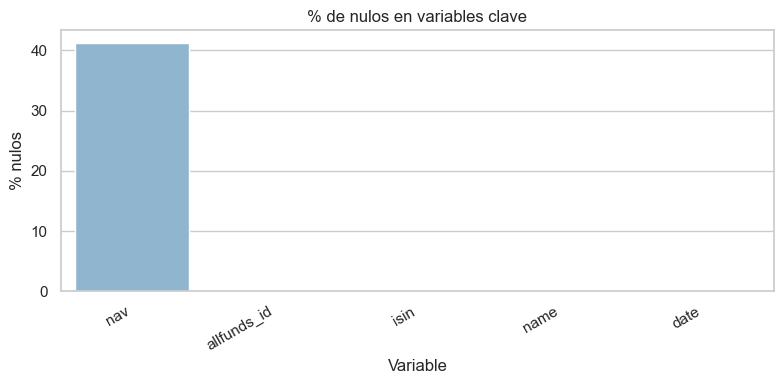

In [8]:
# Diagnóstico inicial: sin limpieza correctiva ni transformación de frecuencia.


if "daily_panel" not in globals():
    PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_universo.parquet"
    if PARQUET_PATH.exists():
        print(f"Cargando daily_panel desde parquet: {PARQUET_PATH}")
        daily_panel = pd.read_parquet(PARQUET_PATH)
        print(f"  Shape: {daily_panel.shape}")
    else:
        raise FileNotFoundError(
            f"No se encontró {PARQUET_PATH}. Ejecuta primero la sección 2.3."
        )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

# Referencia directa para evitar copiar un dataset potencialmente grande.
df = daily_panel


def detect_date_col(dataframe: pd.DataFrame):
    preferred = ["date", "nav_date", "fecha", "datetime", "timestamp"]
    cols_lower = {c.lower(): c for c in dataframe.columns}

    for candidate in preferred:
        if candidate in cols_lower:
            return cols_lower[candidate]

    dt_cols = dataframe.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    return dt_cols[0] if dt_cols else None


def safe_nunique(dataframe: pd.DataFrame, col: str):
    if col not in dataframe.columns:
        return np.nan
    return dataframe[col].nunique(dropna=True)


# 1) Shape y columnas
n_rows, n_cols = df.shape
column_list = df.columns.tolist()

# 2) Numero de fondos
n_funds_allfunds = safe_nunique(df, "allfunds_id")
n_funds_isin = safe_nunique(df, "isin")

# 3) Rango temporal global
date_col = detect_date_col(df)
if date_col is not None:
    date_series = pd.to_datetime(df[date_col], errors="coerce")
    date_min = date_series.min()
    date_max = date_series.max()
else:
    date_min, date_max = pd.NaT, pd.NaT

# 4) NAV nulo global
nav_null_pct = (df["nav"].isna().mean() * 100) if "nav" in df.columns else np.nan

# 5) Consistencia basica de metadatos
issues = {
    "allfunds_id_con_multiples_isin": np.nan,
    "isin_con_multiples_allfunds_id": np.nan,
    "allfunds_id_con_multiples_name": np.nan,
    "isin_con_multiples_name": np.nan,
}

if {"allfunds_id", "isin"}.issubset(df.columns):
    id_to_isin = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["isin"].nunique(dropna=True)
    isin_to_id = df.dropna(subset=["isin"]).groupby("isin")["allfunds_id"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_isin"] = int((id_to_isin > 1).sum())
    issues["isin_con_multiples_allfunds_id"] = int((isin_to_id > 1).sum())

if {"allfunds_id", "name"}.issubset(df.columns):
    id_to_name = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["name"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_name"] = int((id_to_name > 1).sum())

if {"isin", "name"}.issubset(df.columns):
    isin_to_name = df.dropna(subset=["isin"]).groupby("isin")["name"].nunique(dropna=True)
    issues["isin_con_multiples_name"] = int((isin_to_name > 1).sum())

# 6) Tabla resumen para reporte
summary_31 = pd.DataFrame(
    {
        "metrica": [
            "n_filas",
            "n_columnas",
            "n_fondos_por_allfunds_id",
            "n_fondos_por_isin",
            "fecha_min_global",
            "fecha_max_global",
            "porcentaje_nav_nulo",
            "allfunds_id_con_multiples_isin",
            "isin_con_multiples_allfunds_id",
            "allfunds_id_con_multiples_name",
            "isin_con_multiples_name",
        ],
        "valor": [
            n_rows,
            n_cols,
            n_funds_allfunds,
            n_funds_isin,
            date_min,
            date_max,
            nav_null_pct,
            issues["allfunds_id_con_multiples_isin"],
            issues["isin_con_multiples_allfunds_id"],
            issues["allfunds_id_con_multiples_name"],
            issues["isin_con_multiples_name"],
        ],
    }
)

print("=" * 88)
print("SECCION 3.1 - VISTA GENERAL DE CALIDAD (DIAGNOSTICO INICIAL)")
print("=" * 88)
print(f"Shape: {n_rows:,} filas x {n_cols:,} columnas")
print(f"N fondos por allfunds_id: {n_funds_allfunds if not pd.isna(n_funds_allfunds) else 'N/A'}")
print(f"N fondos por isin: {n_funds_isin if not pd.isna(n_funds_isin) else 'N/A'}")
print(f"Rango temporal global ({date_col if date_col else 'sin columna fecha'}): {date_min} -> {date_max}")
if pd.isna(nav_null_pct):
    print("% global de nav nulo: N/A (columna 'nav' no disponible)")
else:
    print(f"% global de nav nulo: {nav_null_pct:.2f}%")
print("-" * 88)
print("Columnas disponibles:")
print(column_list)
print("-" * 88)
print("Consistencia basica de metadatos:")
for k, v in issues.items():
    print(f"  - {k}: {v}")
print("=" * 88)

display(summary_31)

# Visual simple de nulos en columnas clave
key_cols = [c for c in ["nav", "allfunds_id", "isin", "name", date_col] if c is not None and c in df.columns]
if key_cols:
    nulls_key = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=nulls_key.index, y=nulls_key.values, hue=nulls_key.index, palette="Blues_d", legend=False)
    ax.set_title("% de nulos en variables clave")
    ax.set_xlabel("Variable")
    ax.set_ylabel("% nulos")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas clave disponibles para graficar nulos.")

Interpretación de consistencia básica de metadatos (3.1)

| Métrica | Significado | Si = 0 |
|---------|-------------|--------|
| `allfunds_id_con_multiples_isin` | Fondos que tienen más de un ISIN asociado | Cada fondo tiene un solo ISIN |
| `isin_con_multiples_allfunds_id` | ISIN que apuntan a más de un fondo | Cada ISIN corresponde a un solo fondo |
| `allfunds_id_con_multiples_name` | Fondos con más de un nombre distinto | Cada fondo tiene un solo nombre |
| `isin_con_multiples_name` | ISIN con más de un nombre | Cada ISIN tiene un solo nombre |

**Decisiones que permite:**

- `allfunds_id` e `isin` son claves válidas para joins y agrupaciones.
- No hay ambigüedad entre identificadores.
- Se puede usar cualquier identificador como clave principal para metadatos.
- En la fase 4 se puede agrupar por fondo sin riesgo de mezclar registros distintos.


### 3.2 - Cobertura temporal y completitud por fondo

En datasets financieros de panel, mirar solo métricas globales puede ocultar un riesgo clave: **heterogeneidad de historial entre fondos**. Dos fondos pueden convivir en el mismo dataset, pero uno tener una serie casi completa y otro estar severamente incompleto.

Por eso, en esta subsección diagnosticamos cobertura **a nivel fondo** (clave real para modelado), midiendo:

- `min_date` y `max_date` para delimitar ventana observada por fondo.
- observaciones con `nav` no nulo para cuantificar señal utilizable.
- días calendario entre `min_date` y `max_date` para estimar densidad temporal.
- ratio de completitud (`obs_no_nulo / dias_calendario`) para comparar fondos en escala homogénea.
- flag de mínimo historial de 1 año (>= 252 observaciones con NAV) como criterio preliminar de elegibilidad.

Por qué al menos 1 año de historial

| Razón | Explicación |
|-------|-------------|
| **Estimación de retornos** | Con muy pocas observaciones, los retornos calculados son muy ruidosos. Un año da suficiente serie para estimar volatilidad y tendencia con más estabilidad. |
| **Features y ventanas temporales** | Medias móviles, volatilidad reciente u otros indicadores suelen usar ventanas de varias semanas o meses. Con menos de 1 año no tienes margen razonable para calcular esas features. |
| **Cobertura de estacionalidad** | Un año cubre ciclos estacionales (trimestres, semestres). Fondos con menos de 1 año no permiten evaluar un comportamiento medio/largo plazo. |
| **Modelado supervisado** | Para clasificación o regresión hace falta suficiente variación en la variable objetivo. Con muy pocas observaciones hay riesgo alto de sobreajuste y resultados poco fiables. |


Este diagnóstico **no corrige ni excluye**. Su objetivo es preparar decisiones de fase 4 (limpieza) y fase 5 (feature engineering) con evidencia cuantitativa, evitando sesgos por fondos con historial insuficiente.

In [9]:
# 3.2 - Cobertura temporal y completitud por fondo (diagnostico)
# Restricciones: sin imputar, sin borrar fondos, solo diagnostico EDA.

if "daily_panel" not in globals():
    PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_universo.parquet"
    if PARQUET_PATH.exists():
        print(f"Cargando daily_panel desde parquet: {PARQUET_PATH}")
        daily_panel = pd.read_parquet(PARQUET_PATH)
        print(f"  Shape: {daily_panel.shape}")
    else:
        raise FileNotFoundError(
            f"No se encontró {PARQUET_PATH}. Ejecuta primero la sección 2.3."
        )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Clave de fondo prioritaria
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para calcular cobertura por fondo.")

# Columna temporal
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para medir completitud por fondo.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

coverage_by_fund = (
    work.groupby(fund_col, dropna=False)
        .agg(
            min_date=(date_col, "min"),
            max_date=(date_col, "max"),
            obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
        )
        .reset_index()
)

coverage_by_fund["dias_calendario"] = (
    (coverage_by_fund["max_date"] - coverage_by_fund["min_date"]).dt.days + 1
).clip(lower=1)

coverage_by_fund["ratio_completitud"] = (
    coverage_by_fund["obs_nav_no_nulo"] / coverage_by_fund["dias_calendario"]
)

coverage_by_fund["flag_historial_min_1y"] = (
    coverage_by_fund["obs_nav_no_nulo"] >= 252
).astype(int)

# Tablas solicitadas
top_50_menor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[True, True, False]
).head(50)

top_50_mayor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[False, False, False]
).head(50)

# Resumen global de regla minima 1 anio (>=252 obs NAV)
resumen_min_historial = (
    coverage_by_fund["flag_historial_min_1y"]
    .value_counts(dropna=False)
    .rename_axis("flag_historial_min_1y")
    .reset_index(name="n_fondos")
    .sort_values("flag_historial_min_1y", ascending=False)
)
resumen_min_historial["porcentaje"] = (
    resumen_min_historial["n_fondos"] / resumen_min_historial["n_fondos"].sum() * 100
)

n_fondos_total = coverage_by_fund[fund_col].nunique(dropna=True)
n_fondos_ok = int((coverage_by_fund["flag_historial_min_1y"] == 1).sum())
n_fondos_no = int((coverage_by_fund["flag_historial_min_1y"] == 0).sum())

print("=" * 92)
print("SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO")
print("=" * 92)
print(f"Clave de fondo usada: {fund_col}")
print(f"Fondos evaluados: {n_fondos_total:,}")
print(f"Fondos con historial >= 252 obs NAV: {n_fondos_ok:,}")
print(f"Fondos con historial < 252 obs NAV: {n_fondos_no:,}")
print("-" * 92)
print("Top 50 fondos con MENOR cobertura (ratio_completitud)")
display(top_50_menor_cobertura)
print("Top 50 fondos con MAYOR cobertura (ratio_completitud)")
display(top_50_mayor_cobertura)
print("Resumen global de minimo historial (1 = cumple, 0 = no cumple)")
display(resumen_min_historial)

# Objeto util para pipeline en siguientes fases
coverage_32 = coverage_by_fund.copy()

SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO
Clave de fondo usada: allfunds_id
Fondos evaluados: 24,819
Fondos con historial >= 252 obs NAV: 24,228
Fondos con historial < 252 obs NAV: 591
--------------------------------------------------------------------------------------------
Top 50 fondos con MENOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
261,1636,2016-01-05,2021-07-16,1,2020,0.000495,0
263,1642,2016-01-05,2021-07-16,1,2020,0.000495,0
265,1645,2016-01-05,2021-07-16,1,2020,0.000495,0
625,4813,2016-01-05,2021-07-16,1,2020,0.000495,0
671,4910,2016-01-05,2021-07-16,1,2020,0.000495,0
678,4924,2016-01-05,2021-07-16,1,2020,0.000495,0
682,4928,2016-01-05,2021-07-16,1,2020,0.000495,0
686,4932,2016-01-05,2021-07-16,1,2020,0.000495,0
797,6083,2016-01-05,2021-07-16,1,2020,0.000495,0
1116,7795,2016-01-05,2021-07-16,1,2020,0.000495,0


Top 50 fondos con MAYOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
16024,187743,2016-01-05,2021-07-16,2016,2020,0.998020,1
17760,215070,2016-01-05,2021-07-16,2016,2020,0.998020,1
8020,70019,2016-01-05,2021-07-16,2015,2020,0.997525,1
15557,175855,2016-01-05,2021-07-16,2015,2020,0.997525,1
18065,220250,2016-01-05,2021-07-16,2015,2020,0.997525,1
21968,273625,2016-01-05,2021-07-16,2015,2020,0.997525,1
24612,567026,2016-01-05,2021-07-16,2015,2020,0.997525,1
24613,567070,2016-01-05,2021-07-16,2015,2020,0.997525,1
24616,590030,2016-01-05,2021-07-16,2015,2020,0.997525,1
8670,76297,2016-01-05,2021-07-16,2014,2020,0.997030,1


Resumen global de minimo historial (1 = cumple, 0 = no cumple)


,flag_historial_min_1y,n_fondos,porcentaje
0,1,24228,97.61876
1,0,591,2.38124


Distribucion de fondos con historial < 252

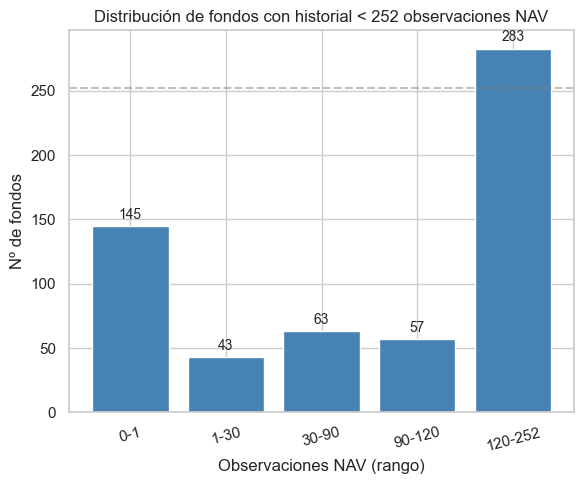

Resumen por rango de observaciones:
bucket
0-1        145
1-30        43
30-90       63
90-120      57
120-252    283

Total fondos < 252 obs: 591


In [10]:
# Fondos con historial < 252
fondos_lt_252 = coverage_by_fund[coverage_by_fund["obs_nav_no_nulo"] < 252].copy()

# Límites de los intervalos (en obs NAV)
limites = [0, 1, 30, 90, 120, 252]
etiquetas = ["0-1", "1-30", "30-90", "90-120", "120-252"]

fondos_lt_252["bucket"] = pd.cut(
    fondos_lt_252["obs_nav_no_nulo"],
    bins=limites,
    labels=etiquetas,
    include_lowest=True,
)

distribucion = fondos_lt_252["bucket"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(distribucion.index.astype(str), distribucion.values, color="steelblue", edgecolor="white")

ax.set_xlabel("Observaciones NAV (rango)")
ax.set_ylabel("Nº de fondos")
ax.set_title("Distribución de fondos con historial < 252 observaciones NAV")
ax.axhline(y=252, color="gray", linestyle="--", alpha=0.5, label="Umbral 252")
plt.xticks(rotation=15)

# Valores sobre cada barra
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{int(h)}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Resumen numérico
print("Resumen por rango de observaciones:")
print(distribucion.to_string())
print(f"\nTotal fondos < 252 obs: {fondos_lt_252.shape[0]}")

**Interpretación (3.2)**

- **Esperado sano**: la mayoría de fondos cumple el umbral mínimo de historial. Concretamente, **24.228 fondos** tienen ≥252 observaciones NAV (`flag_historial_min_1y = 1`), frente a **591 fondos** por debajo. La distribución de los 591 con historial insuficiente muestra que **145 fondos (24,5%)** tienen 0–1 observaciones, **86 (14,6%)** entre 1–30, y **283 (47,9%)** entre 120–252 (cercanos al umbral).

- **Señal de riesgo**: existe una cola de fondos con baja completitud o historial muy corto. Los **188 fondos** con menos de 30 observaciones pueden introducir ruido y sesgo en modelos supervisados. Los **145 fondos con 0–1 obs** son especialmente problemáticos (casi sin historial). El gráfico de distribución por rangos (0–1, 1–30, 30–90, 90–120, 120–252) refleja esta heterogeneidad y prioriza dónde concentrar el filtrado en fase 4.

- **Diferencia entre cobertura y longitud**: un fondo puede tener `min_date` antigua pero baja completitud (muchos huecos), por lo que antigüedad no equivale a calidad de historial. Los indicadores `ratio_completitud` y `obs_nav_no_nulo` capturan esto: un fondo con muchos días entre min y max pero pocas obs tendrá ratio bajo y `flag_historial_min_1y = 0`.

- **Implicación para fase 4**: este diagnóstico define umbrales de exclusión o reglas de tratamiento. Se recomienda excluir al menos los fondos con <30 obs NAV (188 fondos); los 283 entre 120–252 pueden evaluarse según el modelo (ya que podrian tener frecuencia semanal). El sistema de alertas de 3.5 usa estos umbrales para priorizar el trabajo de limpieza.

### 3.3 - Frecuencia observada de actualización NAV por fondo

En un panel diario de fondos, la presencia de `NaN` en `nav` no siempre implica mala calidad de dato. Muchas veces refleja la **frecuencia natural de publicación** del fondo (por ejemplo, semanal o mensual).  

Por eso, antes de limpiar o imputar, conviene inferir la frecuencia observada a partir de fechas válidas por fondo.

Este diagnóstico permite separar dos fenómenos distintos:

- **NaN estructural**: esperado por diseño de publicación (fondos no diarios).
- **NaN potencialmente problemático**: huecos anómalos para la frecuencia esperada del fondo.

La clasificación en `daily`, `weekly`, `monthly`, `irregular` (más `insufficient_data`) no corrige nada todavía, pero aporta evidencia para justificar en fases posteriores una posible homogenización temporal (por ejemplo, frecuencia semanal) con menor riesgo de distorsión.

SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO
Heuristica usada:
- insufficient_data: < 8 observaciones validas de NAV
- daily: mediana gap <= 2 y >= 80% gaps <= 3
- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]
- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]
- irregular: resto
--------------------------------------------------------------------------------------------
Distribucion de fondos por categoria de frecuencia observada


,freq_categoria,n_fondos,porcentaje
0,daily,24438,98.464886
1,insufficient_data,162,0.652726
2,irregular,136,0.547967
3,weekly,78,0.314275
4,monthly,5,0.020146


Ejemplos de fondos por categoria (hasta 5 por categoria)


,allfunds_id,freq_categoria,n_obs_nav_validas,median_gap_dias,p90_gap_dias,min_date,max_date
0,187743,daily,2016,1.0,1.0,2016-01-05,2021-07-15
1,215070,daily,2016,1.0,1.0,2016-01-05,2021-07-15
2,70019,daily,2015,1.0,1.0,2016-01-05,2021-07-15
3,175855,daily,2015,1.0,1.0,2016-01-05,2021-07-14
4,220250,daily,2015,1.0,1.0,2016-01-05,2021-07-15
5,54669,insufficient_data,7,132.5,369.5,2018-05-31,2021-04-30
6,175693,insufficient_data,7,1.0,2.0,2017-06-27,2017-07-05
7,255398,insufficient_data,7,1.0,176.0,2020-07-24,2021-07-15
8,295598,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15
9,317726,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15


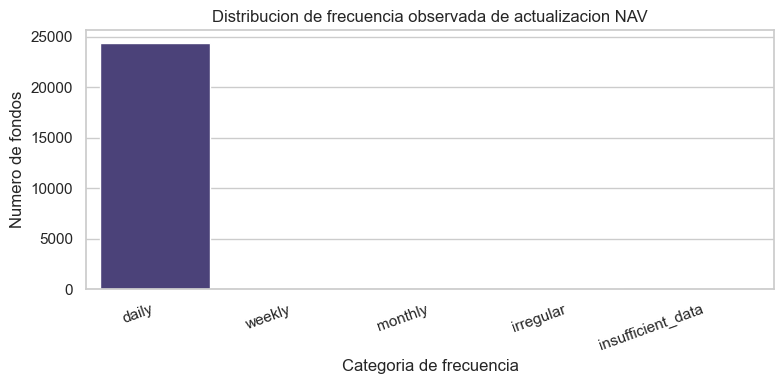

In [11]:
# 3.3 - Frecuencia observada de actualizacion NAV por fondo (solo caracterizacion)
# Restricciones: no remuestrear, no imputar, no limpiar correctivamente.

if "daily_panel" not in globals():
    PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_universo.parquet"
    if PARQUET_PATH.exists():
        print(f"Cargando daily_panel desde parquet: {PARQUET_PATH}")
        daily_panel = pd.read_parquet(PARQUET_PATH)
        print(f"  Shape: {daily_panel.shape}")
    else:
        raise FileNotFoundError(
            f"No se encontró {PARQUET_PATH}. Ejecuta primero la sección 2.3."
        )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Seleccion robusta de clave de fondo
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para analizar frecuencia por fondo.")

# Seleccion robusta de fecha
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para inferir frecuencia observada.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# Solo fechas con NAV valido
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    """
    Heuristica explicita basada en gaps entre fechas con NAV no nulo:
    - insufficient_data: menos de `min_obs_required` observaciones validas.
    - daily: mediana gap <= 2 dias y >=80% gaps <= 3 dias.
    - weekly: mediana gap entre 5 y 9 dias y >=60% gaps entre 4 y 10 dias.
    - monthly: mediana gap entre 24 y 35 dias y >=50% gaps entre 20 y 40 dias.
    - irregular: resto de casos.
    """
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


# Calculo de estadisticas de gap por fondo
rows = []
for fund_id, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    n_obs = int(len(dates))

    if n_obs <= 1:
        freq_cat = "insufficient_data"
        median_gap = np.nan
        p90_gap = np.nan
    else:
        freq_cat = classify_frequency(gaps)
        median_gap = float(gaps.median())
        p90_gap = float(gaps.quantile(0.90))

    rows.append(
        {
            fund_col: fund_id,
            "n_obs_nav_validas": n_obs,
            "min_date": dates.min() if n_obs else pd.NaT,
            "max_date": dates.max() if n_obs else pd.NaT,
            "median_gap_dias": median_gap,
            "p90_gap_dias": p90_gap,
            "freq_categoria": freq_cat,
        }
    )

freq_by_fund = pd.DataFrame(rows)

# Distribucion por categoria
dist_freq = (
    freq_by_fund["freq_categoria"]
    .value_counts(dropna=False)
    .rename_axis("freq_categoria")
    .reset_index(name="n_fondos")
)
dist_freq["porcentaje"] = dist_freq["n_fondos"] / dist_freq["n_fondos"].sum() * 100

# Ejemplos por categoria (hasta 5 fondos por categoria)
examples_by_category = (
    freq_by_fund
    .sort_values(["freq_categoria", "n_obs_nav_validas"], ascending=[True, False])
    .groupby("freq_categoria", as_index=False)
    .head(5)
    [[fund_col, "freq_categoria", "n_obs_nav_validas", "median_gap_dias", "p90_gap_dias", "min_date", "max_date"]]
    .reset_index(drop=True)
)

print("=" * 92)
print("SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO")
print("=" * 92)
print("Heuristica usada:")
print("- insufficient_data: < 8 observaciones validas de NAV")
print("- daily: mediana gap <= 2 y >= 80% gaps <= 3")
print("- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]")
print("- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]")
print("- irregular: resto")
print("-" * 92)
print("Distribucion de fondos por categoria de frecuencia observada")
display(dist_freq)
print("Ejemplos de fondos por categoria (hasta 5 por categoria)")
display(examples_by_category)

# Grafico simple
plot_order = ["daily", "weekly", "monthly", "irregular", "insufficient_data"]
plot_df = dist_freq.copy()
plot_df["freq_categoria"] = pd.Categorical(plot_df["freq_categoria"], categories=plot_order, ordered=True)
plot_df = plot_df.sort_values("freq_categoria")

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=plot_df, x="freq_categoria", y="n_fondos", hue="freq_categoria", palette="viridis", legend=False)
ax.set_title("Distribucion de frecuencia observada de actualizacion NAV")
ax.set_xlabel("Categoria de frecuencia")
ax.set_ylabel("Numero de fondos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Objeto util para pipeline posterior
freq_33 = freq_by_fund.copy()

**Interpretación de resultados (3.3)**

- **Dominancia de fondos daily (~98.5%)**: Casi todos los fondos se clasifican como actualización diaria; los NaN no se deben en su mayoría a fondos semanales o mensuales. La alta proporción de nulos global (sección 3.4) responde más a inicio/fin de series, festivos o huecos puntuales que a diseño de publicación.
- **weekly (78) y monthly (5)**: Muy minoritarios; la homogenización a frecuencia semanal tendría impacto limitado en el conjunto del universo.
- **insufficient_data (162)**: Fondos con pocas observaciones válidas; conviene excluirlos o tratarlos aparte en modelado para evitar inferencia poco fiable.
- **irregular (136)**: Patrones de actualización no claramente daily/weekly/monthly; candidatos a revisión manual o reglas específicas en la fase de limpieza.
- **Conclusión**: El panel es principalmente diario por diseño observado; el análisis a frecuencia diaria es razonable. Una homogenización a semanal sería opcional para reducir ruido, no necesaria por tener muchos fondos no diarios.

### 3.4 - Calidad de NAV y anomalías preliminares

Antes de limpiar o modelar, conviene auditar la calidad de `nav` porque esta variable es la base de retornos, features y etiquetas posteriores. Si `nav` contiene huecos, valores no plausibles (`<= 0`) o saltos extremos, el riesgo es propagar ruido a toda la cadena analítica.

En esta subsección diferenciamos **diagnóstico** de **corrección**:

- Medimos nulos globales y por fondo,
- Identificamos casos `nav <= 0`,
- Evaluamos la distribución de NAV,
- Analizamos retornos diarios (agregados) y marcamos extremos con percentiles e IQR globales, sin limpieza correctiva,
- Marcamos extremos con criterios explícitos (percentiles 1%-99% e IQR).

Esto permite anticipar si los problemas son puntuales o sistémicos y preparar reglas de fase 4 con evidencia, evitando decisiones ad hoc.

SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES
Filas evaluadas: 50,134,380
% NAV nulo global: 41.25%
NAV <= 0 global: 0 (0.00%)
Retornos validos analizados: 22,953,912
Umbral extremos percentiles (1%-99%): [-0.025459, 0.023269]
Umbral extremos IQR: [-0.008837, 0.009730]
----------------------------------------------------------------------------------------------
Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)


,allfunds_id,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_ret_valid
16024,187743,2013.0,0.000054,0.000992,-0.013127,-0.002458,-0.001045,-0.000126,0.000052,0.000312,0.001147,0.002634,0.006262,2013
17760,215070,2013.0,0.000064,0.001174,-0.014894,-0.002990,-0.001102,-0.000117,0.000051,0.000331,0.001214,0.003217,0.009855,2013
15557,175855,2012.0,0.000009,0.000976,-0.008762,-0.003062,-0.001253,-0.000187,0.000040,0.000187,0.001245,0.002727,0.012690,2012
24613,567070,2012.0,-0.000005,0.000603,-0.012830,-0.001442,-0.000546,-0.000096,0.000027,0.000095,0.000536,0.001229,0.004802,2012
24612,567026,2012.0,0.000340,0.009828,-0.113623,-0.030241,-0.013229,-0.001577,-0.000054,0.003473,0.013085,0.024370,0.096893,2012
24616,590030,2012.0,0.000148,0.007954,-0.104513,-0.022400,-0.011827,-0.001746,-0.000059,0.003020,0.011395,0.020664,0.040840,2012
9349,82293,2011.0,-0.000020,0.000053,-0.000640,-0.000196,-0.000111,-0.000031,-0.000021,0.000007,0.000047,0.000085,0.000673,2011
8671,76298,2011.0,0.000062,0.002639,-0.034681,-0.007851,-0.002955,-0.000367,0.000013,0.000722,0.003078,0.007204,0.022076,2011
24536,542016,2011.0,0.000090,0.008697,-0.113660,-0.025235,-0.012617,-0.001848,-0.000024,0.002969,0.012294,0.023328,0.076924,2011
18065,220250,2011.0,0.000073,0.001708,-0.025936,-0.004505,-0.001657,-0.000107,0.000072,0.000407,0.001729,0.004326,0.015047,2011


Top 50 fondos por incidencia de anomalias (score combinado diagnostico)


,allfunds_id,n_rows,n_nav_null,n_nav_nonpos,pct_nav_null,pct_nav_nonpos,n_ret_valid,n_extremos_pct,n_extremos_iqr,pct_extremos_pct,pct_extremos_iqr,anom_score
8920,79184,2020,1973,0,0.976733,0.0,36,10,24,0.277778,0.666667,0.608523
23619,291534,2020,1920,0,0.950495,0.0,77,17,47,0.220779,0.610390,0.576829
22244,276575,2020,1842,0,0.911881,0.0,132,22,81,0.166667,0.613636,0.564613
22249,276671,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22250,276689,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22247,276641,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22248,276646,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
20023,250317,2020,1704,0,0.843564,0.0,244,59,160,0.241803,0.655738,0.557543
15054,167213,2020,1797,0,0.889604,0.0,220,88,133,0.400000,0.604545,0.553180
15412,172939,2020,2005,0,0.992574,0.0,10,1,5,0.100000,0.500000,0.547401


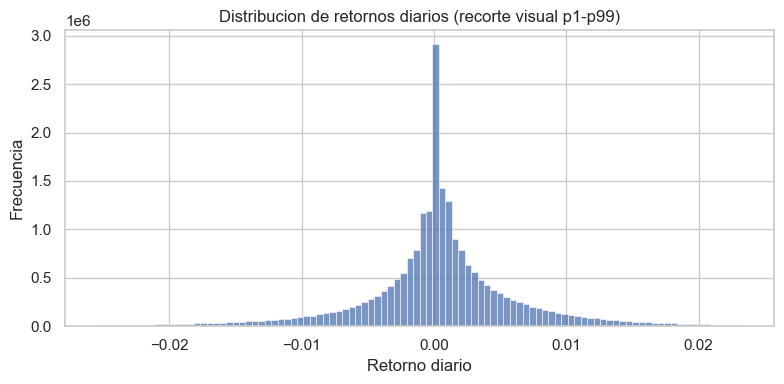

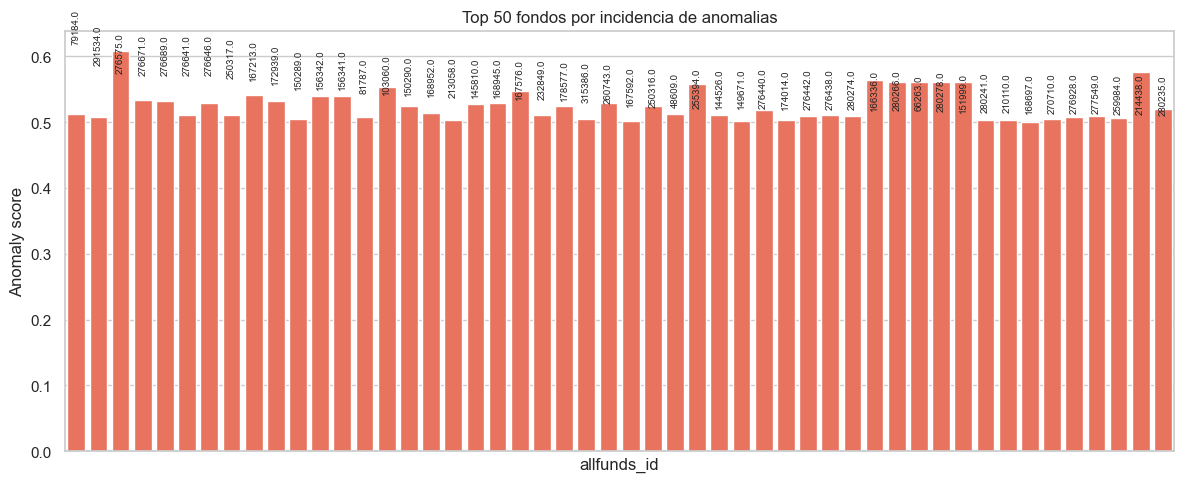

In [12]:
# 3.4 - Calidad de NAV y anomalías preliminares (EDA diagnóstico)
# Restricciones: no corregir, no imputar, no eliminar registros.
# Sin estadísticos de NAV; con estadísticos de retornos diarios por fondo.

if "daily_panel" not in globals():
    PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_universo.parquet"
    if PARQUET_PATH.exists():
        print(f"Cargando daily_panel desde parquet: {PARQUET_PATH}")
        daily_panel = pd.read_parquet(PARQUET_PATH)
        print(f"  Shape: {daily_panel.shape}")
    else:
        raise FileNotFoundError(
            f"No se encontró {PARQUET_PATH}. Ejecuta primero la sección 2.3."
        )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para el diagnostico 3.4.")

def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para analisis por fondo.")

def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]

fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# 1) Nulos NAV global y por fondo
n_total = len(work)
nav_null_global_pct = float(work["nav"].isna().mean() * 100)

nav_quality_by_fund = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_quality_by_fund["pct_nav_null"] = nav_quality_by_fund["n_nav_null"] / nav_quality_by_fund["n_rows"]
nav_quality_by_fund["pct_nav_nonpos"] = nav_quality_by_fund["n_nav_nonpos"] / nav_quality_by_fund["n_rows"]

# 2) Casos nav <= 0 global
n_nav_nonpos_global = int((work["nav"] <= 0).sum())
pct_nav_nonpos_global = float((work["nav"] <= 0).mean() * 100)

# 3) Retornos diarios por fondo (sin limpieza correctiva)
ret_df = work[[fund_col, date_col, "nav"]].copy().sort_values([fund_col, date_col])
ret_df["ret_1d"] = ret_df.groupby(fund_col)["nav"].pct_change(fill_method=None)
ret_df["ret_1d"] = ret_df["ret_1d"].replace([np.inf, -np.inf], np.nan)

ret_series = ret_df["ret_1d"].dropna()

# 4) Estadísticos de retornos diarios POR FONDO
ret_stats_by_fund = (
    ret_df.groupby(fund_col)["ret_1d"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)

# 5) Extremos diagnósticos (criterio explícito)
q_low, q_high = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_df["flag_extremo_pct"] = ret_df["ret_1d"].lt(q_low) | ret_df["ret_1d"].gt(q_high)

q1, q3 = ret_series.quantile([0.25, 0.75]) if len(ret_series) else (np.nan, np.nan)
iqr = q3 - q1 if pd.notna(q1) and pd.notna(q3) else np.nan
iqr_low = q1 - 1.5 * iqr if pd.notna(iqr) else np.nan
iqr_high = q3 + 1.5 * iqr if pd.notna(iqr) else np.nan
ret_df["flag_extremo_iqr"] = ret_df["ret_1d"].lt(iqr_low) | ret_df["ret_1d"].gt(iqr_high)

ret_anom_by_fund = (
    ret_df.groupby(fund_col)
    .agg(
        n_ret_valid=("ret_1d", lambda s: int(s.notna().sum())),
        n_extremos_pct=("flag_extremo_pct", lambda s: int(s.fillna(False).sum())),
        n_extremos_iqr=("flag_extremo_iqr", lambda s: int(s.fillna(False).sum())),
    )
    .reset_index()
)
ret_anom_by_fund["pct_extremos_pct"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_pct"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)
ret_anom_by_fund["pct_extremos_iqr"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_iqr"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)

# 6) Top 50 fondos por incidencia de anomalías
anom_by_fund = nav_quality_by_fund.merge(ret_anom_by_fund, on=fund_col, how="left")
for c in ["n_ret_valid", "n_extremos_pct", "n_extremos_iqr", "pct_extremos_pct", "pct_extremos_iqr"]:
    anom_by_fund[c] = anom_by_fund[c].fillna(0)

anom_by_fund["anom_score"] = (
    0.35 * anom_by_fund["pct_nav_null"]
    + 0.25 * anom_by_fund["pct_nav_nonpos"]
    + 0.40 * anom_by_fund["pct_extremos_iqr"]
)

top50_anomalias = anom_by_fund.sort_values("anom_score", ascending=False).head(50)

# --- Salida ---
print("=" * 94)
print("SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES")
print("=" * 94)
print(f"Filas evaluadas: {n_total:,}")
print(f"% NAV nulo global: {nav_null_global_pct:.2f}%")
print(f"NAV <= 0 global: {n_nav_nonpos_global:,} ({pct_nav_nonpos_global:.2f}%)")
print(f"Retornos validos analizados: {len(ret_series):,}")
print(f"Umbral extremos percentiles (1%-99%): [{q_low:.6f}, {q_high:.6f}]")
print(f"Umbral extremos IQR: [{iqr_low:.6f}, {iqr_high:.6f}]")
print("-" * 94)
print("Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)")
# Ordenar por count y mostrar muestra
ret_stats_orden = ret_stats_by_fund.merge(
    ret_anom_by_fund[[fund_col, "n_ret_valid"]], on=fund_col
).sort_values("n_ret_valid", ascending=False)
display(ret_stats_orden.head(20))
print("Top 50 fondos por incidencia de anomalias (score combinado diagnostico)")
display(top50_anomalias)

# Gráficos (sin histograma de NAV)
r_lo, r_hi = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_plot = ret_series[(ret_series >= r_lo) & (ret_series <= r_hi)] if pd.notna(r_lo) else ret_series

plt.figure(figsize=(8, 4))
_ = sns.histplot(ret_plot, bins=100, kde=False)
plt.title("Distribucion de retornos diarios (recorte visual p1-p99)")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top50_anomalias, x=fund_col, y="anom_score", color="tomato")
plt.title("Top 50 fondos por incidencia de anomalias")
plt.xlabel(fund_col)
plt.ylabel("Anomaly score")

# Fund ID sobre cada barra
for i, (_, row) in enumerate(top50_anomalias.iterrows()):
    ax.text(i, row["anom_score"] + 0.01, str(row[fund_col]), 
            ha="center", va="bottom", rotation=90, fontsize=7)

plt.xticks([], [])
plt.tight_layout()
plt.show()

nav_quality_34 = nav_quality_by_fund.copy()
ret_quality_34 = ret_anom_by_fund.copy()
anom_34 = anom_by_fund.copy()
ret_stats_by_fund_34 = ret_stats_by_fund.copy()



**Interpretación de resultados (3.4)**

- **NAV nulo (41.25%)**: Proporción esperable en un panel diario con fondos de liquidación semanal/mensual; no implica error por sí mismo.
- **NAV ≤ 0 (0%)**: No hay NAV negativos ni cero; sin indicios de corrupción básica en el dato.
- **Retornos extremos**: Los umbrales 1%-99% e IQR marcan rangos razonables. Fondos con std muy alto (p. ej. 24612, 24616, 21968: std ~0.008–0.01) muestran mayor volatilidad o posibles discontinuidades; merecen revisión. (Podria ser fondos de frecuencia semanal o mensual, que al dar el dato no es comparable con los retornos diarios, creando asi un falso retorno extremo)
- **Top 50 anomalías**: Se combinan alto % de NAV nulo (80–99%) con alta proporción de retornos extremos (pct_extremos_pct y pct_extremos_iqr elevados). Son candidatos naturales a reglas de calidad más estrictas en la fase de preprocesado.
- **Fondos con patrón similar** (22xxx, 27xxx): Grupos de fondos con métricas muy parecidas, posiblemente misma gestora o familia; puede priorizarse un tratamiento conjunto.
- **Enfoque**: Este diagnóstico prioriza qué fondos tratar en fases posteriores; no implica borrar ni corregir datos todavía.

### 3.5 - Sistema de alertas EDA y resumen ejecutivo

El cierre de EDA traduce hallazgos técnicos en **señales accionables** para la fase 4. Este bloque consolida evidencias de secciones previas en una vista única por fondo. El objetivo no es excluir automáticamente, sino responder con datos a preguntas de gobierno del dato:

- ¿Qué fondos concentran más problemas estructurales?
- ¿Qué tipo de riesgo domina (cobertura, NAV, frecuencia)?
- ¿Qué reglas de fase 4 tienen mayor impacto potencial?

---

**Interpretación punto por punto**

**1) 3.1 - Vista general de calidad**  
Diagnóstico inicial: validación de estructura, cobertura e integridad del panel diario sin correcciones. Base para entender el alcance del universo y la naturaleza de los datos.

**2) 3.2 - Cobertura temporal y completitud**  
- 24,228 fondos (97.6%) cumplen historial mínimo ≥252 obs; 591 (2.4%) no.  
- Cola de fondos con baja `ratio_completitud`: antigüedad no implica calidad (muchos huecos).  
- Implicación: definir umbrales de exclusión o tratamiento de faltantes por fondo.

**3) 3.3 - Frecuencia observada**  
- ~98.5% clasificados como *daily*; weekly (78) y monthly (5) son minoritarios.  
- Los NaN no se explican mayormente por fondos no diarios; más bien por inicio/fin de series, festivos o huecos puntuales.  
- *insufficient_data* (162) e *irregular* (136): candidatos a reglas específicas o exclusión.

**4) 3.4 - Calidad de NAV y anomalías**  
- 41.25% NAV nulo global; 0% NAV ≤0 (sin corrupción aparente).  
- Top 50 anomalías: alto % de null (80–99%) y alta incidencia de retornos extremos.  
- Fondos con std muy alto (p. ej. 24612, 24616): revisar posibles discontinuidades o volatilidad real.  
- Clusters de fondos similares (22xxx, 27xxx): posible misma gestora/familia.

**5) 3.5 - Sistema de alertas (síntesis)**  
Con umbrales `cobertura_baja<0.60`, `historial<252`, `nav_null_alto>0.50`:  
- **Riesgo dominante**: cobertura_baja (7,399 fondos, 29.8%).  
- **Segundo riesgo**: nav_null_alto (5,835 fondos, 23.5%).  
- historial_lt_1y: 591 (2.4%); freq_irregular: 136 (0.55%).

**Acciones priorizadas para fase 4**  
1. Definir umbral operativo de cobertura mínima por fondo.  
2. Regla para fondos con <252 observaciones válidas.  
3. Tratamiento diferenciado para fondos con alto % de null y/o alta incidencia de extremos.

En términos prácticos, este sistema actúa como **puente directo a fase 4**: prioriza, documenta y justifica decisiones antes de corregir.

In [13]:

if "daily_panel" not in globals():
    PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_universo.parquet"
    if PARQUET_PATH.exists():
        print(f"Cargando daily_panel desde parquet: {PARQUET_PATH}")
        daily_panel = pd.read_parquet(PARQUET_PATH)
        print(f"  Shape: {daily_panel.shape}")
    else:
        raise FileNotFoundError(
            f"No se encontró {PARQUET_PATH}. Ejecuta primero la sección 2.3."
        )

panel = daily_panel

# --- utilidades de esquema ---
def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para construir alertas por fondo.")


def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]


fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# --- (A) Cobertura / historial (3.2) ---
coverage_tbl = (
    work.groupby(fund_col)
    .agg(
        min_date=(date_col, "min"),
        max_date=(date_col, "max"),
        obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
coverage_tbl["dias_calendario"] = ((coverage_tbl["max_date"] - coverage_tbl["min_date"]).dt.days + 1).clip(lower=1)
coverage_tbl["ratio_completitud"] = coverage_tbl["obs_nav_no_nulo"] / coverage_tbl["dias_calendario"]

# --- (B) Calidad NAV (3.4) ---
nav_tbl = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_tbl["pct_nav_null"] = nav_tbl["n_nav_null"] / nav_tbl["n_rows"]
nav_tbl["has_nav_nonpos"] = (nav_tbl["n_nav_nonpos"] > 0).astype(int)

# --- (C) Frecuencia (3.3) ---
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def _classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


freq_rows = []
for fid, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    freq_rows.append({fund_col: fid, "freq_categoria": _classify_frequency(gaps) if len(dates) > 1 else "insufficient_data"})

freq_tbl = pd.DataFrame(freq_rows)

# --- (D) Consolidado y flags ---
alerts = coverage_tbl.merge(nav_tbl[[fund_col, "pct_nav_null", "has_nav_nonpos"]], on=fund_col, how="left")
alerts = alerts.merge(freq_tbl, on=fund_col, how="left")
alerts["freq_categoria"] = alerts["freq_categoria"].fillna("insufficient_data")

# Umbrales preliminares EDA (ajustables en fase 4)
TH_COBERTURA_BAJA = 0.60
TH_OBS_MIN_1Y = 252
TH_NAV_NULL_ALTO = 0.50

alerts["flag_cobertura_baja"] = (alerts["ratio_completitud"] < TH_COBERTURA_BAJA).astype(int)
alerts["flag_historial_lt_1y"] = (alerts["obs_nav_no_nulo"] < TH_OBS_MIN_1Y).astype(int)
alerts["flag_nav_null_alto"] = (alerts["pct_nav_null"] > TH_NAV_NULL_ALTO).astype(int)
alerts["flag_nav_nonpos"] = alerts["has_nav_nonpos"].astype(int)
alerts["flag_freq_irregular"] = (alerts["freq_categoria"] == "irregular").astype(int)

flag_cols = [
    "flag_cobertura_baja",
    "flag_historial_lt_1y",
    "flag_nav_null_alto",
    "flag_nav_nonpos",
    "flag_freq_irregular",
]

alerts["alert_score"] = alerts[flag_cols].sum(axis=1)

# Ranking de fondos mas problematicos
ranking_top50 = (
    alerts.sort_values(
        ["alert_score", "flag_nav_nonpos", "flag_nav_null_alto", "flag_cobertura_baja", "ratio_completitud"],
        ascending=[False, False, False, False, True],
    )
    .head(50)
)

# Resumen de alertas
resumen_alertas = pd.DataFrame(
    {
        "alerta": [
            "cobertura_baja",
            "historial_lt_1y",
            "nav_null_alto",
            "nav_nonpos",
            "freq_irregular",
        ],
        "n_fondos": [
            int(alerts["flag_cobertura_baja"].sum()),
            int(alerts["flag_historial_lt_1y"].sum()),
            int(alerts["flag_nav_null_alto"].sum()),
            int(alerts["flag_nav_nonpos"].sum()),
            int(alerts["flag_freq_irregular"].sum()),
        ],
    }
)
resumen_alertas["porcentaje_fondos"] = 100 * resumen_alertas["n_fondos"] / len(alerts)

# --- salida principal ---
print("=" * 96)
print("SECCION 3.5 - SISTEMA DE ALERTAS EDA Y RESUMEN EJECUTIVO")
print("=" * 96)
print(f"Fondos evaluados: {len(alerts):,}")
print(f"Umbrales: cobertura_baja<{TH_COBERTURA_BAJA:.2f}, historial<{TH_OBS_MIN_1Y}, nav_null_alto>{TH_NAV_NULL_ALTO:.2f}")
print("-" * 96)
print("Tabla consolidada de flags por fondo")
display(alerts[[fund_col, "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols + ["alert_score"]])
print("Top 50 fondos mas problematicos")
display(ranking_top50[[fund_col, "alert_score", "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols])
print("Resumen de fondos por tipo de alerta")
display(resumen_alertas.sort_values("n_fondos", ascending=False))

# --- conclusion automatica ---
dom = resumen_alertas.sort_values("n_fondos", ascending=False).reset_index(drop=True)
main_risk = dom.loc[0, "alerta"] if len(dom) else "sin_alertas"
second_risk = dom.loc[1, "alerta"] if len(dom) > 1 else "n/a"

print("\nCONCLUSION AUTOMATICA (PUENTE A FASE 4)")
print(f"- Riesgo dominante: {main_risk}")
print(f"- Segundo riesgo: {second_risk}")
print("- Decisiones recomendadas para fase 4:")
print("  1) Definir umbral operativo de cobertura minima por fondo.")
print("  2) Establecer regla para fondos con <252 observaciones validas.")
print("  3) Tratar explicitamente NAV <= 0 (invalidos o casos especiales).")
print("  4) Ajustar estrategia por frecuencia irregular antes de features/modelado.")
print("  5) Validar si los umbrales preliminares deben endurecerse o relajarse.")

# Objetos puente para fase 4
alerts_35 = alerts.copy()
alerts_summary_35 = resumen_alertas.copy()

SECCION 3.5 - SISTEMA DE ALERTAS EDA Y RESUMEN EJECUTIVO
Fondos evaluados: 24,819
Umbrales: cobertura_baja<0.60, historial<252, nav_null_alto>0.50
------------------------------------------------------------------------------------------------
Tabla consolidada de flags por fondo


,allfunds_id,ratio_completitud,obs_nav_no_nulo,pct_nav_null,has_nav_nonpos,freq_categoria,flag_cobertura_baja,flag_historial_lt_1y,flag_nav_null_alto,flag_nav_nonpos,flag_freq_irregular,alert_score
0,8,0.686634,1387,0.313366,0,daily,0,0,0,0,0,0
1,9,0.686634,1387,0.313366,0,daily,0,0,0,0,0,0
2,12,0.686139,1386,0.313861,0,daily,0,0,0,0,0,0
3,19,0.705446,1425,0.294554,0,daily,0,0,0,0,0,0
4,20,0.705446,1425,0.294554,0,daily,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
24814,900065,0.672277,1358,0.327723,0,daily,0,0,0,0,0,0
24815,900109,0.164356,332,0.835644,0,daily,1,0,1,0,0,2
24816,901209,0.698020,1410,0.301980,0,daily,0,0,0,0,0,0
24817,901433,0.164851,333,0.835149,0,daily,1,0,1,0,0,2


Top 50 fondos mas problematicos


,allfunds_id,alert_score,ratio_completitud,obs_nav_no_nulo,pct_nav_null,has_nav_nonpos,freq_categoria,flag_cobertura_baja,flag_historial_lt_1y,flag_nav_null_alto,flag_nav_nonpos,flag_freq_irregular
5001,41538,4,0.011881,24,0.988119,0,irregular,1,1,1,0,1
19096,240116,4,0.024257,49,0.975743,0,irregular,1,1,1,0,1
16412,192033,4,0.037624,76,0.962376,0,irregular,1,1,1,0,1
4256,32847,4,0.047525,96,0.952475,0,irregular,1,1,1,0,1
4258,32849,4,0.051485,104,0.948515,0,irregular,1,1,1,0,1
4257,32848,4,0.051980,105,0.948020,0,irregular,1,1,1,0,1
3456,25755,4,0.053960,109,0.946040,0,irregular,1,1,1,0,1
20890,261870,4,0.058911,119,0.941089,0,irregular,1,1,1,0,1
3574,26723,4,0.064851,131,0.935149,0,irregular,1,1,1,0,1
3576,26731,4,0.064851,131,0.935149,0,irregular,1,1,1,0,1


Resumen de fondos por tipo de alerta


,alerta,n_fondos,porcentaje_fondos
0,cobertura_baja,7399,29.811838
2,nav_null_alto,5835,23.510214
1,historial_lt_1y,591,2.381240
4,freq_irregular,136,0.547967
3,nav_nonpos,0,0.000000



CONCLUSION AUTOMATICA (PUENTE A FASE 4)
- Riesgo dominante: cobertura_baja
- Segundo riesgo: nav_null_alto
- Decisiones recomendadas para fase 4:
  1) Definir umbral operativo de cobertura minima por fondo.
  2) Establecer regla para fondos con <252 observaciones validas.
  3) Tratar explicitamente NAV <= 0 (invalidos o casos especiales).
  4) Ajustar estrategia por frecuencia irregular antes de features/modelado.
  5) Validar si los umbrales preliminares deben endurecerse o relajarse.


## 4. Limpieza de datos (reglas explícitas)

- Eliminar fondos con demasiados faltantes (definir umbral, por ejemplo 30%).
- Aplicar imputación simple si procede (`ffill`) y justificar.
- Eliminar o tratar valores no positivos antes de calcular log-retornos.
- Tratar outliers extremos solo si están distorsionando resultados.

### 4.1 – Exclusión de fondos

Se aplica **antes** de modificar filas. Usar `alerts_35` de la sección 3.5 para identificar fondos.

| Paso | Regla | Fondos afectados (aprox.) | Justificación |
|------|-------|---------------------------|---------------|
| 1 | Excluir `obs_nav_no_nulo < 30` | 188 | Historial demasiado corto para inferencia (3.2) |
| 2 | Excluir `freq_categoria == "insufficient_data"` | 162 | Menos de 8 obs válidas; no permite caracterizar el fondo (3.3) |
| 3 | Excluir `obs_nav_no_nulo < 252` | 591 | Mínimo 1 año para series temporales (3.2) |


---
 Argumentación por regla
**Regla 1 – `obs_nav_no_nulo < 30`**
- **Evidencia (3.2):** 591 fondos con historial &lt; 252 obs; de estos, **188 tienen menos de 30 observaciones** y **145 tienen 0–1 obs**. La interpretación de 3.2 indica que estos fondos pueden introducir ruido y sesgo en modelos supervisados y que los 145 con 0–1 obs son casi sin historial.
- **Motivo:** Con menos de 30 obs no se puede estimar volatilidad ni tendencia mínima. Sin ese mínimo, cualquier estadístico (media, std, retornos) es poco fiable.
- **Conclusión:** Excluir fondos con &lt; 30 obs NAV.
---
**Regla 2 – `freq_categoria == "insufficient_data"`**
- **Evidencia (3.3):** 162 fondos clasificados como `insufficient_data` porque tienen **menos de 8 observaciones válidas de NAV**. La heurística de 3.3 requiere al menos 8 obs para clasificar frecuencia.
- **Motivo:** Con tan pocas fechas válidas no se puede inferir si el fondo es daily, weekly o irregular. Son series sin patrón temporal utilizable.
- **Conclusión:** Excluir fondos con `insufficient_data` para evitar inferencia poco fiable.
---
**Regla 3 – `obs_nav_no_nulo < 252`**
- **Evidencia (3.2):** 24.228 fondos (97,6%) cumplen historial ≥ 252 obs; 591 (2,4%) no. El flag `flag_historial_min_1y` se define con 252 obs (~1 año laborable).
- **Motivo:** 252 días ≈ 1 año de sesiones; umbral habitual para series temporales financieras. Los 283 fondos entre 120–252 podrían ser semanales y evaluables, pero para consistencia se recomienda 252.
- **Conclusión sobre fondos no diarios:** Con esta regla quedarán fuera fondos semanales y mensuales, pero al ser un porcentaje muy bajo del dataset (~83 fondos frente a ~24.800) se opta por excluirlos. Mantenerlos exigiría rellenar muchos días sin NAV (ffill u otros métodos), lo que podría: (a) distorsionar la estadística de retornos (retornos artificialmente cercanos a cero en periodos imputados) y (b) introducir look-ahead si la imputación usa información posterior.
- **Conclusión:** Excluir fondos con < 252 obs NAV para garantizar historial mínimo sin depender de imputaciones que alteren la señal o introduzcan sesgos temporales.
---
**Sobre solapamiento:** Las reglas 1 y 2 son excluyentes respecto a 3: muchos fondos con &lt; 30 obs o `insufficient_data` ya cumplirían &lt; 252 obs. El orden 1 → 2 → 3 evita duplicar exclusiones y mantiene trazabilidad.


In [14]:
# =============================================================================
# 4.1 – Exclusión de fondos 
# =============================================================================
# Reglas: 1) obs_nav_no_nulo >= 30
#         2) freq_categoria != "insufficient_data"
#         3) obs_nav_no_nulo >= 252
# Requiere: daily_panel, alerts_35 (sección 3.5)
# =============================================================================

if "daily_panel" not in globals():
    raise NameError("Ejecuta antes la construcción/carga del panel diario.")
if "alerts_35" not in globals():
    raise NameError("Ejecuta antes la sección 3.5 para tener `alerts_35`.")

fund_col = "allfunds_id" if "allfunds_id" in alerts_35.columns else "isin"

# --- Máscaras por regla ---
mask_r1 = alerts_35["obs_nav_no_nulo"] >= 30
mask_r2 = alerts_35["freq_categoria"] != "insufficient_data"
mask_r3 = alerts_35["obs_nav_no_nulo"] >= 252

# Fondos que pasan todas las reglas
funds_ok = alerts_35.loc[mask_r1 & mask_r2 & mask_r3, fund_col].unique()

# Excluidos por cada regla (para trazabilidad)
excl_r1 = alerts_35.loc[~mask_r1, fund_col].tolist()
excl_r2 = alerts_35.loc[~mask_r2, fund_col].tolist()
excl_r3 = alerts_35.loc[~mask_r3, fund_col].tolist()

# Fondos que fallan alguna regla (unión)
funds_excluidos = set(excl_r1) | set(excl_r2) | set(excl_r3)

# --- Aplicar filtro al panel ---
daily_panel_clean = daily_panel[daily_panel[fund_col].isin(funds_ok)].copy()

# --- Resumen ---
n_fondos_antes = daily_panel[fund_col].nunique()
n_filas_antes = len(daily_panel)
n_fondos_despues = len(funds_ok)
n_filas_despues = len(daily_panel_clean)

print("=" * 60)
print("4.1 – EXCLUSIÓN DE FONDOS")
print("=" * 60)
print(f"Fondos antes:     {n_fondos_antes:,}")
print(f"Fondos después:   {n_fondos_despues:,}")
print(f"Fondos excluidos: {len(funds_excluidos):,}")
print("-" * 60)
print("Excluidos por regla:")
print(f"  R1 (obs_nav_no_nulo < 30):           {len(excl_r1):,}")
print(f"  R2 (freq_categoria == insufficient): {len(excl_r2):,}")
print(f"  R3 (obs_nav_no_nulo < 252):          {len(excl_r3):,}")
print("-" * 60)
print(f"Filas antes:     {n_filas_antes:,}")
print(f"Filas después:   {n_filas_despues:,}")
print("=" * 60)


resumen_41 = pd.DataFrame({
    "metrica": ["n_fondos", "n_filas"],
    "antes": [n_fondos_antes, n_filas_antes],
    "despues": [n_fondos_despues, n_filas_despues],
})
display(resumen_41)

# --- Guardar resultado filtrado en /data como parquet ---

OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "daily_panel_filtrado.parquet"
daily_panel_clean.to_parquet(OUT_PARQUET, index=False)

print("\nArchivo guardado:")
print(f" -> {OUT_PARQUET}")

4.1 – EXCLUSIÓN DE FONDOS
Fondos antes:     24,819
Fondos después:   24,228
Fondos excluidos: 591
------------------------------------------------------------
Excluidos por regla:
  R1 (obs_nav_no_nulo < 30):           186
  R2 (freq_categoria == insufficient): 162
  R3 (obs_nav_no_nulo < 252):          591
------------------------------------------------------------
Filas antes:     50,134,380
Filas después:   48,940,560


,metrica,antes,despues
0,n_fondos,24819,24228
1,n_filas,50134380,48940560



Archivo guardado:
 -> data\daily_universe\daily_panel_filtrado.parquet


### 4.2 – Filtrado a días laborables (Lunes–Viernes)

Este paso reduce el panel a días de entre semana (L–V) antes de cualquier imputación (`ffill`).

- **Objetivos**
  - Disminuir el número de filas y el consumo de memoria para evitar errores en pasos posteriores.
  - Evitar aplanar la serie al aplicar `ffill` sobre fines de semana.
  - Preservar mejor la volatilidad útil para las regresiones y el análisis.

- **Criterio de filtrado**
  - Mantener únicamente observaciones con `weekday` en {0, 1, 2, 3, 4} (Lunes=0 … Viernes=4).

- **Uso aguas abajo**
  - A partir de aquí, los pasos siguientes (p. ej., el `ffill` de la sección 4.3) deben operar sobre `daily_panel_clean` si está definido:
    - `panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel`

- **Notas**
  - Convierte siempre `date` a tipo fecha antes de filtrar.
  - Ordena por fecha tras el filtrado para estabilidad en procesos posteriores.

In [15]:
# =============================================================================
# 4.2 – Filtrado a días laborables (Lunes–Viernes)
# =============================================================================


# Intentar cargar desde parquet guardado en 4.1 dentro de /data/daily_universe
IN_DIR = Path("data") / "daily_universe"
IN_DIR.mkdir(parents=True, exist_ok=True)
IN_PARQUET = IN_DIR / "daily_panel_filtrado.parquet"
if IN_PARQUET.exists():
    panel_in = pd.read_parquet(IN_PARQUET)
else:
    # Tomar el panel diario bruto si existe una versión limpia previa, úsala como entrada
    panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel

date_col = "date"
if date_col not in panel_in.columns:
    raise KeyError(f"No se encuentra la columna '{date_col}' en el panel de entrada.")

# Garantizar tipo datetime
panel_in = panel_in.copy()
panel_in[date_col] = pd.to_datetime(panel_in[date_col], errors="coerce")

# Filtrar a días laborables (0=Mon, ..., 4=Fri)
before_rows = len(panel_in)
daily_panel_clean = panel_in[panel_in[date_col].dt.weekday < 5].copy()
after_rows = len(daily_panel_clean)

# (Opcional) Orden temporal para estabilidad aguas abajo
daily_panel_clean = daily_panel_clean.sort_values([date_col]).reset_index(drop=True)

print("=" * 70)
print("4.2 – FILTRADO A DÍAS LABORABLES (L–V)")
print("=" * 70)
print(f"Filas antes del filtro:  {before_rows:,}")
print(f"Filas después (L–V):    {after_rows:,}")
print(f"Reducción de filas:     {before_rows - after_rows:,} ({100 * (before_rows - after_rows) / max(before_rows,1):.2f}%)")
print("=" * 70)

# Guardar resultado en /data como parquet con nombre 'daily_panel_semana_filtrado.parquet'
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "daily_panel_semana_filtrado.parquet"
daily_panel_clean.to_parquet(OUT_PARQUET, index=False)

print("\nArchivo guardado:")
print(f" -> {OUT_PARQUET}")

4.2 – FILTRADO A DÍAS LABORABLES (L–V)
Filas antes del filtro:  48,940,560
Filas después (L–V):    34,985,232
Reducción de filas:     13,955,328 (28.51%)

Archivo guardado:
 -> data\daily_universe\daily_panel_semana_filtrado.parquet


### 4.3 – Tratamiento de filas (dentro de fondos elegibles)

Tras la exclusión de fondos y de fines de semana, se aplican reglas de tratamiento a las filas del panel restante.

| Paso | Regla | Acción | Evidencia EDA |
|------|-------|--------|---------------|
| 4 | NAV nulo | `ffill` limitado (máx. 5 días) | 3.3, 3.4 |




Argumentación por regla

---

**Regla 4 – NAV nulo: `ffill` limitado a 5 días**

- **Evidencia (3.3, 3.4):** ~98,5% de fondos diarios; 41,25% de NAV nulos globales, supuestamente sobre todo por huecos puntuales (festivos, fines de semana, errores puntuales), no por diseño de publicación.
- **Evidencia (4.2)** Tras aplicar el filtro `weekday < 5` (Lunes=0 … Viernes=4) sobre el panel previo a imputación, el panel pasa de **48,940,560** a **34,985,232** filas; se eliminan **13,955,328** filas (**28,51 %** del total), correspondientes a fines de semana (y coherente con la reducción esperable ~2/7 ≈ 28,6 % si el calendario estuviera balanceado).
- **Motivo del ffill limitado:** Muchos huecos deberian ser de 1–5 días (festivos locales, lunes festivos, puentes). Imputar con `ffill` en esos casos mantiene el “último NAV conocido”, coherente con la convención financiera de “marcar al cierre anterior” en días sin cotización.
- **Por qué máx. 5 días:** 5 días cubren la mayoría de huecos típicos (fin de semana largo, puentes, festivos). Más de 5 días propagaría un mismo NAV demasiado tiempo y generaría retornos nulos artificiales, subestimando volatilidad y distorsionando estadísticas.
- **Conclusión:** Aplicar `ffill(limit=5)` por fondo, ordenado por fecha. No rellenar huecos mayores para evitar autocorrelación espuria y pérdida de señal.



4.3 – TRATAMIENTO DE FILAS: FFILL LIMITADO A 5 DÍAS
Panel de entrada: 34,985,232 filas, 24,228 fondos
----------------------------------------------------------------------
ANTES del ffill:
  Filas con NAV válido:  29,132,789
  Filas con NAV nulo:    5,852,443 (16.73%)
----------------------------------------------------------------------
DESPUÉS del ffill(limit=5):
  Filas con NAV válido:  30,813,229
  Filas rellenadas:      1,680,440 (28.7% de los nulls originales)
  Filas aún nulas:       4,172,003 (11.93%)

Tabla de control:


,metrica,antes,despues
0,filas_total,34985232,34985232
1,nav_valido,29132789,30813229
2,nav_null,5852443,4172003
3,pct_null,16.73%,11.93%


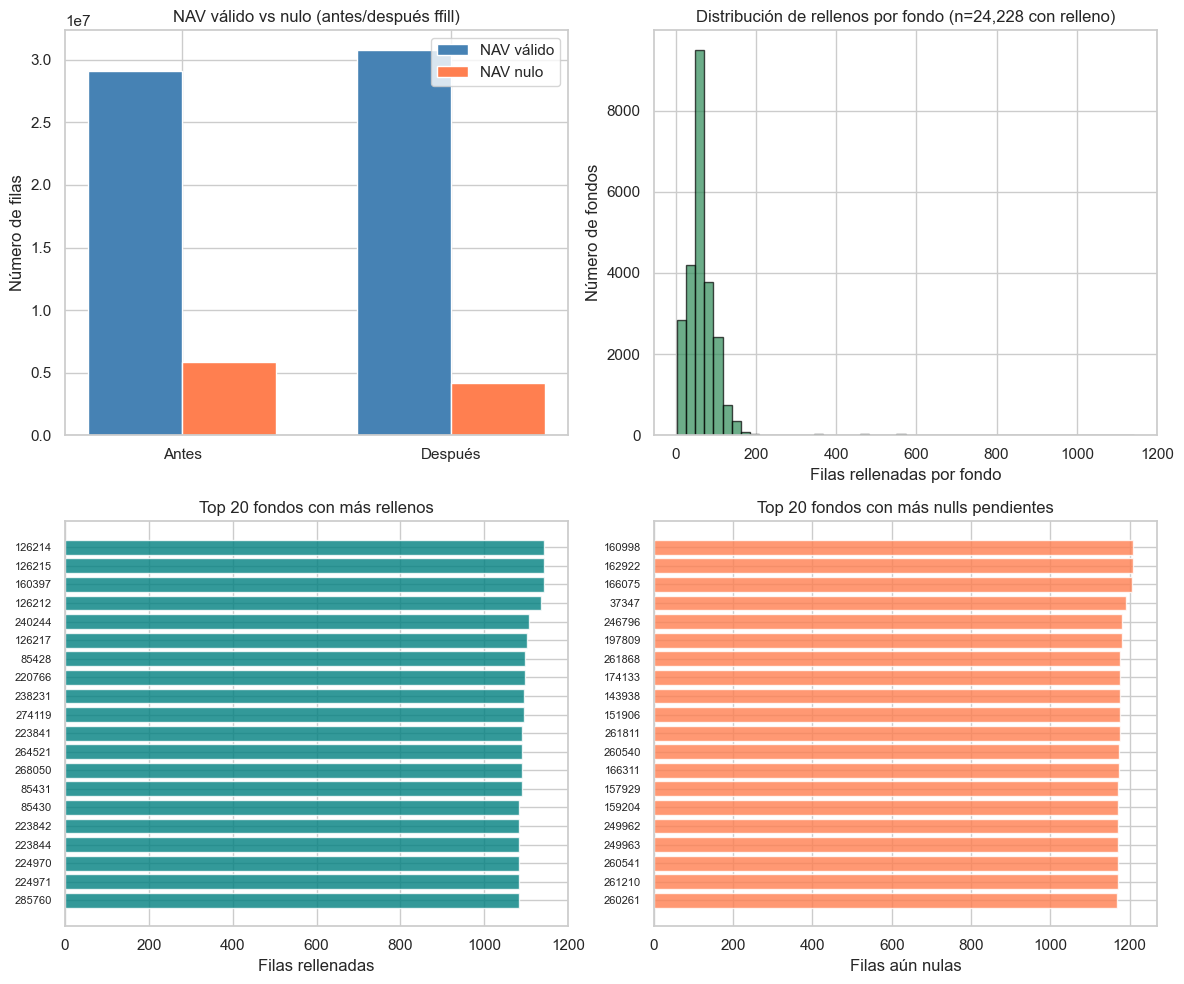


Panel con NAV imputado guardado en: data\daily_universe\panel_diario_imputado.parquet


In [16]:
# =============================================================================
# 4.3 – Tratamiento de filas: ffill limitado a 5 días
# =============================================================================

# Usar panel filtrado si existe (salida de 4.2) y con exclusiones aplicadas (4.1)
panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel
fund_col = "allfunds_id" if "allfunds_id" in panel_in.columns else "isin"
date_col = "date"

# Copia para no modificar el original
work = panel_in[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.sort_values([fund_col, date_col]).reset_index(drop=True)

# Verificación: tras 4.2 no deben quedar fines de semana
if (work[date_col].dt.weekday >= 5).any():
    raise ValueError("El panel de entrada debe estar filtrado a L–V (4.2) antes de 4.3.")

# --- Estado ANTES del ffill ---
n_total = len(work)
n_nav_null_antes = work["nav"].isna().sum()
n_nav_valido_antes = work["nav"].notna().sum()
pct_null_antes = 100 * n_nav_null_antes / n_total if n_total > 0 else 0.0

# --- Aplicar ffill(limit=5) por fondo ---
work["nav_original"] = work["nav"].copy()
work["nav"] = work.groupby(fund_col)["nav"].transform(lambda x: x.ffill(limit=5))

# --- Estado DESPUÉS del ffill ---
n_nav_null_despues = work["nav"].isna().sum()
n_nav_valido_despues = work["nav"].notna().sum()
n_rellenados = n_nav_valido_despues - n_nav_valido_antes
n_pendientes = n_nav_null_despues
pct_null_despues = 100 * n_nav_null_despues / n_total if n_total > 0 else 0.0
pct_rellenado = 100 * n_rellenados / n_nav_null_antes if n_nav_null_antes > 0 else 0.0

# --- Resumen por fondo ---
antes = panel_in.groupby(fund_col)["nav"].agg(lambda s: s.notna().sum()).rename("nav_valido_antes")
despues = work.groupby(fund_col)["nav"].agg(lambda s: s.notna().sum()).rename("nav_valido_despues")
por_fondo = pd.concat([antes, despues], axis=1).fillna(0).astype(int)
por_fondo["rellenados"] = (por_fondo["nav_valido_despues"] - por_fondo["nav_valido_antes"]).clip(lower=0)
por_fondo["pendientes"] = work.groupby(fund_col).size() - por_fondo["nav_valido_despues"]

# --- Salida ---
print("=" * 70)
print("4.3 – TRATAMIENTO DE FILAS: FFILL LIMITADO A 5 DÍAS")
print("=" * 70)
print(f"Panel de entrada: {len(panel_in):,} filas, {panel_in[fund_col].nunique():,} fondos")
print("-" * 70)
print("ANTES del ffill:")
print(f"  Filas con NAV válido:  {n_nav_valido_antes:,}")
print(f"  Filas con NAV nulo:    {n_nav_null_antes:,} ({pct_null_antes:.2f}%)")
print("-" * 70)
print("DESPUÉS del ffill(limit=5):")
print(f"  Filas con NAV válido:  {n_nav_valido_despues:,}")
print(f"  Filas rellenadas:      {n_rellenados:,} ({pct_rellenado:.1f}% de los nulls originales)")
print(f"  Filas aún nulas:       {n_pendientes:,} ({pct_null_despues:.2f}%)")
print("=" * 70)

# --- Tabla de control ---
print("\nTabla de control:")
resumen_43 = pd.DataFrame({
    "metrica": ["filas_total", "nav_valido", "nav_null", "pct_null"],
    "antes": [n_total, n_nav_valido_antes, n_nav_null_antes, f"{pct_null_antes:.2f}%"],
    "despues": [n_total, n_nav_valido_despues, n_pendientes, f"{pct_null_despues:.2f}%"],
})
display(resumen_43)

# --- Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Barras comparativas: nav válido vs null antes/después
ax1 = axes[0, 0]
x = ["Antes", "Después"]
valido = [n_nav_valido_antes, n_nav_valido_despues]
nulo = [n_nav_null_antes, n_pendientes]
x_pos = np.arange(len(x))
w = 0.35
ax1.bar(x_pos - w/2, valido, w, label="NAV válido", color="steelblue")
ax1.bar(x_pos + w/2, nulo, w, label="NAV nulo", color="coral")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x)
ax1.set_ylabel("Número de filas")
ax1.set_title("NAV válido vs nulo (antes/después ffill)")
ax1.legend()

# 2. Distribución de filas rellenadas por fondo
ax2 = axes[0, 1]
con_relleno = por_fondo[por_fondo["rellenados"] > 0]
bins = 10 if con_relleno.empty else min(50, int(con_relleno["rellenados"].max()) + 1)
ax2.hist(con_relleno["rellenados"], bins=bins, color="seagreen", edgecolor="black", alpha=0.7)
ax2.set_xlabel("Filas rellenadas por fondo")
ax2.set_ylabel("Número de fondos")
ax2.set_title(f"Distribución de rellenos por fondo (n={len(con_relleno):,} con relleno)")

# 3. Top 20 fondos con más filas rellenadas
ax3 = axes[1, 0]
top_relleno = por_fondo.nlargest(20, "rellenados")
ax3.barh(range(len(top_relleno)), top_relleno["rellenados"], color="teal", alpha=0.8)
ax3.set_yticks(range(len(top_relleno)))
ax3.set_yticklabels(top_relleno.index.astype(str), fontsize=8)
ax3.set_xlabel("Filas rellenadas")
ax3.set_title("Top 20 fondos con más rellenos")
ax3.invert_yaxis()

# 4. Top 20 fondos con más nulls pendientes
ax4 = axes[1, 1]
top_pend = por_fondo.nlargest(20, "pendientes")
ax4.barh(range(len(top_pend)), top_pend["pendientes"], color="coral", alpha=0.8)
ax4.set_yticks(range(len(top_pend)))
ax4.set_yticklabels(top_pend.index.astype(str), fontsize=8)
ax4.set_xlabel("Filas aún nulas")
ax4.set_title("Top 20 fondos con más nulls pendientes")
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

# --- Panel final para pipeline ---
# Reconstruir panel con columnas originales + nav imputado
if "daily_panel_clean" in globals():
    panel_out = daily_panel_clean.copy()
else:
    panel_out = daily_panel.copy()

# Actualizar solo la columna nav con los valores imputados
merge_cols = [fund_col, date_col]
panel_out = panel_out.merge(
    work[[fund_col, date_col, "nav"]].rename(columns={"nav": "nav_ffill"}),
    on=merge_cols,
    how="left",
)
panel_out["nav"] = panel_out["nav_ffill"].fillna(panel_out["nav"])
panel_out = panel_out.drop(columns=["nav_ffill"], errors="ignore")

daily_panel_imputed = panel_out

# --- Guardar en data/daily_universe como parquet ---
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "panel_diario_imputado.parquet"
daily_panel_imputed.to_parquet(OUT_PARQUET, index=False)
print(f"\nPanel con NAV imputado guardado en: {OUT_PARQUET}")

Interpretación de resultados – 4.3 ffill(limit=5)

Sobre un panel de **34.985.232** filas y **24.228** fondos, el `ffill` limitado a **5** días elevó las filas con NAV válido de **29.132.789** a **30.813.229**. Se rellenaron **1.680.440** celdas, es decir **28,7%** de los **5.852.443** nulls previos; la tasa de nulls bajó de **16,73%** a **11,93%** (quedan **4.172.003** filas con NAV nulo). El número total de filas no cambia: solo se imputa hacia adelante dentro del límite.

---

Explicaciones

**1. Alcance real del ffill(limit=5)**

- Solo una fracción de los nulls originales (**~29%**) pudo rellenarse: hace falta un NAV válido en los **5** días laborables previos y el hueco no puede ser más largo que ese límite en la dirección del relleno.
- **Interpretación:** La mayor parte de los nulls (**~71%** de los iniciales) no se recupera con esta regla: o bien el hueco supera **5** observaciones, o no hay valor previo (inicio de serie, fondo recién entrante, etc.), o la estructura del panel impide encadenar el `ffill` como se esperaba.

**2. Huecos cortos vs. largos y bordes**

- Los **1,68M** rellenos son coherentes con huecos **cortos** (calendario, publicación retrasada, parches puntuales) donde sí existía un NAV reciente.
- Los **4,17M** nulls restantes aglutinan huecos **largos** (más de **5** pasos rellenables), tramos sin historial previo al primer null, suspensiones, fondos con datos muy irregulares o salidas del universo.
- **Interpretación:** El `limit=5` cumple su función de **no estirar** demasiado la última observación; el coste es que gran parte de los missing permanece explícito.

**3. Coherencia con el pipeline (4.2 → 4.3)**

- Tras filtrar a **L–V** (4.2), el panel ya no mezcla fines de semana; el **16,73%** de null es el punto de partida **antes** de imputar.
- La caída a **11,93%** confirma que una parte importante del missing es **local y rellenable**, pero no la mayoría en términos de conteo de nulls.
---

### 4.4 – Diagnóstico de nulls restantes

Tras `ffill(limit=5)` (4.3), el panel sigue teniendo **~11,93%** de filas con NAV nulo (**~4,17M** filas sobre **34.985.232**), es decir, la imputación acotada dejó explícita una fracción grande de missing. Este bloque **caracteriza** esos nulls antes de aplicar reglas adicionales o exclusiones.

**Objetivo:** Describir *dónde* y *cómo* aparecen los nulls restantes (posición en la serie, longitud de huecos, fondos más expuestos) para justificar el tratamiento en pasos posteriores.

**Análisis:**
- **Posición en la serie:** clasificación por tramo — inicio (antes del primer NAV válido), medio (entre primer y último válido), fin (después del último válido).
- **Longitud de huecos:** secuencias consecutivas de NAV nulo en el tramo medio (huecos que `ffill` con `limit=5` no pudo cerrar).
- **Heterogeneidad por fondo:** proporción de nulls por fondo y fondos con mayor carga de missing.

**Fuente:** `data/daily_universe/panel_diario_imputado.parquet` (salida coherente con el panel post 4.3).

Cargado desde: data\daily_universe\panel_diario_imputado.parquet
4.4 – DIAGNÓSTICO DE NULLS RESTANTES
Panel: 34,985,232 filas, 24,228 fondos
Filas con NAV nulo: 4,172,003 (11.93%)
----------------------------------------------------------------------
UBICACIÓN DE NULLS (inicio/medio/fin):
  inicio  :  3,782,409 ( 90.7%)
  medio   :     93,605 (  2.2%)
  fin     :    295,989 (  7.1%)
----------------------------------------------------------------------
LONGITUD DE HUECOS (tramo medio, días hábiles consecutivos):
     1-5: 2,519 huecos
    6-10: 266 huecos
   11-20: 276 huecos
   21-50: 254 huecos
  51-100: 110 huecos
    >100: 212 huecos
----------------------------------------------------------------------
Top 10 fondos con más nulls restantes:


,allfunds_id,n_null,pct_null,n_inicio,n_medio,n_fin
6866,160998,1209,83.725762,1209,0,0
6917,162922,1209,83.725762,1209,0,0
7042,166075,1207,83.587258,1027,0,180
1902,37347,1192,82.548476,354,0,838
7920,246796,1182,81.855956,1182,0,0
7321,197809,1180,81.717452,1180,0,0
8175,261868,1177,81.509695,1172,5,0
7168,174133,1176,81.440443,1176,0,0
6036,143938,1175,81.371191,1175,0,0
6567,151906,1175,81.371191,1175,0,0


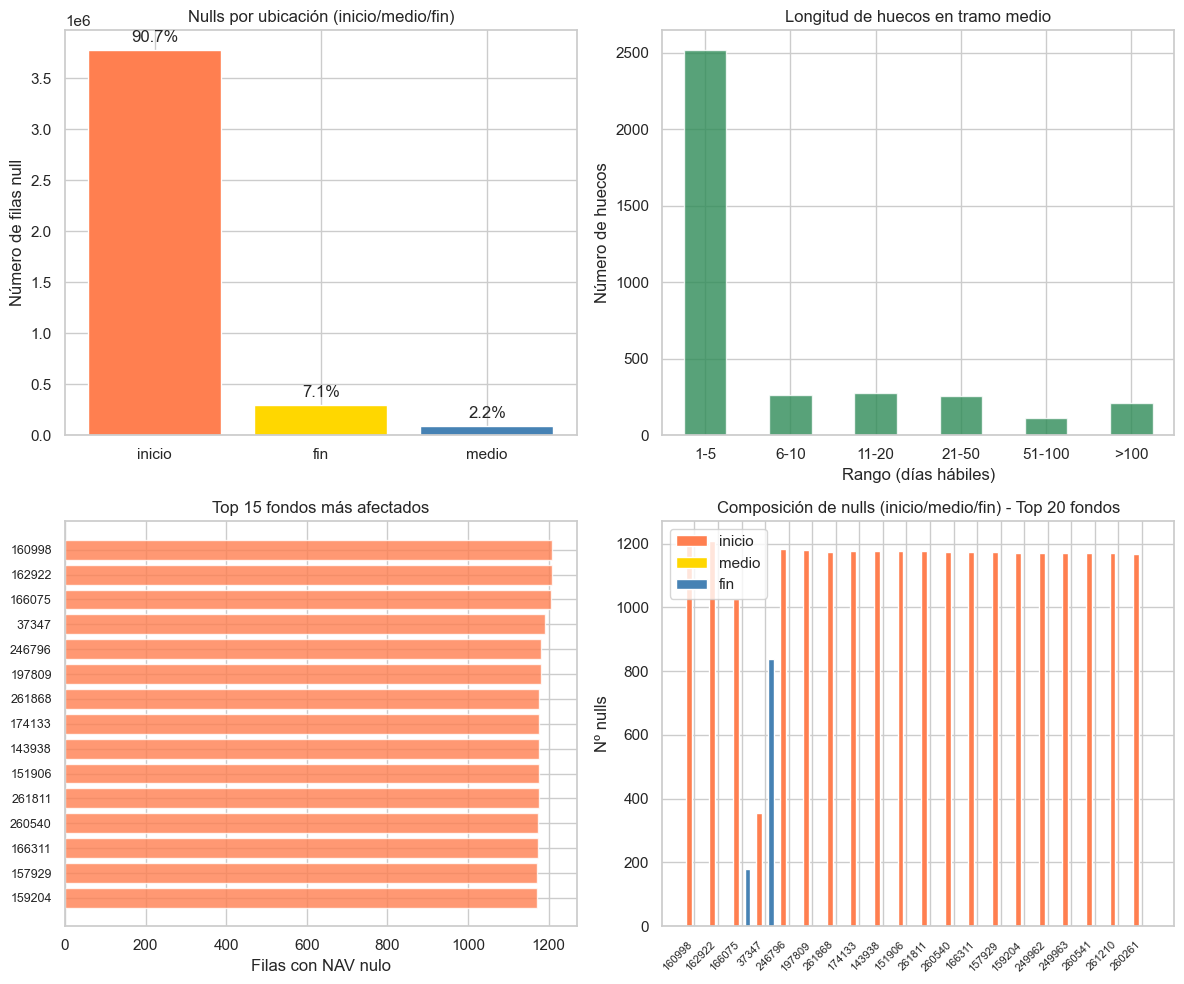


--- EVIDENCIA PARA DECISIÓN ---
Nulls en bordes (inicio+fin): 97.8%
Nulls en tramo medio: 2.2%
Huecos de 6-10 días (de 3,637 total): 266 (7.3%)


In [17]:
# =============================================================================
# 4.4 – Diagnóstico de nulls restantes
# =============================================================================
# Fuente: panel_diario_imputado.parquet (o daily_panel_imputed en memoria)
# Objetivo: Caracterizar nulls para decidir tratamiento posterior
# Requisitos (de 4.1 y 4.2):
#   - Fondos excluidos aplicados (4.1)
#   - Panel filtrado a L–V (4.2)
# =============================================================================

# Cargar panel (priorizar parquet si existe)
PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_imputado.parquet"
if PARQUET_PATH.exists():
    panel = pd.read_parquet(PARQUET_PATH)
    print(f"Cargado desde: {PARQUET_PATH}")
else:
    panel = daily_panel_imputed
    print("Usando daily_panel_imputed en memoria")

fund_col = "allfunds_id" if "allfunds_id" in panel.columns else "isin"
date_col = "date"
panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
panel = panel.sort_values([fund_col, date_col]).reset_index(drop=True)

# Verificación: tras 4.2 no deben quedar fines de semana
if (panel[date_col].dt.weekday >= 5).any():
    raise ValueError("El panel debe estar filtrado a L–V (4.2) antes de 4.4.")

# Solo filas con NAV nulo
null_rows = panel[panel["nav"].isna()].copy()
n_null_total = len(null_rows)
n_fondos = panel[fund_col].nunique()

# Si no hay nulls, imprimir y salir temprano de manera segura
if n_null_total == 0:
    print("=" * 70)
    print("4.4 – DIAGNÓSTICO DE NULLS RESTANTES")
    print("=" * 70)
    print(f"Panel: {len(panel):,} filas, {n_fondos:,} fondos")
    print("No hay filas con NAV nulo tras 4.3. No se requiere diagnóstico adicional.")
else:
    # --- Dónde están los nulls (inicio / medio / fin) ---
    valid_dates = (
        panel[panel["nav"].notna()]
        .groupby(fund_col)[date_col]
        .agg(["min", "max"])
        .rename(columns={"min": "primera_valido", "max": "ultima_valido"})
    )

    null_rows = null_rows.merge(valid_dates, left_on=fund_col, right_index=True, how="left")

    null_rows["ubicacion"] = "medio"
    null_rows.loc[null_rows[date_col] < null_rows["primera_valido"], "ubicacion"] = "inicio"
    null_rows.loc[null_rows[date_col] > null_rows["ultima_valido"], "ubicacion"] = "fin"

    dist_ubicacion = null_rows["ubicacion"].value_counts()
    dist_ubicacion_pct = 100 * dist_ubicacion / n_null_total

    # --- Longitud de huecos (solo en tramo medio) ---
    null_medio = null_rows[null_rows["ubicacion"] == "medio"].copy()
    null_medio = null_medio.sort_values([fund_col, date_col])

    # Nota: como el panel está en L–V, consideramos consecutivos si la fecha siguiente es prev + 1 BDay
    def gap_lengths_per_fund(df, fund_col, date_col):
        gaps = []
        for fid, g in df.groupby(fund_col):
            g = g.sort_values(date_col)
            dates = pd.to_datetime(g[date_col]).tolist()
            if len(dates) == 0:
                continue
            run = 1
            for i in range(1, len(dates)):
                prev_next_bday = dates[i - 1] + pd.offsets.BDay(1)
                if pd.Timestamp(dates[i]).normalize() == pd.Timestamp(prev_next_bday).normalize():
                    run += 1
                else:
                    gaps.append({"fund": fid, "gap_dias": run})
                    run = 1
            gaps.append({"fund": fid, "gap_dias": run})
        return pd.DataFrame(gaps)

    gaps_df = gap_lengths_per_fund(null_medio, fund_col, date_col)

    # Distribución de longitudes de hueco (en días hábiles consecutivos)
    if len(gaps_df) > 0:
        dist_gaps = gaps_df["gap_dias"].value_counts().sort_index()
        bins = [0, 5, 10, 21, 51, 101, 10000]
        labels = ["1-5", "6-10", "11-20", "21-50", "51-100", ">100"]
        gaps_df["rango"] = pd.cut(gaps_df["gap_dias"], bins=bins, labels=labels, right=True)
        dist_rango = gaps_df["rango"].value_counts().sort_index()
    else:
        dist_rango = pd.Series(dtype=int)
        dist_gaps = pd.Series(dtype=int)

    # --- Fondos más afectados ---
    por_fondo = null_rows.groupby(fund_col).agg(
        n_null=(date_col, "size"),
        n_inicio=("ubicacion", lambda x: (x == "inicio").sum()),
        n_medio=("ubicacion", lambda x: (x == "medio").sum()),
        n_fin=("ubicacion", lambda x: (x == "fin").sum()),
    ).reset_index()

    n_filas_por_fondo = panel.groupby(fund_col).size().rename("n_filas")
    por_fondo = por_fondo.merge(n_filas_por_fondo, left_on=fund_col, right_index=True)
    por_fondo["pct_null"] = 100 * por_fondo["n_null"] / por_fondo["n_filas"]
    por_fondo["pct_inicio"] = 100 * por_fondo["n_inicio"] / por_fondo["n_null"]
    por_fondo["pct_medio"] = 100 * por_fondo["n_medio"] / por_fondo["n_null"]
    por_fondo["pct_fin"] = 100 * por_fondo["n_fin"] / por_fondo["n_null"]

    top_afectados = por_fondo.nlargest(20, "n_null")

    # --- Salida ---
    print("=" * 70)
    print("4.4 – DIAGNÓSTICO DE NULLS RESTANTES")
    print("=" * 70)
    print(f"Panel: {len(panel):,} filas, {n_fondos:,} fondos")
    print(f"Filas con NAV nulo: {n_null_total:,} ({100*n_null_total/len(panel):.2f}%)")
    print("-" * 70)
    print("UBICACIÓN DE NULLS (inicio/medio/fin):")
    for u in ["inicio", "medio", "fin"]:
        n = int(dist_ubicacion.get(u, 0))
        p = float(dist_ubicacion_pct.get(u, 0))
        print(f"  {u:8s}: {n:>10,} ({p:5.1f}%)")
    print("-" * 70)
    print("LONGITUD DE HUECOS (tramo medio, días hábiles consecutivos):")
    if len(dist_rango) > 0:
        for r, c in dist_rango.items():
            print(f"  {str(r):>6s}: {c:,} huecos")
    else:
        print("  (sin huecos en tramo medio)")
    print("-" * 70)
    print("Top 10 fondos con más nulls restantes:")
    display(top_afectados[[fund_col, "n_null", "pct_null", "n_inicio", "n_medio", "n_fin"]].head(10))
    print("=" * 70)

    # --- Gráficos ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Ubicación de nulls
    ax1 = axes[0, 0]
    ax1.bar(dist_ubicacion.index, dist_ubicacion.values, color=["coral", "gold", "steelblue"])
    ax1.set_ylabel("Número de filas null")
    ax1.set_title("Nulls por ubicación (inicio/medio/fin)")
    ymax = max(dist_ubicacion.values) if len(dist_ubicacion) else 0
    for i, (k, v) in enumerate(dist_ubicacion.items()):
        ax1.text(i, v + (0.02 * ymax if ymax > 0 else 0.0), f"{dist_ubicacion_pct[k]:.1f}%", ha="center")

    # 2. Distribución de longitud de huecos
    ax2 = axes[0, 1]
    if len(dist_rango) > 0:
        dist_rango.plot(kind="bar", ax=ax2, color="seagreen", alpha=0.8)
    ax2.set_xlabel("Rango (días hábiles)")
    ax2.set_ylabel("Número de huecos")
    ax2.set_title("Longitud de huecos en tramo medio")
    ax2.tick_params(axis="x", rotation=0)

    # 3. Top 15 fondos con más nulls
    ax3 = axes[1, 0]
    top15 = por_fondo.nlargest(15, "n_null")
    ax3.barh(range(len(top15)), top15["n_null"], color="coral", alpha=0.8)
    ax3.set_yticks(range(len(top15)))
    ax3.set_yticklabels(top15[fund_col].astype(str), fontsize=9)
    ax3.set_xlabel("Filas con NAV nulo")
    ax3.set_title("Top 15 fondos más afectados")
    ax3.invert_yaxis()

    # 4. Composición de nulls (inicio/medio/fin) - Top 20 fondos
    ax4 = axes[1, 1]
    top20 = por_fondo.nlargest(20, "n_null")
    x = range(len(top20))
    w = 0.25
    ax4.bar([i - w for i in x], top20["n_inicio"], w, label="inicio", color="coral")
    ax4.bar(x, top20["n_medio"], w, label="medio", color="gold")
    ax4.bar([i + w for i in x], top20["n_fin"], w, label="fin", color="steelblue")
    ax4.set_xticks(x)
    ax4.set_xticklabels(top20[fund_col].astype(str), rotation=45, ha="right", fontsize=8)
    ax4.set_ylabel("Nº nulls")
    ax4.set_title("Composición de nulls (inicio/medio/fin) - Top 20 fondos")
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # --- Resumen para decisión ---
    pct_inicio = float(dist_ubicacion_pct.get("inicio", 0))
    pct_medio = float(dist_ubicacion_pct.get("medio", 0))
    pct_fin = float(dist_ubicacion_pct.get("fin", 0))
    n_huecos_6_10 = int(dist_rango.get("6-10", 0)) if len(dist_rango) > 0 else 0
    n_huecos_total = int(dist_rango.sum()) if len(dist_rango) > 0 else 0
    pct_huecos_6_10 = 100 * n_huecos_6_10 / n_huecos_total if n_huecos_total > 0 else 0

    print("\n--- EVIDENCIA PARA DECISIÓN ---")
    print(f"Nulls en bordes (inicio+fin): {pct_inicio + pct_fin:.1f}%")
    print(f"Nulls en tramo medio: {pct_medio:.1f}%")
    print(f"Huecos de 6-10 días (de {n_huecos_total:,} total): {n_huecos_6_10:,} ({pct_huecos_6_10:.1f}%)")

### 4.5 – Recorte temporal por fondo (eliminación de nulls estructurales en bordes)

**Ubicación de esos nulls (inicio / medio / fin):**

| Tramo   | Filas nulas | % sobre nulls |
|---------|------------:|---------------:|
| Inicio  | 3.782.409   | **90,7%**      |
| Medio   |    93.605   | **2,2%**       |
| Fin     |   295.989   | **7,1%**       |

En conjunto, **~97,8%** de los nulls están en **bordes** (inicio + fin); solo **~2,2%** caen en el **tramo medio** entre el primer y el último NAV válido.

---

**Origen del problema**

El panel usa un **calendario global** (p. ej. desde una fecha fija de inicio). Cada fondo tiene fila en cada día del rango aunque aún no existiera en el universo o ya hubiera dejado de publicar. Así:

- Fondos que **empiezan tarde** acumulan nulls de **inicio** (años sin datos reales).
- Fondos que **dejan de publicar** acumulan nulls de **fin** hasta el cierre del panel.

---

**Propuesta de tratamiento**

**Regla A – Entrada:** Cada fondo **entra** en el análisis en la fecha de su **primer NAV válido**. Se eliminan todas las filas anteriores (nulls de inicio).

**Regla B – Salida / universo invertible al cierre:** Se **excluyen del panel** los fondos que **no tienen NAV válido en el último día hábil** del rango del dataset (coherente con el filtro L–V de la sección 4.2). La razón es de **decisión de inversión**: si el objetivo es analizar un universo del que luego **seleccionar** fondos para invertir, solo son elegibles los que **existen y son observables** en la fecha de corte; un fondo ya liquidado o sin publicación al final del panel no puede formar parte de esa selección.

*Nota metodológica:* cabría **mantener** fondos sin dato en el último día para **alargar el historial** disponible en entrenamiento o en regresiones retrospectivas (más observaciones por fondo en el pasado). En este trabajo se **decide no** hacerlo: el número de fondos que permanece tras las reglas anteriores sigue siendo **muy alto** y los pasos posteriores exigen calcular **muchas características por fondo**; por **simplicidad y coste computacional**, se prioriza un panel más pequeño y directamente alineado con el **universo invertible al último día**, en lugar de conservar series muertas solo por aportar más filas históricas al modelo.

**Regla C – Fondos con huecos en medio:** Los fondos con NAV nulo **entre** el primer y el último NAV válido se **excluyen por completo**. Tras el `ffill(limit=5)`, esos nulls medios son **pocos en relación con el total de missing** (**~2,2%** de los nulls totales) pero son los más **difíciles de interpretar** sin imputaciones agresivas; se prioriza **integridad por fondo** frente a conservar series con huecos internos inexplicados.

Cargado desde: data\daily_universe\panel_diario_imputado.parquet
4.5 – RECORTE TEMPORAL POR FONDO

Último día hábil del panel: 2021-07-16

--- REGLA C: Fondos con huecos en medio ---
  Fondos con huecos en medio: 2,144

--- REGLA B: Sin NAV válido en último día hábil ---
  Fondos excluidos (sin NAV en último día): 1,332

--- Total excluido (unión C ∪ B; incluye sin datos vía B) ---
  Fondos excluidos (total): 3,309
  Filas eliminadas: 4,778,196

--- REGLAS A y recorte [primera, última] válida ---
  Filas antes recorte: 30,207,036
  Filas después recorte: 27,023,569
  Filas eliminadas (bordes): 3,183,467

--- COMPARATIVA GLOBAL ---
----------------------------------------------------------------------
Métrica                       Antes (4.3)   Después (4.5)          Cambio
----------------------------------------------------------------------
Filas                          34,985,232      27,023,569      -7,961,663
Fondos                             24,228          20,919          -3,3

,etapa,n_filas,n_fondos,n_nav_null,pct_null
0,4.3 imputado,34985232,24228,4172003,11.92504
1,4.5 recortado,27023569,20919,0,0.00000


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6804\4032430229.py:138: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


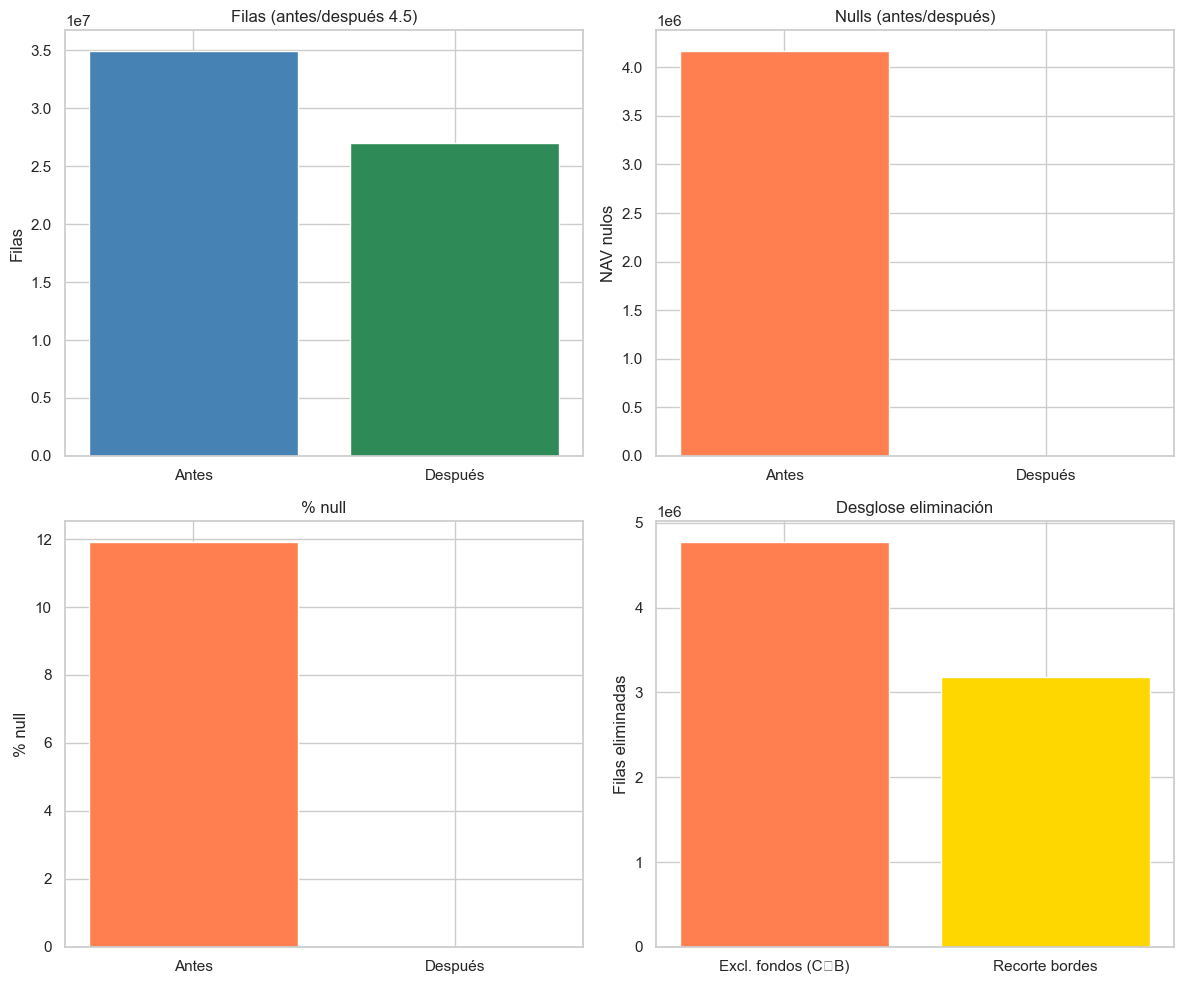


Guardado: data\daily_universe\panel_diario_recortado.parquet


In [18]:
# =============================================================================
# 4.5 – Recorte temporal por fondo
# =============================================================================
# Requisitos previos:
#   - 4.1 exclusión de fondos aplicada en el panel de entrada
#   - 4.2 filtrado a L–V aplicado
#   - 4.3 imputación (ffill limitado) ya realizada y guardada en parquet
# Fuente prioritaria: data/daily_universe/panel_diario_imputado.parquet
# Objetivo:
#   - Regla C: excluir fondos con huecos en medio (nulls entre 1ª y última fecha válida)
#   - Regla B: excluir fondos sin NAV válido en el último día hábil del panel (universo invertible)
#   - Reglas A y B (recorte): recortar cada fondo superviviente a [primera_valido, ultima_valido]
# =============================================================================

PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_imputado.parquet"
if PARQUET_PATH.exists():
    panel = pd.read_parquet(PARQUET_PATH)
    print(f"Cargado desde: {PARQUET_PATH}")
else:
    panel = daily_panel_imputed.copy()
    print("Usando daily_panel_imputed en memoria")

fund_col = "allfunds_id" if "allfunds_id" in panel.columns else "isin"
date_col = "date"
panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
panel = panel.sort_values([fund_col, date_col]).reset_index(drop=True)

# Verificación L–V coherente con 4.2
if (panel[date_col].dt.weekday >= 5).any():
    raise ValueError("El panel debe estar filtrado a L–V (4.2) antes de 4.5.")

# --- Estado INICIAL ---
n_filas_antes = len(panel)
n_fondos_antes = panel[fund_col].nunique()
n_null_antes = panel["nav"].isna().sum()
pct_null_antes = 100 * n_null_antes / n_filas_antes if n_filas_antes > 0 else 0.0

# --- Bounds por fondo (vectorizado) ---
valid = panel[panel["nav"].notna()]
primera = valid.groupby(fund_col)[date_col].min().rename("primera_valido")
ultima = valid.groupby(fund_col)[date_col].max().rename("ultima_valido")
bounds = pd.concat([primera, ultima], axis=1)

# Fondos sin ningún dato válido (todo NaN en nav): excluir
sin_datos = set(panel[fund_col].unique()) - set(valid[fund_col].unique())
bounds = bounds[~bounds.index.isin(sin_datos)]

# --- Último día hábil del panel (calendario global) ---
last_panel_date = panel[date_col].max()
on_last = panel[panel[date_col] == last_panel_date]
funds_with_nav_last = set(on_last.loc[on_last["nav"].notna(), fund_col].unique())
funds_all = set(panel[fund_col].unique())
fondos_sin_nav_ultimo_dia = funds_all - funds_with_nav_last

# --- Regla C: fondos con huecos en medio (vectorizado) ---
panel_b = panel.merge(bounds, left_on=fund_col, right_index=True, how="inner")
en_rango = (panel_b[date_col] >= panel_b["primera_valido"]) & (panel_b[date_col] <= panel_b["ultima_valido"])
panel_medio = panel_b[en_rango]
fondos_con_huecos = set(panel_medio[panel_medio["nav"].isna()][fund_col].unique())
fondos_excluir = fondos_con_huecos | fondos_sin_nav_ultimo_dia

panel_sin_huecos = panel[~panel[fund_col].isin(fondos_excluir)].copy()
n_fondos_excl_C = len(fondos_excluir)
n_filas_excl_C = n_filas_antes - len(panel_sin_huecos)

# --- Reglas A y B: recorte (vectorizado) ---
bounds_ok = bounds[~bounds.index.isin(fondos_excluir)]
panel_m = panel_sin_huecos.merge(bounds_ok, left_on=fund_col, right_index=True, how="inner")
panel_recortado = panel_m[
    (panel_m[date_col] >= panel_m["primera_valido"]) &
    (panel_m[date_col] <= panel_m["ultima_valido"])
].drop(columns=["primera_valido", "ultima_valido"])

# --- Estado FINAL ---
n_filas_despues = len(panel_recortado)
n_fondos_despues = panel_recortado[fund_col].nunique()
n_null_despues = panel_recortado["nav"].isna().sum()
pct_null_despues = 100 * n_null_despues / n_filas_despues if n_filas_despues > 0 else 0.0

# --- Salida ---
print("=" * 70)
print("4.5 – RECORTE TEMPORAL POR FONDO")
print("=" * 70)
print(f"\nÚltimo día hábil del panel: {last_panel_date.date()}")
print("\n--- REGLA C: Fondos con huecos en medio ---")
print(f"  Fondos con huecos en medio: {len(fondos_con_huecos):,}")
print("\n--- REGLA B: Sin NAV válido en último día hábil ---")
print(f"  Fondos excluidos (sin NAV en último día): {len(fondos_sin_nav_ultimo_dia):,}")
print("\n--- Total excluido (unión C ∪ B; incluye sin datos vía B) ---")
print(f"  Fondos excluidos (total): {n_fondos_excl_C:,}")
print(f"  Filas eliminadas: {n_filas_excl_C:,}")

print("\n--- REGLAS A y recorte [primera, última] válida ---")
print(f"  Filas antes recorte: {len(panel_sin_huecos):,}")
print(f"  Filas después recorte: {n_filas_despues:,}")
print(f"  Filas eliminadas (bordes): {len(panel_sin_huecos) - n_filas_despues:,}")

print("\n--- COMPARATIVA GLOBAL ---")
print("-" * 70)
print(f"{'Métrica':<25} {'Antes (4.3)':>15} {'Después (4.5)':>15} {'Cambio':>15}")
print("-" * 70)
print(f"{'Filas':<25} {n_filas_antes:>15,} {n_filas_despues:>15,} {n_filas_despues - n_filas_antes:>15,}")
print(f"{'Fondos':<25} {n_fondos_antes:>15,} {n_fondos_despues:>15,} {n_fondos_despues - n_fondos_antes:>15,}")
print(f"{'NAV nulos':<25} {n_null_antes:>15,} {n_null_despues:>15,} {n_null_despues - n_null_antes:>15,}")
print(f"{'% null':<25} {pct_null_antes:>14.2f}% {pct_null_despues:>14.2f}% {pct_null_despues - pct_null_antes:>14.2f}%")
print("=" * 70)

resumen_pipeline = pd.DataFrame({
    "etapa": ["4.3 imputado", "4.5 recortado"],
    "n_filas": [n_filas_antes, n_filas_despues],
    "n_fondos": [n_fondos_antes, n_fondos_despues],
    "n_nav_null": [n_null_antes, n_null_despues],
    "pct_null": [pct_null_antes, pct_null_despues],
})
display(resumen_pipeline)

# --- Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1 = axes[0, 0]
ax1.bar(["Antes", "Después"], [n_filas_antes, n_filas_despues], color=["steelblue", "seagreen"])
ax1.set_ylabel("Filas")
ax1.set_title("Filas (antes/después 4.5)")

ax2 = axes[0, 1]
ax2.bar(["Antes", "Después"], [n_null_antes, n_null_despues], color=["coral", "seagreen"])
ax2.set_ylabel("NAV nulos")
ax2.set_title("Nulls (antes/después)")

ax3 = axes[1, 0]
ax3.bar(["Antes", "Después"], [pct_null_antes, pct_null_despues], color=["coral", "seagreen"])
ax3.set_ylabel("% null")
ax3.set_title("% null")

ax4 = axes[1, 1]
ax4.bar(["Excl. fondos (C∪B)", "Recorte bordes"], [n_filas_excl_C, len(panel_sin_huecos) - n_filas_despues], color=["coral", "gold"])
ax4.set_ylabel("Filas eliminadas")
ax4.set_title("Desglose eliminación")
plt.tight_layout()
plt.show()

# --- Guardar ---
panel_final_45 = panel_recortado.copy()
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
panel_final_45.to_parquet(OUT_DIR / "panel_diario_recortado.parquet", index=False)
print(f"\nGuardado: {OUT_DIR / 'panel_diario_recortado.parquet'}")

### 4.6 - Exploración de umbrales 

Para la exclusión de posibles outliers usamos **dos métricas** ya calculadas en 3.4: **`pct_extremos_pct`** y **`pct_extremos_iqr`**, restringidas a fondos con historial suficiente (`n_ret_valid ≥ 252`) y alineadas con el panel post 4.5.

En la siguiente celda **probamos distintos percentiles** (p. ej. P90–P99) y dibujamos la **distribución conjunta** y las **rectas de corte**. Con esa visualización y el conteo de fondos que caerían fuera con cada regla, **elegimos el umbral** (o la combinación asimétrica) que equilibre limpieza y tamaño del universo.

P90: pct>0.0498% | iqr>0.3206%  →  fondos OR>90: 2,939 (12.31%)
P95: pct>0.0707% | iqr>0.3687%  →  fondos OR>95: 1,458 (6.11%)
P97: pct>0.0909% | iqr>0.4139%  →  fondos OR>97: 858 (3.59%)
P98: pct>0.1096% | iqr>0.4569%  →  fondos OR>98: 578 (2.42%)
P99: pct>0.1380% | iqr>0.4993%  →  fondos OR>99: 305 (1.28%)


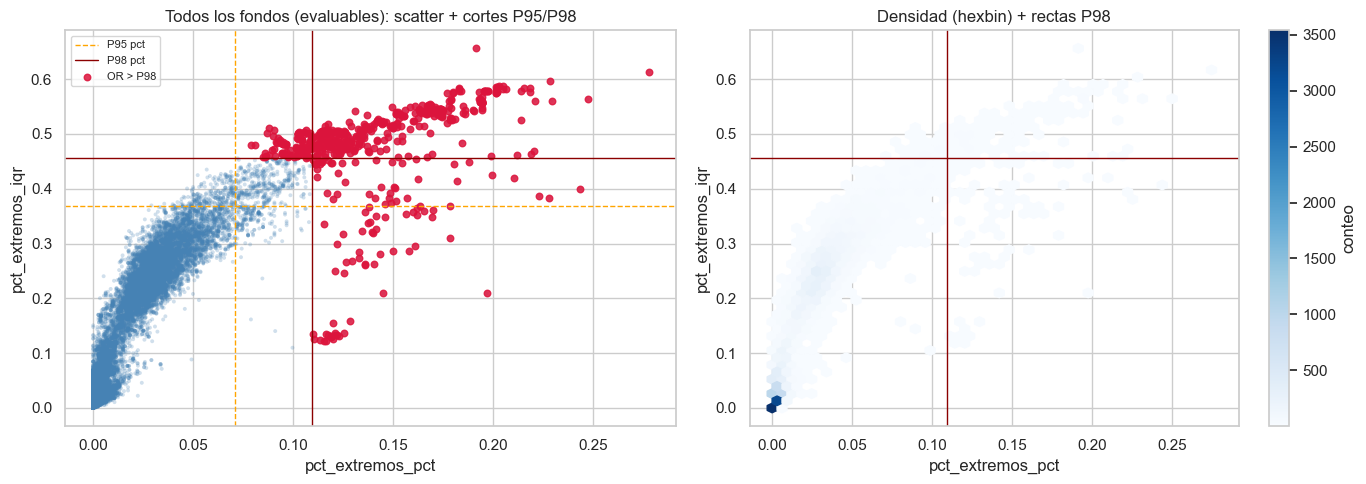

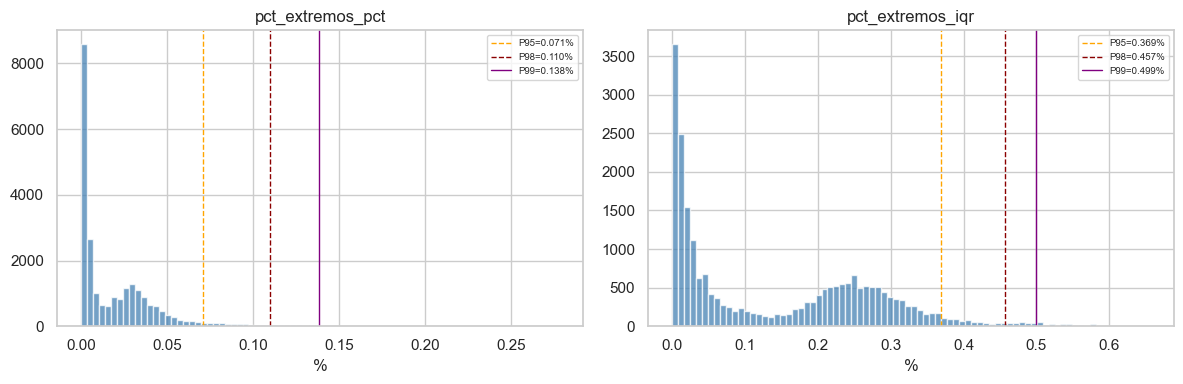

In [19]:
# --- Preparar anom_df para exploración de umbrales (4.6) ---
if "ret_quality_34" not in globals():
    raise RuntimeError("Ejecuta antes la sección 3.4.")

anom_df = ret_quality_34.copy()

# Normalización
cand_fund_cols = [c for c in ["allfunds_id", "isin"] if c in anom_df.columns]
anom_fund_col  = cand_fund_cols[0]
for c in ["pct_extremos_pct", "pct_extremos_iqr"]:
    anom_df[c] = pd.to_numeric(anom_df[c], errors="coerce")
anom_df["n_ret_valid"] = pd.to_numeric(anom_df["n_ret_valid"], errors="coerce")

MIN_OBS   = 252
eval_mask = anom_df["n_ret_valid"] >= MIN_OBS
plot_df = anom_df.loc[eval_mask, ["pct_extremos_pct", "pct_extremos_iqr", anom_fund_col]].dropna()

# Cuantiles a comparar (itera visualmente)
for q in (0.90, 0.95, 0.97, 0.98, 0.99):
    vx = plot_df["pct_extremos_pct"].quantile(q)
    vy = plot_df["pct_extremos_iqr"].quantile(q)
    n_or = ((plot_df["pct_extremos_pct"] > vx) | (plot_df["pct_extremos_iqr"] > vy)).sum()
    print(f"P{q*100:g}: pct>{vx:.4f}% | iqr>{vy:.4f}%  →  fondos OR>{q*100:g}: {n_or:,} ({100*n_or/len(plot_df):.2f}%)")

# --- 1) Scatter: todos los fondos + líneas P95 y P98 ---
q_low, q_high = 0.95, 0.98
x95 = plot_df["pct_extremos_pct"].quantile(q_low)
y95 = plot_df["pct_extremos_iqr"].quantile(q_low)
x98 = plot_df["pct_extremos_pct"].quantile(q_high)
y98 = plot_df["pct_extremos_iqr"].quantile(q_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(plot_df["pct_extremos_pct"], plot_df["pct_extremos_iqr"], alpha=0.25, s=8, c="steelblue", edgecolors="none")
ax.axvline(x95, color="orange", ls="--", lw=1, label=f"P{q_low*100:.0f} pct")
ax.axhline(y95, color="orange", ls="--", lw=1)
ax.axvline(x98, color="darkred", ls="-", lw=1, label=f"P{q_high*100:.0f} pct")
ax.axhline(y98, color="darkred", ls="-", lw=1)
mask_or98 = (plot_df["pct_extremos_pct"] > x98) | (plot_df["pct_extremos_iqr"] > y98)
ax.scatter(plot_df.loc[mask_or98, "pct_extremos_pct"], plot_df.loc[mask_or98, "pct_extremos_iqr"],
           s=22, c="crimson", alpha=0.85, label="OR > P98")
ax.set_xlabel("pct_extremos_pct")
ax.set_ylabel("pct_extremos_iqr")
ax.set_title("Todos los fondos (evaluables): scatter + cortes P95/P98")
ax.legend(loc="upper left", fontsize=8)

# --- 2) Hexbin: densidad (mejor si hay mucho solapamiento) ---
ax = axes[1]
hb = ax.hexbin(plot_df["pct_extremos_pct"], plot_df["pct_extremos_iqr"], gridsize=45, mincnt=1, cmap="Blues")
plt.colorbar(hb, ax=ax, label="conteo")
ax.axvline(x98, color="darkred", ls="-", lw=1)
ax.axhline(y98, color="darkred", ls="-", lw=1)
ax.set_xlabel("pct_extremos_pct")
ax.set_ylabel("pct_extremos_iqr")
ax.set_title("Densidad (hexbin) + rectas P98")

plt.tight_layout()
plt.show()

# --- 3) Histogramas marginales con cortes ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(["pct_extremos_pct", "pct_extremos_iqr"]):
    ax[i].hist(plot_df[col], bins=80, color="steelblue", alpha=0.75, edgecolor="white")
    for q, c in [(0.95, "orange"), (0.98, "darkred"), (0.99, "purple")]:
        v = plot_df[col].quantile(q)
        ax[i].axvline(v, color=c, ls="--" if q < 0.99 else "-", lw=1, label=f"P{q*100:.0f}={v:.3f}%")
    ax[i].set_title(col)
    ax[i].set_xlabel("%")
    ax[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 4.7 – Exclusión de fondos “outliers” (pct_extremos_pct y pct_extremos_iqr)

- **Objetivo:** reducir fondos con un perfil anómalo de días extremos en retornos diarios, sin vaciar el universo, antes del feature engineering y el modelado.
- **Salida:** `panel_diario_filtrado_outliers.parquet` y `exclusions_46` (trazabilidad).

---

**Base empírica — exploración de umbrales**

Previamente se analizó el mismo universo evaluable (fondos con `n_ret_valid ≥ 252`, alineados al panel post 4.5): se recorrieron varios percentiles (p. ej. P90–P99), se tabularon cuántos fondos caerían fuera con reglas **OR** simétricas y se representó la **distribución conjunta** de las dos métricas (scatter, hexbin, histogramas con cortes). Esa exploración mostró que un **OR simétrico muy bajo** (p. ej. P90) excluye una fracción demasiado grande del universo, mientras que un **P98 en ambas** dimensiones es muy conservador. La decisión siguiente se apoya en esa visualización y en esos conteos, no solo en un umbral fijo a priori.

---

**Métricas (sección 3.4)**

- **`pct_extremos_pct`:** proporción de días con retornos fuera de colas definidas por percentiles globales de la muestra.
- **`pct_extremos_iqr`:** proporción de días fuera de un rango tipo IQR (fences).

Miden aspectos distintos de “extremidad”; por eso es razonable no imponer el **mismo** percentil a las dos si el objetivo es ser algo más estricto en una dimensión y más selectivo en la otra.

---

**Regla adoptada (OR asimétrica, sin caps absolutos)**

Sobre el universo evaluable anterior, se excluye un fondo si se cumple **al menos una** de estas condiciones:

1. `pct_extremos_pct` **>** **P95** (calculado en cruz sobre ese universo), **o**
2. `pct_extremos_iqr` **>** **P98** (idem),

y además **`n_ret_valid ≥ 252`**.

**Por qué esta combinación:** el corte **P95 en `pct_extremos_pct`** detecta con más sensibilidad fondos con muchos días extremos según la definición por percentiles globales. El corte **P98 en `pct_extremos_iqr`** mantiene una cola más fina para la métrica basada en IQR, evitando alinear ambas ramas al mismo percentil cuando la distribución y el significado económico no son idénticos. El **OR** implica que basta con ser cola marcada en **una** de las dos definiciones para ser revisado/excluido; el tamaño efectivo de la exclusión queda **entre** un OR simétrico P95 (~6% del universo evaluable en vuestra tabla) y un OR simétrico P98 (~2,4%), según el solape entre las dos métricas — valor que debe comprobarse en la salida numérica de la celda 4.6.

---

**Pasos operativos**

1. Cargar `panel_diario_recortado.parquet` (4.5) y `ret_quality_34` (3.4).  
2. Alinear identificadores al universo post 4.5.  
3. Calcular **P95** de `pct_extremos_pct` y **P98** de `pct_extremos_iqr` solo sobre filas con `n_ret_valid ≥ 252` y métricas no nulas.  
4. Aplicar la regla OR anterior, generar `exclusions_46` y el panel filtrado.

In [20]:
# =============================================================================
# 4.7 – Exclusión de fondos “outliers” (pct_extremos_pct, pct_extremos_iqr)
# =============================================================================
# Entrada:
#   - panel_diario_recortado.parquet  (salida de 4.5)
#   - Tabla 3.4 en memoria:
#       * `ret_quality_34` (contiene: fund_id, pct_extremos_pct, pct_extremos_iqr, n_ret_valid)
# Salida:
#   - panel_diario_filtrado_outliers.parquet
#   - exclusions_46 (DataFrame en memoria y guardado)
# Regla (diario – OR asimétrico P95 / P98, sin caps):
#   - Aplica solo si n_ret_valid >= 252
#   - Excluir si (pct_extremos_pct > P95) OR (pct_extremos_iqr > P98)
#   - P95 y P98 calculados sobre el universo post 4.5 y métricas válidas (eval_df)
# =============================================================================

# --- Carga del panel 4.5 ---
IN_DIR = Path("data") / "daily_universe"
PANEL_45_PATH = IN_DIR / "panel_diario_recortado.parquet"
if not PANEL_45_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {PANEL_45_PATH}. Ejecuta antes el punto 4.5.")

panel_45 = pd.read_parquet(PANEL_45_PATH)
fund_col = "allfunds_id" if "allfunds_id" in panel_45.columns else "isin"
date_col = "date"
panel_45[date_col] = pd.to_datetime(panel_45[date_col], errors="coerce")

# --- Carga de métricas (3.4) en memoria ---
if "ret_quality_34" not in globals():
    raise RuntimeError("No se encontró 'ret_quality_34' en memoria. Ejecuta antes la sección 3.4.")

anom_df = ret_quality_34.copy()
print("Usando métricas de 3.4 desde 'ret_quality_34'.")

# --- Normalización de identificador y columnas requeridas ---
cand_fund_cols = [c for c in ["allfunds_id", "isin"] if c in anom_df.columns]
if not cand_fund_cols:
    raise KeyError("La tabla de 3.4 no contiene 'allfunds_id' ni 'isin'.")
anom_fund_col = cand_fund_cols[0]

required_cols = ["pct_extremos_pct", "pct_extremos_iqr", "n_ret_valid"]
missing = [c for c in required_cols if c not in anom_df.columns]
if missing:
    raise KeyError(f"Faltan columnas en la tabla de 3.4: {missing}")

# --- Alinear con universo post 4.5 ---
fondos_45 = set(panel_45[fund_col].unique())
anom_df = anom_df[anom_df[anom_fund_col].isin(fondos_45)].copy()

# Asegurar numérico y límites lógicos 0–100 en porcentajes
for c in ["pct_extremos_pct", "pct_extremos_iqr"]:
    anom_df[c] = pd.to_numeric(anom_df[c], errors="coerce")
    anom_df.loc[anom_df[c] < 0, c] = 0
    anom_df.loc[anom_df[c] > 100, c] = 100
anom_df["n_ret_valid"] = pd.to_numeric(anom_df["n_ret_valid"], errors="coerce")

# --- Filtro de tamaño mínimo ---
MIN_OBS = 252
eval_mask = anom_df["n_ret_valid"] >= MIN_OBS

# --- Cuantiles sobre universo evaluable (post 4.5) ---
eval_df = anom_df.loc[eval_mask, ["pct_extremos_pct", "pct_extremos_iqr"]].dropna()
if len(eval_df) == 0:
    raise RuntimeError("No hay fondos evaluables (n_ret_valid >= 252 y métricas no nulas). Revisa 3.4 o el pipeline previo.")

Q_PCT = 0.95   # percentil para pct_extremos_pct
Q_IQR = 0.98   # percentil para pct_extremos_iqr
p95_pct = eval_df["pct_extremos_pct"].quantile(Q_PCT)
p98_iqr = eval_df["pct_extremos_iqr"].quantile(Q_IQR)

# --- Regla OR asimétrico P95 / P98 (sin caps) ---
cond_pct = anom_df["pct_extremos_pct"] > p95_pct
cond_iqr = anom_df["pct_extremos_iqr"] > p98_iqr
rule_or_p95_p98 = (cond_pct | cond_iqr) & eval_mask
rule_or_p95_p98 = rule_or_p95_p98.fillna(False)  # NaN => no evaluable, no excluir por ello

# --- Exclusiones con trazabilidad ---
exclusions_46 = anom_df.loc[rule_or_p95_p98, [anom_fund_col, "pct_extremos_pct", "pct_extremos_iqr", "n_ret_valid"]].copy()
exclusions_46["p95_pct"] = float(p95_pct)
exclusions_46["p98_iqr"] = float(p98_iqr)
exclusions_46["regla_aplicada"] = "OR_P95pct_P98iqr"

n_excl_fondos = exclusions_46[anom_fund_col].nunique()

# --- Aplicar exclusión al panel 4.5 ---
fondos_excluir = set(exclusions_46[anom_fund_col].unique())
panel_before_rows = len(panel_45)
panel_before_funds = panel_45[fund_col].nunique()

panel_46 = panel_45[~panel_45[fund_col].isin(fondos_excluir)].copy()

panel_after_rows = len(panel_46)
panel_after_funds = panel_46[fund_col].nunique()

# --- Resumen ---
print("=" * 70)
print("4.6 – EXCLUSIÓN DE FONDOS OUTLIERS (pct_extremos_pct / pct_extremos_iqr)")
print("=" * 70)
print(f"Fondos (antes 4.6): {panel_before_funds:,}   | Filas: {panel_before_rows:,}")
print(f"Fondos excluidos  : {n_excl_fondos:,}")
print(f"Fondos (después)  : {panel_after_funds:,}   | Filas: {panel_after_rows:,}")
print("-" * 70)
print("Umbrales usados (post 4.5, universo evaluable):")
print(f"  p95 pct_extremos_pct: {p95_pct:.3f}%")
print(f"  p98 pct_extremos_iqr: {p98_iqr:.3f}%")
print(f"  n_ret_valid mínimo  : {MIN_OBS} días")
print("=" * 70)

try:
    display(exclusions_46.sort_values(["pct_extremos_pct", "pct_extremos_iqr"], ascending=False).head(10))
except Exception:
    pass

# --- Guardar resultados ---
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PANEL_46_PATH = OUT_DIR / "panel_diario_filtrado_outliers.parquet"
EXC_46_PATH = OUT_DIR / "exclusions_46.parquet"

panel_46.to_parquet(PANEL_46_PATH, index=False)
exclusions_46.to_parquet(EXC_46_PATH, index=False)

print(f"\nGuardado panel final 4.6: {PANEL_46_PATH}")
print(f"Guardado trazabilidad   : {EXC_46_PATH}")

Usando métricas de 3.4 desde 'ret_quality_34'.
4.6 – EXCLUSIÓN DE FONDOS OUTLIERS (pct_extremos_pct / pct_extremos_iqr)
Fondos (antes 4.6): 20,919   | Filas: 27,023,569
Fondos excluidos  : 1,037
Fondos (después)  : 19,882   | Filas: 25,856,638
----------------------------------------------------------------------
Umbrales usados (post 4.5, universo evaluable):
  p95 pct_extremos_pct: 0.071%
  p98 pct_extremos_iqr: 0.463%
  n_ret_valid mínimo  : 252 días


,allfunds_id,pct_extremos_pct,pct_extremos_iqr,n_ret_valid,p95_pct,p98_iqr,regla_aplicada
11550,112052,0.277949,0.613333,975,0.071129,0.462611,OR_P95pct_P98iqr
15002,166336,0.247423,0.563574,291,0.071129,0.462611,OR_P95pct_P98iqr
8431,73207,0.243612,0.400341,587,0.071129,0.462611,OR_P95pct_P98iqr
14030,155480,0.229462,0.560907,353,0.071129,0.462611,OR_P95pct_P98iqr
12945,146048,0.228365,0.596154,416,0.071129,0.462611,OR_P95pct_P98iqr
8433,73209,0.228279,0.383305,587,0.071129,0.462611,OR_P95pct_P98iqr
8432,73208,0.223169,0.386712,587,0.071129,0.462611,OR_P95pct_P98iqr
14077,156345,0.220994,0.560773,362,0.071129,0.462611,OR_P95pct_P98iqr
6561,56588,0.220465,0.468837,1075,0.071129,0.462611,OR_P95pct_P98iqr
2057,15860,0.218310,0.583501,994,0.071129,0.462611,OR_P95pct_P98iqr



Guardado panel final 4.6: data\daily_universe\panel_diario_filtrado_outliers.parquet
Guardado trazabilidad   : data\daily_universe\exclusions_46.parquet


## 5. Feature Engineering

En este bloque se transforma el panel diario limpio (`panel_diario_filtrado_outliers.parquet`, resultado de la fase 4) y los factores Fama-French de Asia (`factores_unificados.csv`) en una **matriz de features** lista para el análisis y modelado de la fase 6.

> *"Asia ex Japan equity markets have shown persistent factor exposures that differ from global benchmarks;
> we aim to position our fund of funds with a clear bias toward this market."*

El objetivo de esta fase es caracterizar cada fondo con dos tipos de información:
- **¿Qué fondos están expuestos a Asia?** → features de exposición factorial OLS (5.3)
- **¿Cómo se comportan dinámicamente?** → features de momentum y volatilidad (5.4)

1. **CAPM / Fama-French** (sección "Computing the CAPM β"): regresión OLS de retornos de cada 
   fondo sobre factores FF de Asia Pacific ex Japan → extrae betas (β_mkt, β_smb, β_hml, β_wml), 
   alpha (α) y R². Estos miden **cuánto expuesto está cada fondo al mercado asiático**, 
   que es la pieza central de la tesis de inversión.



### 5.1 – Carga de datos limpios y factores

Se carga el panel diario limpio resultante de toda la fase 4 y los factores Fama-French diarios.

| Elemento | Fuente | Descripción |
|---|---|---|
| Panel de NAVs | `panel_diario_filtrado_outliers.parquet` (salida 4.6) | Panel diario L–V, sin fondos excluidos, sin nulls en tramo activo |
| Factores FF | `factores_unificados.csv` (sección 2.5) | Mkt-RF, SMB, HML, WML, RF diarios en % |

Se alinean temporalmente ambos datasets al rango común de fechas y se pivota el panel de NAVs a formato ancho (`date × isin`) para poder operar vectorizadamente sobre todos los fondos a la vez.

**Decisiones:**

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Factores divididos entre 100 | `Mkt-RF / 100`, `SMB / 100`, etc. | Los datos de Ken French vienen en porcentaje (ej. -1.38 = -1.38%). Se convierten a decimales para ser coherentes con los log-retornos de NAV |
| Pivote a formato ancho | `date` como índice, `isin` como columnas, `nav` como valores | Permite cálculos rolling vectorizados (momentum, volatilidad) sobre todos los fondos simultáneamente sin bucles |

In [21]:
# =============================================================================
# 5.1 – Carga de datos limpios y factores
# =============================================================================

# --- Cargar panel limpio (salida 4.6 – último paso de la fase 4) ---
PANEL_PATH = Path("data") / "daily_universe" / "panel_diario_filtrado_outliers.parquet"
if not PANEL_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {PANEL_PATH}. Ejecuta antes el punto 4.6.")

panel = pd.read_parquet(PANEL_PATH)
panel["date"] = pd.to_datetime(panel["date"])

# Autodetección del identificador de fondo (coherente con fase 4)
fund_col = "allfunds_id" if "allfunds_id" in panel.columns else "isin"

# Verificación: no deben quedar fines de semana (coherente con 4.2)
if (panel["date"].dt.weekday >= 5).any():
    raise ValueError("El panel contiene fines de semana. Verifica la salida de 4.2.")

# --- Cargar factores diarios (sección 2.5) ---
FACTORS_PATH = Path("data") / "factors" / "factores_unificados.csv"
if not FACTORS_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {FACTORS_PATH}. Ejecuta antes la sección 2.5.")

factors = pd.read_csv(FACTORS_PATH)
factors["date"] = pd.to_datetime(factors["date"])

# --- Alinear rango temporal ---
common_min = max(panel["date"].min(), factors["date"].min())
common_max = min(panel["date"].max(), factors["date"].max())
panel = panel[(panel["date"] >= common_min) & (panel["date"] <= common_max)].copy()
factors = factors[(factors["date"] >= common_min) & (factors["date"] <= common_max)].copy()

# --- Factores a decimales (vienen en % de Ken French) ---
factor_cols = ["Mkt-RF", "SMB", "HML", "WML"]
factors_daily = factors.set_index("date").copy()
for c in factor_cols + ["RF"]:
    factors_daily[c] = factors_daily[c] / 100

# --- Pivotar NAVs a formato ancho: date × fund_col ---
navs_wide = panel.pivot_table(index="date", columns=fund_col, values="nav", aggfunc="last")
navs_wide = navs_wide.sort_index()

# --- Resumen ---
print("=" * 60)
print("5.1 – CARGA DE DATOS LIMPIOS Y FACTORES")
print("=" * 60)
print(f"Panel cargado desde: {PANEL_PATH}")
print(f"Fondos: {navs_wide.shape[1]:,} | Días: {navs_wide.shape[0]:,}")
print(f"Factores diarios: {len(factors_daily):,} días")
print(f"Rango común: {common_min.date()} → {common_max.date()}")
print("=" * 60)
factors_daily.head()

5.1 – CARGA DE DATOS LIMPIOS Y FACTORES
Panel cargado desde: data\daily_universe\panel_diario_filtrado_outliers.parquet
Fondos: 19,882 | Días: 1,444
Factores diarios: 1,444 días
Rango común: 2016-01-05 → 2021-07-16


,Mkt-RF,SMB,HML,RF,WML
date,,,,,
2016-01-05,-0.0094,0.0037,0.0082,0.0,0.0001
2016-01-06,-0.0165,0.0052,0.0044,0.0,0.0057
2016-01-07,-0.0264,0.0025,0.0060,0.0,0.0020
2016-01-08,-0.0055,0.0061,0.0043,0.0,0.0058
2016-01-11,-0.0138,-0.0022,-0.0054,0.0,-0.0028


### 5.2 – Log-retornos diarios y retornos en exceso

Se calculan **log-retornos diarios** por fondo y se construye el **retorno en exceso** respecto al tipo libre de riesgo (`RF`) diario. 

| Variable | Fórmula | Descripción |
|---|---|---|
| `ret_1d` | log(NAV_t / NAV_{t-1}) | Log-retorno diario por fondo |
| `excess_ret` | ret_1d − RF_t | Retorno en exceso diario sobre la tasa libre de riesgo |

**Decisiones metodológicas:**

| Decisión | Justificación |
|----------|---------------|
| Log-retornos (no aritméticos) | Aditivos en el tiempo → se pueden sumar para obtener retornos acumulados sin sesgo. Estándar en literatura de asset pricing |
| Frecuencia diaria sin remuestreo | Maximiza observaciones para OLS (≈252/año vs ≈52/año semanal), reduce ruido de agregación y evita decisiones arbitrarias de día de corte |
| Factores ya en decimal | La conversión `÷100` se realizó en 5.1; aquí se incluye una guarda defensiva por si se re-ejecuta fuera de orden |
| Limpieza explícita de ±inf y NaN | NAV ≤ 0 o gaps producen log-retornos no finitos; se reemplazan por NaN y se eliminan con trazabilidad (conteo antes/después) |
| Formato largo final | Una fila = un par (fondo, día). Facilita merge con factores, group-by para OLS y es estándar para pandas/statsmodels |

**Output:** dataframe `daily_returns` con columnas `date`, `fund_id`, `ret_1d`, `excess_ret`, `Mkt-RF`, `SMB`, `HML`, `WML`, `RF`.

In [22]:
# =============================================================================
# 5.2 – Log-retornos diarios y retornos en exceso
# =============================================================================

# ── 0. Identificador robusto de fondo ────────────────────────────────────────
# fund_col ya detectado en 5.1 ("allfunds_id" si existe, si no "isin")
print(f"Identificador de fondo utilizado: '{fund_col}'")

# ── 1. Log-retornos diarios en formato ancho ─────────────────────────────────
# ret_1d = log(NAV_t / NAV_{t-1})  —  navs_wide ya viene de 5.1 (date × fund)
ret_daily_wide = np.log(navs_wide / navs_wide.shift(1))

# Conteo de infinitos (NAV ≤ 0 o divisiones patológicas)
n_inf = np.isinf(ret_daily_wide).sum().sum()
print(f"Valores ±inf detectados en log-retornos: {n_inf:,}")

# Reemplazar ±inf → NaN (trazable)
ret_daily_wide.replace([np.inf, -np.inf], np.nan, inplace=True)

# ── 2. Guarda defensiva: factores a decimal ──────────────────────────────────
# 5.1 ya convierte ÷100, pero protegemos contra re-ejecución parcial.
factor_cols = ["Mkt-RF", "SMB", "HML", "WML", "RF"]
mean_abs = factors_daily[factor_cols].abs().mean().mean()
if mean_abs > 0.5:
    print(f"Media absoluta de factores = {mean_abs:.4f} → parecen en %. Reconvirtiendo ÷100.")
    for c in factor_cols:
        factors_daily[c] = factors_daily[c] / 100.0
else:
    print(f"Factores ya en decimal (media abs = {mean_abs:.6f}). No se reconvierte.")

# ── 3. Pasar retornos a formato largo ────────────────────────────────────────
# future_stack=True evita FutureWarning en pandas ≥2.1
ret_long = (
    ret_daily_wide
    .stack(future_stack=True)
    .reset_index()
)
# Normalizar nombres: las columnas tras stack/reset dependen de cómo se creó el pivot
ret_long.columns = ["date", "fund_id", "ret_1d"]
# future_stack=True conserva NaN → eliminarlos explícitamente
ret_long = ret_long.dropna(subset=["ret_1d"]).reset_index(drop=True)

# ── 4. Merge con factores diarios ────────────────────────────────────────────
ret_long = ret_long.merge(
    factors_daily[factor_cols].reset_index(),
    on="date",
    how="inner"
)

# ── 5. Retorno en exceso ─────────────────────────────────────────────────────
ret_long["excess_ret"] = ret_long["ret_1d"] - ret_long["RF"]

# ── 6. Limpieza final explícita ──────────────────────────────────────────────
n_before = len(ret_long)

# Reemplazar cualquier inf residual en excess_ret (sin chained inplace)
ret_long["excess_ret"] = ret_long["excess_ret"].replace([np.inf, -np.inf], np.nan)

# Eliminar filas donde ret_1d o excess_ret sean NaN
daily_returns = (
    ret_long
    .dropna(subset=["ret_1d", "excess_ret"])
    .copy()
)

# Reordenar columnas al esquema solicitado
daily_returns = daily_returns[
    ["date", "fund_id", "ret_1d", "excess_ret", "Mkt-RF", "SMB", "HML", "WML", "RF"]
]
daily_returns = daily_returns.sort_values(["fund_id", "date"]).reset_index(drop=True)

n_after = len(daily_returns)
n_dropped = n_before - n_after

# ── 7. Sanity checks ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5.2 – LOG-RETORNOS DIARIOS Y RETORNOS EN EXCESO")
print("=" * 70)
print(f"Filas con retorno válido (post stack)  : {n_before:,}")
print(f"Filas eliminadas (NaN/inf en excess)   : {n_dropped:,}")
print(f"Filas finales en daily_returns         : {n_after:,}")
print(f"Fondos únicos                          : {daily_returns['fund_id'].nunique():,}")
print(f"Días únicos                            : {daily_returns['date'].nunique():,}")
print(f"Rango fechas: {daily_returns['date'].min().date()} → {daily_returns['date'].max().date()}")
print("-" * 70)
print(f"% missing ret_1d     : {daily_returns['ret_1d'].isna().mean()*100:.4f}%")
print(f"% missing excess_ret : {daily_returns['excess_ret'].isna().mean()*100:.4f}%")
print(f"% missing Mkt-RF     : {daily_returns['Mkt-RF'].isna().mean()*100:.4f}%")
print("=" * 70)

daily_returns.head(10)

Identificador de fondo utilizado: 'allfunds_id'
Valores ±inf detectados en log-retornos: 0
Factores ya en decimal (media abs = 0.003418). No se reconvierte.

5.2 – LOG-RETORNOS DIARIOS Y RETORNOS EN EXCESO
Filas con retorno válido (post stack)  : 25,836,756
Filas eliminadas (NaN/inf en excess)   : 0
Filas finales en daily_returns         : 25,836,756
Fondos únicos                          : 19,882
Días únicos                            : 1,443
Rango fechas: 2016-01-06 → 2021-07-16
----------------------------------------------------------------------
% missing ret_1d     : 0.0000%
% missing excess_ret : 0.0000%
% missing Mkt-RF     : 0.0000%


,date,fund_id,ret_1d,excess_ret,Mkt-RF,SMB,HML,WML,RF
0,2016-01-06,8,-0.008431,-0.008431,-0.0165,0.0052,0.0044,0.0057,0.0
1,2016-01-07,8,-0.021659,-0.021659,-0.0264,0.0025,0.0060,0.0020,0.0
2,2016-01-08,8,-0.004167,-0.004167,-0.0055,0.0061,0.0043,0.0058,0.0
3,2016-01-11,8,-0.007429,-0.007429,-0.0138,-0.0022,-0.0054,-0.0028,0.0
4,2016-01-12,8,0.021929,0.021929,-0.0042,-0.0004,-0.0067,0.0038,0.0
5,2016-01-13,8,-0.023385,-0.023385,0.0067,-0.0079,0.0019,-0.0002,0.0
6,2016-01-14,8,0.007400,0.007400,-0.0111,0.0021,0.0021,0.0041,0.0
7,2016-01-15,8,-0.017091,-0.017091,-0.0123,-0.0005,0.0007,-0.0001,0.0
8,2016-01-18,8,-0.000081,-0.000081,-0.0113,-0.0020,-0.0060,0.0031,0.0
9,2016-01-19,8,0.014711,0.014711,0.0128,-0.0010,-0.0035,0.0028,0.0


### 5.3 – Identificación de sesgo Asia con regresión OLS (Fama-French 4 factores)

**Modelo estimado (por fondo, full-sample):**

$$\text{excess\_ret}_{i,t} = \alpha_i + \beta_{mkt,i}(\text{Mkt-RF})_t + \beta_{smb,i} \cdot SMB_t + \beta_{hml,i} \cdot HML_t + \beta_{wml,i} \cdot WML_t + \varepsilon_{i,t}$$

| Coeficiente | Descripción |
|---|---|
| `alpha (α)` | Retorno no explicado por los 4 factores (habilidad del gestor o exposición no modelada) |
| `beta_mkt (β_mkt)` | Sensibilidad al mercado asiático — **clave para clasificar sesgo Asia** |
| `beta_smb (β_smb)` | Sesgo tamaño (> 0 → small cap Asia; < 0 → large cap) |
| `beta_hml (β_hml)` | Sesgo valor/crecimiento (> 0 → value; < 0 → growth) |
| `beta_wml (β_wml)` | Sesgo momentum en Asia |
| `p_alpha … p_wml` | P-values de cada coeficiente |
| `t_alpha … t_wml` | T-estadísticos de cada coeficiente |
| `r2` / `r2_adj` | R² y R² ajustado del modelo completo de 4 factores |
| `n_obs` | Nº de observaciones diarias usadas |

**Parámetros tuneables (no reglas fijas):**

| Parámetro | Valor | Descripción |
|-----------|---------|-------------|
| `MIN_OBS` | 252 | Mínimo de días válidos para estimar OLS (~1 año bursátil) |
| `UMBRAL_R2` | **0.50** | R² mínimo del modelo FF4 para asia_biased |
| `UMBRAL_BETA_MKT` | **0.80** | β_mkt mínimo para considerar exposición pura a Asia |
| `UMBRAL_BETA_LOW` | 0.10 | β_mkt máximo para diversificador puro |
| `UMBRAL_R2_LOW` | **0.10** | R² máximo para diversificador puro |
| `ALFA_SIG` | 0.05 | Nivel de significancia para p-value de β_mkt |

**Regla de clasificación:**

```
asia_biased = 1  si  (r2 >= UMBRAL_R2)
                  AND (beta_mkt >= UMBRAL_BETA_MKT)
                  AND (p_mkt <= ALFA_SIG)
                  [AND alpha > 0 AND p_alpha <= ALFA_SIG  si REQUIRE_ALPHA_POS]

diversified_biased = 1  si  (r2 < UMBRAL_R2)   ← el modelo FF4 no explica los retornos del fondo

neutro = ni asia_biased ni diversified_biased
```

**Output:**
- `ols_by_fund`: una fila por fondo con α, β_mkt, β_smb, β_hml, β_wml, p-values, t-stats, R², R² adj, n_obs.
- Columna `asia_biased` (0/1): fondo con exposición material y significativa al mercado asiático.
- Columna `diversified_biased` (0/1): fondo cuyo R² FF4 es bajo → los factores asiáticos no explican sus retornos → candidato diversificador.
- Ambas columnas + las 4 betas se reutilizarán como features estáticas en el ensamblaje de 5.5.


In [23]:
# =============================================================================
# 5.3 – Identificación de sesgo Asia con OLS (Fama-French 4 factores)
# =============================================================================

# ── Parámetros tuneables ─────────────────────────────────────────────────────
MIN_OBS           = 252     # mín. días válidos (~1 año bursátil)
UMBRAL_R2         = 0.50    # R² mínimo para asia_biased  ← subido de 0.25
UMBRAL_BETA_MKT   = 0.60    # β_mkt mínimo para asia_biased  ← subido de 0.50
UMBRAL_BETA_LOW   = 0.05    # β_mkt máximo para diversificador
UMBRAL_R2_LOW     = 0.05    # R² máximo para diversificador  
ALFA_SIG          = 0.05    # nivel de significancia p-value
REQUIRE_ALPHA_POS = False   # si True, exige α > 0 y p_alpha ≤ ALFA_SIG

print("Parámetros de clasificación Asia-biased:")
print(f"  MIN_OBS           = {MIN_OBS}")
print(f"  UMBRAL_R2         = {UMBRAL_R2}   (asia: r2 >=)")
print(f"  UMBRAL_BETA_MKT   = {UMBRAL_BETA_MKT}   (asia: β_mkt >=)")
print(f"  UMBRAL_BETA_LOW   = {UMBRAL_BETA_LOW}   (diversif.: β_mkt <)")
print(f"  UMBRAL_R2_LOW     = {UMBRAL_R2_LOW}   (diversif.: r2 <)")
print(f"  ALFA_SIG          = {ALFA_SIG}")
print(f"  REQUIRE_ALPHA_POS = {REQUIRE_ALPHA_POS}")

# ── Función OLS Fama-French 4 factores por fondo ────────────────────────────
FF_FACTORS = ["Mkt-RF", "SMB", "HML", "WML"]

def ols_ff4_fund(group, min_obs=MIN_OBS):
    """
    Regresión Fama-French 4 factores para un fondo.
    excess_ret_i = alpha + beta_mkt*Mkt-RF + beta_smb*SMB
                         + beta_hml*HML   + beta_wml*WML + epsilon

    Parameters
    ----------
    group : DataFrame – filas de daily_returns para un único fund_id
    min_obs : int – mínimo de observaciones no-NaN

    Returns
    -------
    pd.Series con alpha, beta_mkt/smb/hml/wml, p/t-values, r2, r2_adj, n_obs
    """
    y = group["excess_ret"]
    X_raw = group[FF_FACTORS]

    # Máscara conjunta: y y todas las X finitas y no-NaN
    mask = y.notna() & X_raw.notna().all(axis=1) & np.isfinite(y)
    y_clean = y.loc[mask]
    X_clean = X_raw.loc[mask]
    n = len(y_clean)

    # Resultado vacío para fondos con pocas observaciones
    empty = pd.Series({
        "alpha": np.nan, "beta_mkt": np.nan, "beta_smb": np.nan,
        "beta_hml": np.nan, "beta_wml": np.nan,
        "p_alpha": np.nan, "p_mkt": np.nan, "p_smb": np.nan,
        "p_hml": np.nan, "p_wml": np.nan,
        "t_alpha": np.nan, "t_mkt": np.nan, "t_smb": np.nan,
        "t_hml": np.nan, "t_wml": np.nan,
        "r2": np.nan, "r2_adj": np.nan, "n_obs": n
    })
    if n < min_obs:
        return empty

    # OLS con statsmodels
    try:
        X = sm.add_constant(X_clean)
        model = sm.OLS(y_clean, X).fit()
        return pd.Series({
            "alpha":    model.params.get("const",  np.nan),
            "beta_mkt": model.params.get("Mkt-RF", np.nan),
            "beta_smb": model.params.get("SMB",    np.nan),
            "beta_hml": model.params.get("HML",    np.nan),
            "beta_wml": model.params.get("WML",    np.nan),
            "p_alpha":  model.pvalues.get("const",  np.nan),
            "p_mkt":    model.pvalues.get("Mkt-RF", np.nan),
            "p_smb":    model.pvalues.get("SMB",    np.nan),
            "p_hml":    model.pvalues.get("HML",    np.nan),
            "p_wml":    model.pvalues.get("WML",    np.nan),
            "t_alpha":  model.tvalues.get("const",  np.nan),
            "t_mkt":    model.tvalues.get("Mkt-RF", np.nan),
            "t_smb":    model.tvalues.get("SMB",    np.nan),
            "t_hml":    model.tvalues.get("HML",    np.nan),
            "t_wml":    model.tvalues.get("WML",    np.nan),
            "r2":       model.rsquared,
            "r2_adj":   model.rsquared_adj,
            "n_obs":    int(model.nobs),
        })
    except Exception as e:
        print(f"  OLS falló para un fondo (n={n}): {e}")
        return empty

# ── Ejecutar OLS por fondo ───────────────────────────────────────────────────
print(f"\nEstimando FF4 (excess_ret ~ const + Mkt-RF + SMB + HML + WML) para cada fondo...")
ols_by_fund = (
    daily_returns
    .groupby("fund_id", group_keys=False)
    .apply(ols_ff4_fund, include_groups=False)
    .reset_index()
)

# Asegurar tipos numéricos (por si apply devolvió object)
num_cols = ["alpha", "beta_mkt", "beta_smb", "beta_hml", "beta_wml",
            "p_alpha", "p_mkt", "p_smb", "p_hml", "p_wml",
            "t_alpha", "t_mkt", "t_smb", "t_hml", "t_wml",
            "r2", "r2_adj", "n_obs"]
ols_by_fund[num_cols] = ols_by_fund[num_cols].apply(pd.to_numeric, errors="coerce")

# ── Clasificación asia_biased ────────────────────────────────────────────────
cond_r2   = ols_by_fund["r2"]       >= UMBRAL_R2
cond_beta = ols_by_fund["beta_mkt"] >= UMBRAL_BETA_MKT
cond_pval = ols_by_fund["p_mkt"]    <= ALFA_SIG

asia_mask = cond_r2 & cond_beta & cond_pval

if REQUIRE_ALPHA_POS:
    cond_alpha = (ols_by_fund["alpha"] > 0) & (ols_by_fund["p_alpha"] <= ALFA_SIG)
    asia_mask = asia_mask & cond_alpha

ols_by_fund["asia_biased"] = asia_mask.astype(int)

# ── Clasificación diversified_biased ─────────────────────────────────────────
# Fondos "puros" diversificadores: β_mkt bajo Y R² bajo → casi sin correlación con Asia
cond_low_beta = ols_by_fund["beta_mkt"] < UMBRAL_BETA_LOW
cond_low_r2   = ols_by_fund["r2"]       < UMBRAL_R2_LOW

diversified_mask = cond_low_beta & cond_low_r2 & (ols_by_fund["r2"].notna())
ols_by_fund["diversified_biased"] = diversified_mask.astype(int)

# ── Resumen ──────────────────────────────────────────────────────────────────
n_total    = len(ols_by_fund)
n_valid    = ols_by_fund["r2"].notna().sum()
n_insuf    = (ols_by_fund["n_obs"] < MIN_OBS).sum()
n_asia     = ols_by_fund["asia_biased"].sum()
pct_asia   = 100 * n_asia / n_valid if n_valid > 0 else 0
n_divers   = ols_by_fund["diversified_biased"].sum()
n_neutral  = n_valid - n_asia - n_divers
pct_divers = 100 * n_divers / n_valid if n_valid > 0 else 0

print("\n" + "=" * 70)
print("5.3 – IDENTIFICACIÓN DE SESGO ASIA (OLS FF4)")
print("=" * 70)
print(f"Fondos totales                  : {n_total:,}")
print(f"Fondos con OLS válido (n≥{MIN_OBS})  : {n_valid:,}")
print(f"Fondos descartados (n<{MIN_OBS})     : {n_insuf:,}")
print(f"Fondos asia_biased = 1          : {n_asia:,}  ({pct_asia:.1f}% de válidos)")
print(f"Fondos diversified_biased = 1   : {n_divers:,}  ({pct_divers:.1f}% de válidos)")
print(f"Fondos neutros (ni uno ni otro) : {n_neutral:,}")
print("-" * 70)
print(f"β_mkt  – mediana: {ols_by_fund['beta_mkt'].median():.4f}  |  "
      f"P25: {ols_by_fund['beta_mkt'].quantile(0.25):.4f}  |  "
      f"P75: {ols_by_fund['beta_mkt'].quantile(0.75):.4f}")
print(f"β_smb  – mediana: {ols_by_fund['beta_smb'].median():.4f}  |  "
      f"P25: {ols_by_fund['beta_smb'].quantile(0.25):.4f}  |  "
      f"P75: {ols_by_fund['beta_smb'].quantile(0.75):.4f}")
print(f"β_hml  – mediana: {ols_by_fund['beta_hml'].median():.4f}  |  "
      f"P25: {ols_by_fund['beta_hml'].quantile(0.25):.4f}  |  "
      f"P75: {ols_by_fund['beta_hml'].quantile(0.75):.4f}")
print(f"β_wml  – mediana: {ols_by_fund['beta_wml'].median():.4f}  |  "
      f"P25: {ols_by_fund['beta_wml'].quantile(0.25):.4f}  |  "
      f"P75: {ols_by_fund['beta_wml'].quantile(0.75):.4f}")
print(f"R²     – mediana: {ols_by_fund['r2'].median():.4f}  |  "
      f"P25: {ols_by_fund['r2'].quantile(0.25):.4f}  |  "
      f"P75: {ols_by_fund['r2'].quantile(0.75):.4f}")
print(f"R² adj – mediana: {ols_by_fund['r2_adj'].median():.4f}")
print(f"alpha  – mediana: {ols_by_fund['alpha'].median():.6f}")
print("=" * 70)

# Vista previa: fondos Asia-biased ordenados por R²
display(
    ols_by_fund
    .loc[ols_by_fund["asia_biased"] == 1]
    .sort_values("r2", ascending=False)
    .head(10)
)

Parámetros de clasificación Asia-biased:
  MIN_OBS           = 252
  UMBRAL_R2         = 0.5   (asia: r2 >=)
  UMBRAL_BETA_MKT   = 0.6   (asia: β_mkt >=)
  UMBRAL_BETA_LOW   = 0.05   (diversif.: β_mkt <)
  UMBRAL_R2_LOW     = 0.05   (diversif.: r2 <)
  ALFA_SIG          = 0.05
  REQUIRE_ALPHA_POS = False

Estimando FF4 (excess_ret ~ const + Mkt-RF + SMB + HML + WML) para cada fondo...

5.3 – IDENTIFICACIÓN DE SESGO ASIA (OLS FF4)
Fondos totales                  : 19,882
Fondos con OLS válido (n≥252)  : 19,880
Fondos descartados (n<252)     : 2
Fondos asia_biased = 1          : 1,022  (5.1% de válidos)
Fondos diversified_biased = 1   : 1,750  (8.8% de válidos)
Fondos neutros (ni uno ni otro) : 17,108
----------------------------------------------------------------------
β_mkt  – mediana: 0.3407  |  P25: 0.1335  |  P75: 0.6520
β_smb  – mediana: 0.1060  |  P25: 0.0223  |  P75: 0.2156
β_hml  – mediana: 0.0028  |  P25: -0.0479  |  P75: 0.0484
β_wml  – mediana: 0.0229  |  P25: -0.0041  |  P7

,fund_id,alpha,beta_mkt,beta_smb,beta_hml,beta_wml,p_alpha,p_mkt,p_smb,p_hml,...,t_alpha,t_mkt,t_smb,t_hml,t_wml,r2,r2_adj,n_obs,asia_biased,diversified_biased
14044,210330,-0.000060,1.042790,-0.189460,-0.074229,-0.025550,0.441060,0.000000e+00,6.304263e-18,0.000070,...,-0.770619,90.233993,-8.741276,-3.989402,-1.760964,0.919484,0.919260,1443.0,1,0
13452,197744,-0.000064,1.046981,-0.183473,-0.053539,-0.017472,0.427407,0.000000e+00,4.856102e-16,0.005326,...,-0.793861,87.870441,-8.210299,-2.790873,-1.167920,0.914711,0.914474,1443.0,1,0
19401,359026,-0.000120,1.105972,-0.134045,0.085615,0.025968,0.335946,0.000000e+00,1.193862e-04,0.004160,...,-0.962529,59.699374,-3.857979,2.870381,1.116455,0.822085,0.821590,1443.0,1,0
19400,359025,-0.000096,1.106021,-0.134151,0.085681,0.025848,0.440812,0.000000e+00,1.195610e-04,0.004164,...,-0.771037,59.649133,-3.857618,2.870024,1.110326,0.821841,0.821346,1443.0,1,0
19484,417003,-0.000051,1.023790,-0.053938,0.008901,0.080365,0.668593,0.000000e+00,1.076433e-01,0.757008,...,-0.428168,57.309282,-1.609881,0.309471,3.583114,0.809315,0.808784,1443.0,1,0
19487,417008,-0.000077,1.024020,-0.054285,0.009236,0.080562,0.524695,0.000000e+00,1.057691e-01,0.748426,...,-0.636280,57.261223,-1.618524,0.320776,3.588075,0.809072,0.808541,1443.0,1,0
5278,55879,-0.000115,0.819791,-0.328444,-0.018759,0.021713,0.285027,0.000000e+00,1.078051e-26,0.467922,...,-1.069493,51.085389,-10.912853,-0.726057,1.077667,0.805239,0.804697,1443.0,1,0
16373,254291,-0.000111,0.902729,-0.352358,-0.066340,-0.026702,0.362570,1.027152e-315,2.268447e-24,0.023024,...,-0.910769,49.853225,-10.375353,-2.275479,-1.174519,0.797714,0.797151,1443.0,1,0
6423,69059,-0.000130,1.027908,-0.228555,-0.048920,0.121302,0.519308,9.052837e-187,3.983618e-06,0.279990,...,-0.644688,38.529300,-4.643473,-1.081050,3.578778,0.796624,0.795640,832.0,1,0
14525,219389,-0.000103,0.893949,-0.350628,-0.092292,-0.037458,0.396379,2.262837e-311,4.214700e-24,0.001601,...,-0.848360,49.306957,-10.311590,-3.161708,-1.645568,0.795629,0.795061,1443.0,1,0


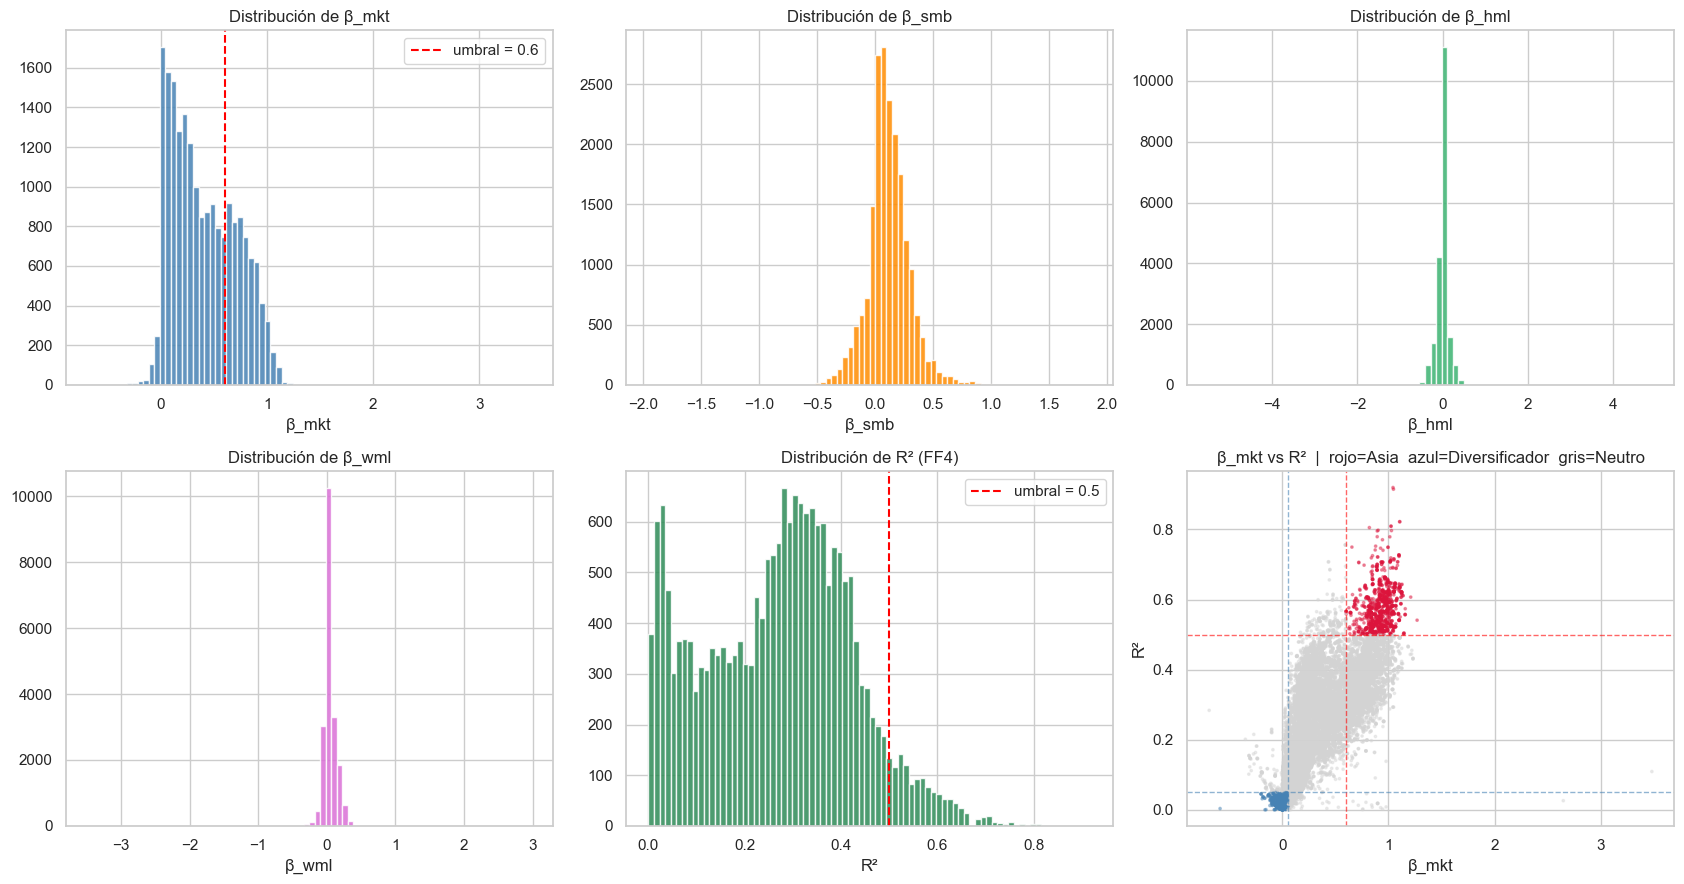

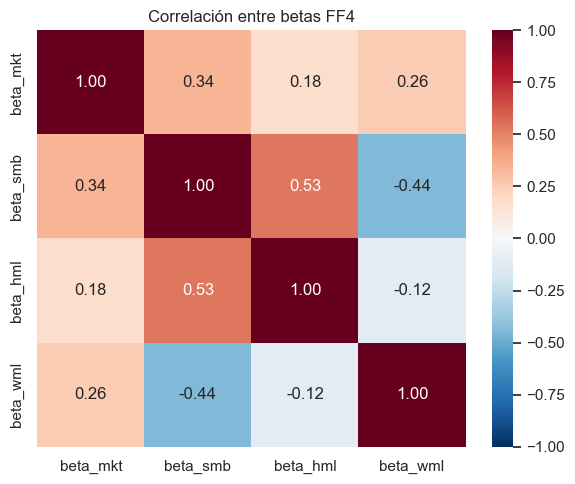

CHECK 2 – Fondos con n_obs < 252: 2  (todos reciben NaN en betas → asia_biased = 0)
Ningún fondo insuficiente clasificado como asia_biased.

── Fondos seleccionados (guardados en: data\daily_universe\fondos_seleccionados.parquet ) ──
  asia_biased        : 1,022
  diversified_biased : 1,750
  TOTAL seleccionados: 2,772
  Neutros descartados: 17,110


In [24]:
# =============================================================================
# 5.3 – VALIDACIÓN VISUAL Y CHECKS (FF4)
# =============================================================================

valid = ols_by_fund.dropna(subset=["beta_mkt"])

# ── CHECK 1: Distribuciones de las 4 betas + R² ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# Fila 1: β_mkt, β_smb, β_hml
for ax, col, color, label in zip(
    axes[0],
    ["beta_mkt", "beta_smb", "beta_hml"],
    ["steelblue", "darkorange", "mediumseagreen"],
    ["β_mkt", "β_smb", "β_hml"],
):
    ax.hist(valid[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.85)
    if col == "beta_mkt":
        ax.axvline(UMBRAL_BETA_MKT, color="red", ls="--", lw=1.5,
                   label=f"umbral = {UMBRAL_BETA_MKT}")
        ax.legend()
    ax.set_title(f"Distribución de {label}")
    ax.set_xlabel(label)

# Fila 2: β_wml, R², scatter β_mkt vs R²
axes[1][0].hist(valid["beta_wml"].dropna(), bins=80, color="orchid", edgecolor="white", alpha=0.85)
axes[1][0].set_title("Distribución de β_wml")
axes[1][0].set_xlabel("β_wml")

axes[1][1].hist(valid["r2"].dropna(), bins=80, color="seagreen", edgecolor="white", alpha=0.85)
axes[1][1].axvline(UMBRAL_R2, color="red", ls="--", lw=1.5, label=f"umbral = {UMBRAL_R2}")
axes[1][1].set_title("Distribución de R² (FF4)")
axes[1][1].set_xlabel("R²")
axes[1][1].legend()

def classify_color(row):
    if   row["asia_biased"]        == 1: return "crimson"
    elif row["diversified_biased"] == 1: return "steelblue"
    else:                               return "lightgrey"
colors = valid.apply(classify_color, axis=1)
axes[1][2].scatter(valid["beta_mkt"], valid["r2"], c=colors, s=3, alpha=0.4)
axes[1][2].axvline(UMBRAL_BETA_MKT, color="red",       ls="--", lw=1, alpha=0.6)
axes[1][2].axvline(UMBRAL_BETA_LOW, color="steelblue",  ls="--", lw=1, alpha=0.6)
axes[1][2].axhline(UMBRAL_R2,       color="red",        ls="--", lw=1, alpha=0.6)
axes[1][2].axhline(UMBRAL_R2_LOW,   color="steelblue",  ls="--", lw=1, alpha=0.6)
axes[1][2].set_xlabel("β_mkt")
axes[1][2].set_ylabel("R²")
axes[1][2].set_title("β_mkt vs R²  |  rojo=Asia  azul=Diversificador  gris=Neutro")

plt.tight_layout()
plt.show()

# ── CHECK 1b: Heatmap de correlación entre betas ────────────────────────────
beta_cols = ["beta_mkt", "beta_smb", "beta_hml", "beta_wml"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(valid[beta_cols].corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre betas FF4")
plt.tight_layout()
plt.show()

# ── CHECK 2: Fondos insuficientes (n < MIN_OBS) ─────────────────────────────
insuf = ols_by_fund.loc[ols_by_fund["n_obs"] < MIN_OBS]
print(f"CHECK 2 – Fondos con n_obs < {MIN_OBS}: {len(insuf):,}  "
      f"(todos reciben NaN en betas → asia_biased = 0)")
assert (insuf["asia_biased"] == 0).all(), \
    " Hay fondos con pocas obs clasificados como asia_biased"
print("Ningún fondo insuficiente clasificado como asia_biased.\n")

# ── GUARDADO: fondos seleccionados (asia_biased + diversified_biased) ────────
PARQUET_PATH = os.path.join("data", "daily_universe", "fondos_seleccionados.parquet")
os.makedirs(os.path.dirname(PARQUET_PATH), exist_ok=True)

# Se eliminan los fondos "neutros" (ni sesgados a Asia ni diversificadores puros)
# para conservar únicamente los casos con clasificación inequívoca.
# Este subconjunto se persiste en Parquet para garantizar reproducibilidad
# en etapas posteriores (feature engineering, entrenamiento ML): cualquier
# notebook que lo consuma parte exactamente del mismo universo de fondos,
# sin depender de que los umbrales estén redefinidos en memoria.
fondos_seleccionados = ols_by_fund[
    (ols_by_fund["asia_biased"] == 1) | (ols_by_fund["diversified_biased"] == 1)
].copy()

fondos_seleccionados.to_parquet(PARQUET_PATH, index=False)

n_asia_sel   = fondos_seleccionados["asia_biased"].sum()
n_divers_sel = fondos_seleccionados["diversified_biased"].sum()
print("── Fondos seleccionados (guardados en:", PARQUET_PATH, ") ──")
print(f"  asia_biased        : {n_asia_sel:,}")
print(f"  diversified_biased : {n_divers_sel:,}")
print(f"  TOTAL seleccionados: {len(fondos_seleccionados):,}")
print(f"  Neutros descartados: {len(ols_by_fund) - len(fondos_seleccionados):,}")

### 5.4 – Ajuste de coeficientes por significancia estadistica (t-value shrinkage)

**Problema.** La regresion OLS de 5.3 produce estimaciones puntuales de alpha y betas para
cada fondo. Sin embargo, no todos los coeficientes son igual de fiables: un fondo con
beta_mkt = 0.80 y t = 12.3 es muy distinto de otro con beta_mkt = 0.82 y t = 1.1.
Usar ambos sin distincion inyecta ruido al modelo supervisado posterior.

**Solucion: shrinkage hacia cero proporcional a la incertidumbre.**
Se define un peso w en [0, 1] que depende del |t|-value del coeficiente y de un umbral
t0 (tuneable). Cuando |t| es bajo, w se acerca a 0 y el coeficiente se encoge hacia cero;
cuando |t| >> t0, w se acerca a 1 y el coeficiente se mantiene intacto.

$$\text{coef\_adj} = \text{coef} \times w(|t|)$$

**Dos funciones de peso implementadas:**

| Metodo | Formula | Comportamiento |
|--------|---------|----------------|
| `linear` | w = min(1, \|t\| / t0) | Lineal hasta t0, luego constante en 1. Simple, interpretable. Discontinuidad en la derivada en t0. |
| `tanh` | w = tanh(\|t\| / t0) | Suave en todo el dominio. Asintotico a 1. Penaliza algo mas los valores intermedios que el lineal. |

**Justificacion financiera:**
- Es equivalente en espiritu al *shrinkage* bayesiano de Vasicek (1973) para betas CAPM,
  donde las estimaciones con alta varianza se encogen hacia un prior (aqui, cero).
- Evita que fondos con pocas observaciones o alta varianza residual contaminen las features.
- El parametro t0 controla la agresividad: t0 = 2.0 (default) corresponde aproximadamente
  al umbral clasico de significancia al 5% bilateral.

**Coeficientes ajustados:**
- `alpha_adj`, `beta_mkt_adj`, `beta_smb_adj`, `beta_hml_adj`, `beta_wml_adj`
- Los originales se conservan intactos en `ols_by_fund`.

In [25]:
# =============================================================================
# 5.4 -- Ajuste de coeficientes por significancia (t-value shrinkage)
# =============================================================================

# -- Parametro tuneable -------------------------------------------------------
T0     = 2.0        # umbral de t-value (~significancia 5% bilateral)
METHOD = "tanh"     # "linear" o "tanh"  (elegido por defecto: tanh)

# -- Funciones de peso --------------------------------------------------------
def w_linear(t_abs, t0=T0):
    """Peso piecewise-lineal: w = min(1, |t|/t0)."""
    return np.minimum(1.0, t_abs / t0)

def w_tanh(t_abs, t0=T0):
    """Peso suave: w = tanh(|t|/t0)."""
    return np.tanh(t_abs / t0)

weight_funcs = {"linear": w_linear, "tanh": w_tanh}

# -- Pares (coeficiente, t-value) a ajustar -----------------------------------
coef_t_pairs = [
    ("alpha",    "t_alpha"),
    ("beta_mkt", "t_mkt"),
    ("beta_smb", "t_smb"),
    ("beta_hml", "t_hml"),
    ("beta_wml", "t_wml"),
]

# -- Aplicar ambos metodos (para comparacion) ---------------------------------
for method_name, wfunc in weight_funcs.items():
    suffix = f"_{method_name}"
    for coef_col, t_col in coef_t_pairs:
        t_abs = ols_by_fund[t_col].abs()
        w = wfunc(t_abs)
        ols_by_fund[f"{coef_col}_adj{suffix}"] = ols_by_fund[coef_col] * w

# -- Elegir metodo por defecto y crear columnas _adj sin sufijo ---------------
print(f"Metodo elegido: '{METHOD}'  |  t0 = {T0}")
chosen_suffix = f"_{METHOD}"
for coef_col, _ in coef_t_pairs:
    ols_by_fund[f"{coef_col}_adj"] = ols_by_fund[f"{coef_col}_adj{chosen_suffix}"]

# -- Tabla comparativa: original vs ajustado (ambos metodos) ------------------
rows = []
for coef_col, t_col in coef_t_pairs:
    orig = ols_by_fund[coef_col]
    adj_lin = ols_by_fund[f"{coef_col}_adj_linear"]
    adj_tan = ols_by_fund[f"{coef_col}_adj_tanh"]
    rows.append({
        "coeficiente": coef_col,
        "orig_median":    orig.median(),
        "orig_std":       orig.std(),
        "linear_median":  adj_lin.median(),
        "linear_std":     adj_lin.std(),
        "tanh_median":    adj_tan.median(),
        "tanh_std":       adj_tan.std(),
        "pct_shrunk_linear": (adj_lin.abs() < orig.abs()).mean() * 100,
        "pct_shrunk_tanh":   (adj_tan.abs() < orig.abs()).mean() * 100,
    })

comparison = pd.DataFrame(rows)

print("\n" + "=" * 90)
print("5.4 -- COMPARACION ORIGINAL vs AJUSTADO (t-value shrinkage, t0 = {:.1f})".format(T0))
print("=" * 90)
display(comparison.round(6))

# -- Resumen rapido -----------------------------------------------------------
n_total = len(ols_by_fund)
n_valid = ols_by_fund["beta_mkt"].notna().sum()
bmkt_orig_med = ols_by_fund["beta_mkt"].median()
bmkt_adj_med  = ols_by_fund["beta_mkt_adj"].median()
alpha_orig_med = ols_by_fund["alpha"].median()
alpha_adj_med  = ols_by_fund["alpha_adj"].median()

print(f"\nbeta_mkt  -->  original mediana: {bmkt_orig_med:.4f}  |  "
      f"ajustado ({METHOD}) mediana: {bmkt_adj_med:.4f}")
print(f"alpha     -->  original mediana: {alpha_orig_med:.6f}  |  "
      f"ajustado ({METHOD}) mediana: {alpha_adj_med:.6f}")
print(f"Fondos con |beta_mkt_adj| < |beta_mkt|: "
      f"{(ols_by_fund['beta_mkt_adj'].abs() < ols_by_fund['beta_mkt'].abs()).sum():,} "
      f"/ {n_valid:,}")
print("=" * 90)

Metodo elegido: 'tanh'  |  t0 = 2.0

5.4 -- COMPARACION ORIGINAL vs AJUSTADO (t-value shrinkage, t0 = 2.0)


,coeficiente,orig_median,orig_std,linear_median,linear_std,tanh_median,tanh_std,pct_shrunk_linear,pct_shrunk_tanh
0,alpha,0.000030,0.000189,0.000004,0.000125,0.000004,0.000107,91.751333,99.728398
1,beta_mkt,0.340721,0.304341,0.340612,0.304275,0.340241,0.304121,3.762197,98.576602
2,beta_smb,0.106043,0.180223,0.103038,0.177612,0.095397,0.173391,26.717634,99.989941
3,beta_hml,0.002756,0.140908,0.000435,0.138351,0.000430,0.131156,57.247762,99.989941
4,beta_wml,0.022927,0.097895,0.014893,0.096389,0.012919,0.090784,54.280253,99.989941



beta_mkt  -->  original mediana: 0.3407  |  ajustado (tanh) mediana: 0.3402
alpha     -->  original mediana: 0.000030  |  ajustado (tanh) mediana: 0.000004
Fondos con |beta_mkt_adj| < |beta_mkt|: 19,599 / 19,880


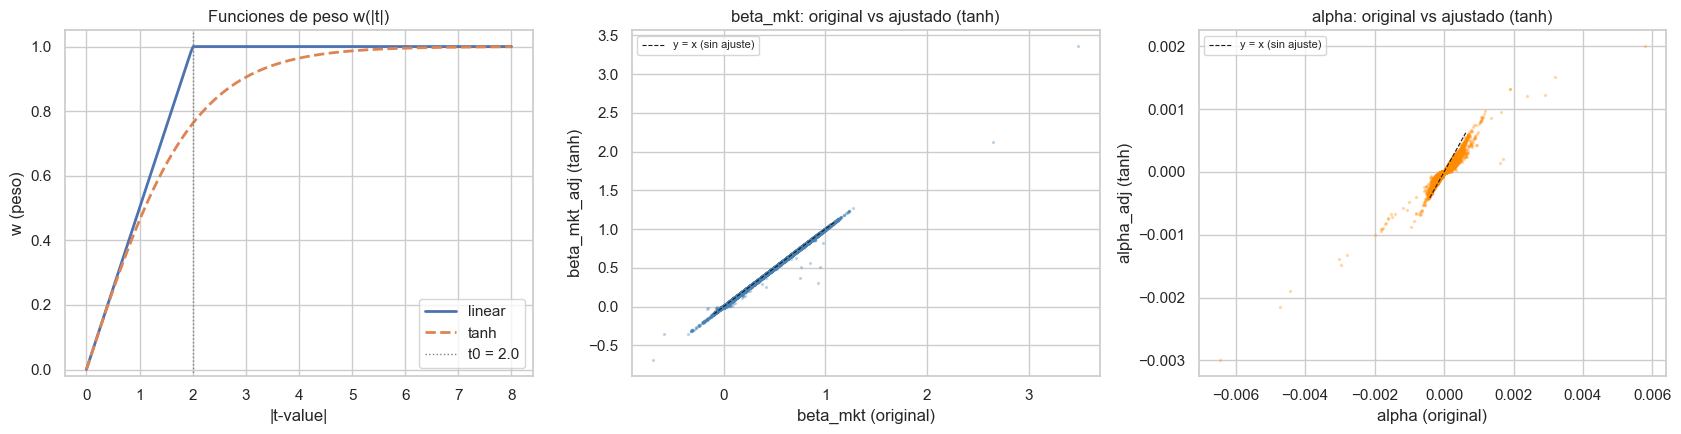

In [26]:
# =============================================================================
# 5.4 -- Visualizacion: curvas de peso + scatter original vs ajustado
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# -- Panel 1: curvas de peso w(|t|) para ambos metodos -----------------------
t_grid = np.linspace(0, 8, 200)
axes[0].plot(t_grid, w_linear(t_grid, T0), label="linear", lw=2)
axes[0].plot(t_grid, w_tanh(t_grid, T0), label="tanh", lw=2, ls="--")
axes[0].axvline(T0, color="grey", ls=":", lw=1, label=f"t0 = {T0}")
axes[0].set_xlabel("|t-value|")
axes[0].set_ylabel("w (peso)")
axes[0].set_title("Funciones de peso w(|t|)")
axes[0].legend()
axes[0].set_ylim(-0.02, 1.05)

# -- Panel 2: scatter beta_mkt original vs ajustado (metodo elegido) ----------
v = ols_by_fund.dropna(subset=["beta_mkt", "beta_mkt_adj"])
axes[1].scatter(v["beta_mkt"], v["beta_mkt_adj"], s=2, alpha=0.25, color="steelblue")
lims = [v["beta_mkt"].quantile(0.005), v["beta_mkt"].quantile(0.995)]
axes[1].plot(lims, lims, "k--", lw=0.8, label="y = x (sin ajuste)")
axes[1].set_xlabel("beta_mkt (original)")
axes[1].set_ylabel(f"beta_mkt_adj ({METHOD})")
axes[1].set_title(f"beta_mkt: original vs ajustado ({METHOD})")
axes[1].legend(fontsize=8)

# -- Panel 3: scatter alpha original vs ajustado ------------------------------
axes[2].scatter(v["alpha"], v["alpha_adj"], s=2, alpha=0.25, color="darkorange")
lims_a = [v["alpha"].quantile(0.005), v["alpha"].quantile(0.995)]
axes[2].plot(lims_a, lims_a, "k--", lw=0.8, label="y = x (sin ajuste)")
axes[2].set_xlabel("alpha (original)")
axes[2].set_ylabel(f"alpha_adj ({METHOD})")
axes[2].set_title(f"alpha: original vs ajustado ({METHOD})")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 5.5 – Feature engineering diario (ventanas 1y / 3y / 5y)

> **Universo restringido:** los cálculos de esta sección se realizan **únicamente sobre los fondos
> seleccionados en 5.3** (`asia_biased = 1` o `diversified_biased = 1`), cargados desde
> `data/daily/universe/fondos_seleccionados.parquet`. Los fondos neutros (sin clasificación
> inequívoca) quedan excluidos del pipeline de features. Esto reduce drásticamente la memoria
> y el tiempo de cómputo al evitar calcular rolling windows sobre ~19 000 fondos irrelevantes
> para el modelo.

A partir de `daily_returns` (sección 5.2) se calculan **6 familias de features rolling** 

---
Features calculadas

| # | Feature | Formula / logica | Que mide | Interpretacion |
|---|---------|-----------------|----------|----------------|
| 1 | `cum_active_ret` | sum(excess_ret - Mkt-RF) en ventana | Retorno activo acumulado vs mercado Asia | + = fondo bate al mercado; - = mercado lo bate |
| 2 | `volatility` | std(ret_1d, ddof=1) en ventana | Dispersion de retornos diarios | Mayor valor = fondo mas erratico |
| 3 | `upside_capture` | sum(excess_ret \| Mkt>0) / sum(Mkt-RF \| Mkt>0) | Participacion en subidas del mercado | >1 = captura mas que el mercado en dias buenos |
| 4 | `downside_capture` | sum(excess_ret \| Mkt<0) / sum(Mkt-RF \| Mkt<0) | Participacion en bajadas del mercado | <1 = protege mejor que el mercado en dias malos |
| 5 | `skewness` | rolling skew de ret_1d | Asimetria de la distribucion | Negativa = cola izquierda pesada (riesgo crash) |
| 6 | `kurtosis` | rolling kurt de ret_1d (Fisher, excess) | Peso de colas extremas | Alta = mas eventos extremos de lo normal |

---

 Ventanas

| Sufijo | Dias habiles | Equivalencia | min_periods (80%) |
|--------|-------------|--------------|---------------------|
| `_1y` | 252 | ~1 anno | 201 |
| `_3y` | 756 | ~3 annos | 604 |
| `_5y` | 1260 | ~5 annos | 1008 |

`min_periods` = 80% de la ventana (configurable via `MIN_PCT`). Permite calcular features para fondos con historial parcial sin comprometer la robustez estadistica.

---

Decisiones de diseno

| Decision | Justificacion |
|----------|---------------|
| Benchmark = Mkt-RF (no RF) | La tesis es "fondos que batan al mercado asiatico". El retorno activo mide valor anadido sobre el mercado, no sobre el cash. |
| min_periods = 80% | Equilibrio entre cobertura (no descartar fondos jovenes) y robustez (ventana suficientemente llena). |
| Skewness y kurtosis | Capturan momentos superiores de la distribucion. Un modelo que solo ve media y varianza ignora riesgo de cola y asimetria. |
| Formato ancho para rolling | Los rolling en formato ancho (date x fund) son vectorizados por columna, mucho mas eficientes que groupby+apply en formato largo. |
| Limpieza de inf en captures | Division por cero cuando sum(Mkt-RF) en dias up/down = 0 produce inf. Se reemplaza explicitamente por NaN. |

In [27]:
# =============================================================================
# 5.5 -- Feature engineering diario (ventanas 1y / 3y / 5y)
# =============================================================================

# ── 0. Configuracion de ventanas ─────────────────────────────────────────────
MIN_PCT = 0.80  # porcentaje minimo de observaciones en la ventana

WINDOWS = {
    "1y": {"days": 252,  "min_pct": MIN_PCT},
    "3y": {"days": 756,  "min_pct": MIN_PCT},
    "5y": {"days": 1260, "min_pct": MIN_PCT},
}
for k, v in WINDOWS.items():
    v["min_periods"] = int(v["days"] * v["min_pct"])

print("Configuracion de ventanas:")
for k, v in WINDOWS.items():
    print(f"  {k}: W={v['days']}  min_periods={v['min_periods']}  ({v['min_pct']*100:.0f}%)")

#── 0b. Restringir al universo seleccionado ───────────────────────────────────
# Se opera solo sobre los fondos clasificados en 5.3 (asia_biased + diversified_biased).
# Esto reduce memoria y tiempo de cómputo al descartar fondos neutros irrelevantes.
selected_fund_ids = fondos_seleccionados["fund_id"].unique()
daily_returns_sel = daily_returns[daily_returns["fund_id"].isin(selected_fund_ids)].copy()

print(f"\nUniverso restringido a fondos seleccionados:")
print(f"  Total fondos en daily_returns     : {daily_returns['fund_id'].nunique():,}")
print(f"  Fondos seleccionados (5.3)        : {daily_returns_sel['fund_id'].nunique():,}")
print(f"  Fondos descartados (neutros)      : {daily_returns['fund_id'].nunique() - daily_returns_sel['fund_id'].nunique():,}")

# ── 1. Pivotar daily_returns_sel a formato ancho ──────────────────────────────
print("\nPivotando a formato ancho (date x fund)...")
ret_wide = daily_returns_sel.pivot_table(
    index="date", columns="fund_id", values="ret_1d", aggfunc="last"
).sort_index()

excess_wide = daily_returns_sel.pivot_table(
    index="date", columns="fund_id", values="excess_ret", aggfunc="last"
).sort_index()

# Mkt-RF como Serie por fecha (igual para todos los fondos)
mkt_rf = daily_returns_sel.drop_duplicates("date").set_index("date")["Mkt-RF"].sort_index()

print(f"  ret_wide    : {ret_wide.shape[0]} fechas x {ret_wide.shape[1]} fondos")
print(f"  excess_wide : {excess_wide.shape[0]} fechas x {excess_wide.shape[1]} fondos")
print(f"  mkt_rf      : {len(mkt_rf)} fechas")

# ── 2. Funciones modulares por tipo de feature ───────────────────────────────

def rolling_cum_active_return(excess_w, mkt, W, MP):
    """Retorno activo acumulado: sum(excess_ret - Mkt-RF) en ventana."""
    active = excess_w.sub(mkt, axis=0)
    return active.rolling(W, min_periods=MP).sum()


def rolling_volatility(ret_w, W, MP):
    """Volatilidad: std(ret_1d, ddof=1) en ventana."""
    return ret_w.rolling(W, min_periods=MP).std(ddof=1)


def rolling_capture(excess_w, mkt, W, MP, direction="up"):
    """
    Upside/Downside Capture ratio en ventana rolling.
    direction="up"  : dias donde Mkt-RF > 0
    direction="down": dias donde Mkt-RF < 0

    Los dias que NO cumplen la condicion se ponen a 0 para no contaminar
    el ratio. Los dias sin dato del fondo (NaN) se conservan como NaN:
    no cuentan en la suma ni en min_periods, generando NaN en el warmup
    period de forma coherente con el resto de features rolling.
    """
    if direction == "up":
        mask = mkt > 0
    else:
        mask = mkt < 0

    # Mkt-RF enmascarado: 0 en dias que no cumplen la condicion
    mkt_masked = mkt.where(mask, 0.0)

    # Broadcast mask a forma 2D:
    # - dias condicion cumplida:  fondo con dato → valor; fondo sin dato → NaN
    # - dias condicion NO cumplida: todos → 0.0 (no participan en el ratio)
    # SIN fillna: NaN del fondo permanece NaN → excluido del rolling sum
    excess_masked = excess_w.mul(mask.astype(float), axis=0)

    sum_excess = excess_masked.rolling(W, min_periods=MP).sum()
    sum_mkt    = mkt_masked.rolling(W, min_periods=MP).sum()

    # Proteger contra division por cero
    capture = sum_excess.div(sum_mkt, axis=0)
    capture = capture.replace([np.inf, -np.inf], np.nan)
    return capture


def rolling_skewness(ret_w, W, MP):
    """Skewness rolling de ret_1d."""
    return ret_w.rolling(W, min_periods=MP).skew()


def rolling_kurtosis(ret_w, W, MP):
    """Kurtosis rolling de ret_1d (Fisher excess kurtosis)."""
    return ret_w.rolling(W, min_periods=MP).kurt()


# ── 3. Funcion auxiliar para stack a formato largo ───────────────────────────
def _stack_wide(wide_df, feat_name):
    """Convierte DataFrame ancho a Series con nombre feat_name (formato largo)."""
    s = wide_df.stack(future_stack=True)
    s.name = feat_name
    return s

# ── 4. Loop principal: calcular features por ventana ─────────────────────────
all_features = {}  # dict de {nombre_col: Series indexada por (date, fund_id)}
t_start_global = _time.time()

for win_label, win_cfg in WINDOWS.items():
    W = win_cfg["days"]
    MP = win_cfg["min_periods"]
    t_win_start = _time.time()
    print(f"\n{'='*70}")
    print(f"Ventana {win_label}: W={W}, MP={MP}")
    print(f"{'='*70}")

    # 4.1 Retorno activo acumulado
    print(f"  [1/6] cum_active_ret_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_cum_active_return(excess_wide, mkt_rf, W, MP)
    all_features[f"cum_active_ret_{win_label}"] = _stack_wide(_feat, f"cum_active_ret_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    # 4.2 Volatilidad
    print(f"  [2/6] volatility_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_volatility(ret_wide, W, MP)
    all_features[f"volatility_{win_label}"] = _stack_wide(_feat, f"volatility_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    # 4.3 Upside Capture
    print(f"  [3/6] upside_capture_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_capture(excess_wide, mkt_rf, W, MP, direction="up")
    all_features[f"upside_capture_{win_label}"] = _stack_wide(_feat, f"upside_capture_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    # 4.4 Downside Capture
    print(f"  [4/6] downside_capture_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_capture(excess_wide, mkt_rf, W, MP, direction="down")
    all_features[f"downside_capture_{win_label}"] = _stack_wide(_feat, f"downside_capture_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    # 4.5 Skewness
    print(f"  [5/6] skewness_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_skewness(ret_wide, W, MP)
    all_features[f"skewness_{win_label}"] = _stack_wide(_feat, f"skewness_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    # 4.6 Kurtosis
    print(f"  [6/6] kurtosis_{win_label} ...", end=" ", flush=True)
    t0 = _time.time()
    _feat = rolling_kurtosis(ret_wide, W, MP)
    all_features[f"kurtosis_{win_label}"] = _stack_wide(_feat, f"kurtosis_{win_label}")
    del _feat
    print(f"({_time.time()-t0:.1f}s)")

    elapsed_win = _time.time() - t_win_start
    print(f"  --- Ventana {win_label} completada en {elapsed_win:.1f}s ---")

elapsed_total = _time.time() - t_start_global
print(f"\nTiempo total de calculo de features: {elapsed_total/60:.1f} min")

# ── 5. Ensamblar DataFrame largo ─────────────────────────────────────────────
print("\nEnsamblando DataFrame features_5_5 ...")

features_5_5 = pd.DataFrame(all_features)
features_5_5.index.names = ["date", "fund_id"]
features_5_5 = features_5_5.reset_index()

# Liberar memoria del dict intermedio
del all_features

# Eliminar filas donde TODAS las 21 features son NaN
feat_cols = [c for c in features_5_5.columns if c not in ("date", "fund_id")]
mask_all_nan = features_5_5[feat_cols].isna().all(axis=1)
n_before = len(features_5_5)
features_5_5 = features_5_5.loc[~mask_all_nan].reset_index(drop=True)
n_after = len(features_5_5)

# Liberar pivots de memoria
del ret_wide, excess_wide

# ── 6. Resumen ───────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5.5 -- FEATURE ENGINEERING DIARIO (RESUMEN)")
print("=" * 70)
print(f"Filas antes de filtrar all-NaN  : {n_before:,}")
print(f"Filas eliminadas (all-NaN)      : {n_before - n_after:,}")
print(f"Filas finales en features_5_5   : {n_after:,}")
print(f"Fondos unicos                   : {features_5_5['fund_id'].nunique():,}")
print(f"Fechas unicas                   : {features_5_5['date'].nunique():,}")
print(f"Rango: {features_5_5['date'].min().date()} -> {features_5_5['date'].max().date()}")
print(f"Columnas de features ({len(feat_cols)}): {feat_cols}")
print("=" * 70)

features_5_5.head(10)

Configuracion de ventanas:
  1y: W=252  min_periods=201  (80%)
  3y: W=756  min_periods=604  (80%)
  5y: W=1260  min_periods=1008  (80%)

Universo restringido a fondos seleccionados:
  Total fondos en daily_returns     : 19,882
  Fondos seleccionados (5.3)        : 2,772
  Fondos descartados (neutros)      : 17,110

Pivotando a formato ancho (date x fund)...
  ret_wide    : 1443 fechas x 2772 fondos
  excess_wide : 1443 fechas x 2772 fondos
  mkt_rf      : 1443 fechas

Ventana 1y: W=252, MP=201
  [1/6] cum_active_ret_1y ... (1.4s)
  [2/6] volatility_1y ... (1.2s)
  [3/6] upside_capture_1y ... (1.1s)
  [4/6] downside_capture_1y ... (1.0s)
  [5/6] skewness_1y ... (1.0s)
  [6/6] kurtosis_1y ... (2.7s)
  --- Ventana 1y completada en 8.5s ---

Ventana 3y: W=756, MP=604
  [1/6] cum_active_ret_3y ... (0.9s)
  [2/6] volatility_3y ... (1.0s)
  [3/6] upside_capture_3y ... (1.0s)
  [4/6] downside_capture_3y ... (1.0s)
  [5/6] skewness_3y ... (1.0s)
  [6/6] kurtosis_3y ... (1.1s)
  --- Ventana 3y 

,date,fund_id,cum_active_ret_1y,volatility_1y,upside_capture_1y,downside_capture_1y,skewness_1y,kurtosis_1y,cum_active_ret_3y,volatility_3y,upside_capture_3y,downside_capture_3y,skewness_3y,kurtosis_3y,cum_active_ret_5y,volatility_5y,upside_capture_5y,downside_capture_5y,skewness_5y,kurtosis_5y
0,2016-10-12,50,0.098879,0.010111,0.982179,0.820959,-0.409145,1.477429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10-12,51,-0.106350,0.001538,0.059113,0.044301,-0.029541,0.026317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-10-12,58,-0.143579,0.009929,0.211758,0.286258,-0.053837,0.418837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-10-12,91,-0.124790,0.000014,-0.001452,0.001278,-0.193210,-0.064216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-10-12,148,-0.005306,0.011714,0.333817,0.211680,-0.252829,0.852833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016-10-12,164,-0.018782,0.011343,0.814983,0.808673,0.216405,3.306390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2016-10-12,166,-0.084696,0.001696,0.037049,-0.016629,0.162930,0.373920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2016-10-12,235,-0.045418,0.009524,0.842099,0.883592,-0.255254,0.917595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-10-12,246,0.027937,0.009916,0.929179,0.870731,0.003063,0.131005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016-10-12,327,-0.145531,0.002138,-0.077158,-0.056184,-0.248995,2.709206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# =============================================================================
# 5.5 -- CHECKS DE VALIDACION
# =============================================================================

feat_cols = [c for c in features_5_5.columns if c not in ("date", "fund_id")]

# ── CHECK 1: % NaN por feature ───────────────────────────────────────────────
print("CHECK 1 -- % NaN por feature")
print("-" * 60)
nan_info = []
for col in feat_cols:
    n_nan = features_5_5[col].isna().sum()
    n_valid = features_5_5[col].notna().sum()
    pct_nan = 100 * n_nan / len(features_5_5)
    nan_info.append({"feature": col, "n_valid": n_valid, "n_nan": n_nan, "pct_nan": pct_nan})
nan_df = pd.DataFrame(nan_info)
display(nan_df.style.format({"pct_nan": "{:.2f}%", "n_valid": "{:,.0f}", "n_nan": "{:,.0f}"}))

# ── CHECK 2: % NaN medio por ventana ─────────────────────────────────────────
print("\nCHECK 2 -- % NaN medio agrupado por ventana")
print("-" * 60)
for suffix in ["_1y", "_3y", "_5y"]:
    cols_win = [c for c in feat_cols if c.endswith(suffix)]
    mean_pct = features_5_5[cols_win].isna().mean().mean() * 100
    print(f"  Ventana {suffix}: {mean_pct:.2f}% NaN medio ({len(cols_win)} features)")

# ── CHECK 3: Distribucion de NaN por fondo ───────────────────────────────────
print("\nCHECK 3 -- Distribucion del % de filas con algun NaN, por fondo")
print("-" * 60)
pct_nan_by_fund = (
    features_5_5
    .groupby("fund_id")[feat_cols]
    .apply(lambda g: g.isna().any(axis=1).mean() * 100)
)
print(pct_nan_by_fund.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).to_string())

# ── CHECK 4: Estadisticas descriptivas de las 18 features ────────────────────
print("\nCHECK 4 -- Estadisticas descriptivas (percentiles 5/25/50/75/95)")
print("-" * 60)
desc = features_5_5[feat_cols].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T
display(desc)

# ── CHECK 5: Look-ahead sanity check ─────────────────────────────────────────
print("\nCHECK 5 -- Primera fecha con datos validos por ventana (look-ahead check)")
print("-" * 60)
panel_start = features_5_5["date"].min()
print(f"Inicio del panel (features_5_5): {panel_start.date()}")
for suffix, win_cfg in WINDOWS.items():
    cols_win = [c for c in feat_cols if c.endswith(f"_{suffix}")]
    # Primera fecha donde al menos un fondo tiene valor no-NaN en alguna feature de esta ventana
    first_valid_mask = features_5_5[cols_win].notna().any(axis=1)
    if first_valid_mask.any():
        first_date = features_5_5.loc[first_valid_mask, "date"].min()
        delta_days = (first_date - panel_start).days
        expected_min = win_cfg["min_periods"]
        print(f"  Ventana {suffix} (W={win_cfg['days']}, MP={win_cfg['min_periods']}): "
              f"primera fecha valida = {first_date.date()} "
              f"(delta = {delta_days} dias calendario desde inicio)")
        # Sanity: delta debe ser al menos ~ min_periods dias habiles (~70% de calendario)
        if delta_days < expected_min * 0.65:
            print(f"    *** ALERTA: delta sospechosamente bajo ({delta_days} < {expected_min*0.65:.0f}). "
                  f"Posible look-ahead.")
        else:
            print(f"    OK: coherente con min_periods={expected_min}")
    else:
        print(f"  Ventana {suffix}: SIN datos validos")

print("\nTodos los checks de 5.5 completados correctamente.")

CHECK 1 -- % NaN por feature
------------------------------------------------------------


,feature,n_valid,n_nan,pct_nan
0,cum_active_ret_1y,"3,088,119",0,0.00%
1,volatility_1y,"3,088,119",0,0.00%
2,upside_capture_1y,"3,088,119",0,0.00%
3,downside_capture_1y,"3,088,119",0,0.00%
4,skewness_1y,"3,088,077",42,0.00%
5,kurtosis_1y,"3,088,077",42,0.00%
6,cum_active_ret_3y,"1,983,116","1,105,003",35.78%
7,volatility_3y,"1,983,116","1,105,003",35.78%
8,upside_capture_3y,"1,983,116","1,105,003",35.78%
9,downside_capture_3y,"1,983,116","1,105,003",35.78%



CHECK 2 -- % NaN medio agrupado por ventana
------------------------------------------------------------
  Ventana _1y: 0.00% NaN medio (6 features)
  Ventana _3y: 35.78% NaN medio (6 features)
  Ventana _5y: 68.68% NaN medio (6 features)

CHECK 3 -- Distribucion del % de filas con algun NaN, por fondo
------------------------------------------------------------
count    2772.000000
mean       71.692810
std        13.147213
min        64.923572
5%         64.923572
25%        64.923572
50%        64.923572
75%        64.975845
95%       100.000000
max       100.000000

CHECK 4 -- Estadisticas descriptivas (percentiles 5/25/50/75/95)
------------------------------------------------------------


,count,mean,std,min,5%,25%,50%,75%,95%,max
cum_active_ret_1y,3088119.0,-0.047551,0.158006,-9.417825,-0.316268,-0.123179,-0.031562,0.039625,0.150609,2.827233
volatility_1y,3088119.0,0.005106,0.006562,0.000000,0.000048,0.001583,0.003565,0.007664,0.014982,0.580851
upside_capture_1y,3088119.0,0.278949,0.420352,-9.248089,-0.086524,-0.017360,0.015348,0.729889,0.984136,1.641967
downside_capture_1y,3088119.0,0.271767,0.397756,-3.688349,-0.100131,-0.010969,0.023913,0.695254,0.960263,5.216978
skewness_1y,3088077.0,-0.704122,1.771825,-15.874508,-2.673305,-0.938169,-0.383022,-0.045027,0.634067,15.874508
kurtosis_1y,3088077.0,8.106772,23.185028,-3.000000,0.271226,1.114629,2.208393,6.410856,27.271481,252.000000
cum_active_ret_3y,1983116.0,-0.096922,0.188052,-9.277494,-0.318740,-0.215400,-0.094940,0.019440,0.150055,2.751211
volatility_3y,1983116.0,0.004888,0.005480,0.000000,0.000053,0.001632,0.003181,0.008033,0.011969,0.335411
upside_capture_3y,1983116.0,0.271002,0.409322,-2.861172,-0.073829,-0.015203,0.005154,0.723377,0.975742,1.472986
downside_capture_3y,1983116.0,0.272651,0.397649,-1.054673,-0.072839,-0.012103,0.014845,0.730015,0.946777,1.674020



CHECK 5 -- Primera fecha con datos validos por ventana (look-ahead check)
------------------------------------------------------------
Inicio del panel (features_5_5): 2016-10-12
  Ventana 1y (W=252, MP=201): primera fecha valida = 2016-10-12 (delta = 0 dias calendario desde inicio)
    *** ALERTA: delta sospechosamente bajo (0 < 131). Posible look-ahead.
  Ventana 3y (W=756, MP=604): primera fecha valida = 2018-04-30 (delta = 565 dias calendario desde inicio)
    OK: coherente con min_periods=604
  Ventana 5y (W=1260, MP=1008): primera fecha valida = 2019-11-15 (delta = 1129 dias calendario desde inicio)
    OK: coherente con min_periods=1008

Todos los checks de 5.5 completados correctamente.


### 5.6 – Ensamblaje de la matriz final de features

Se unen las features estáticas de `ols_by_fund` (5.3 + 5.4) y las features dinámicas rolling
de `features_5_5` (5.5) en un único dataset en formato largo `(date × fund_id)`, restringido
al universo de fondos seleccionados (`asia_biased = 1` o `diversified_biased = 1`).

**Estructura del dataset final (44 features + 2 labels):**

| Columna | Origen | Tipo | Descripción |
|---|---|---|---|
| `date` | Panel | Identificador | Fecha de la observación (diaria, L–V) |
| `fund_id` | Panel | Identificador | Código del fondo |
| `excess_ret` | 5.2 | Input base | Retorno en exceso diario (ret_1d − RF) |
| `asia_biased` | 5.3 | **Label** | 1 = fondo puro sesgo Asia |
| `diversified_biased` | 5.3 | **Label** | 1 = fondo puro diversificador |
| `alpha` / `alpha_adj` | 5.3/5.4 | Feature estática | Alpha OLS raw y ajustado por significancia |
| `beta_mkt` / `beta_mkt_adj` | 5.3/5.4 | Feature estática | Sensibilidad mercado Asia (raw y shrunk) |
| `beta_smb` / `beta_smb_adj` | 5.3/5.4 | Feature estática | Sesgo tamaño (raw y shrunk) |
| `beta_hml` / `beta_hml_adj` | 5.3/5.4 | Feature estática | Sesgo valor (raw y shrunk) |
| `beta_wml` / `beta_wml_adj` | 5.3/5.4 | Feature estática | Sesgo momentum (raw y shrunk) |
| `p_alpha/mkt/smb/hml/wml` | 5.3 | Feature estática | P-values de los coeficientes OLS |
| `t_alpha/mkt/smb/hml/wml` | 5.3 | Feature estática | T-statistics de los coeficientes OLS |
| `r2`, `r2_adj`, `n_obs` | 5.3 | Feature estática | Calidad del modelo OLS |
| `cum_active_ret_1y/3y/5y` | 5.5 | Feature dinámica | Retorno activo acumulado |
| `volatility_1y/3y/5y` | 5.5 | Feature dinámica | Volatilidad rolling |
| `upside_capture_1y/3y/5y` | 5.5 | Feature dinámica | Participación en subidas del mercado |
| `downside_capture_1y/3y/5y` | 5.5 | Feature dinámica | Participación en bajadas del mercado |
| `skewness_1y/3y/5y` | 5.5 | Feature dinámica | Asimetría de retornos rolling |
| `kurtosis_1y/3y/5y` | 5.5 | Feature dinámica | Peso de colas extremas rolling |
| `t_active_ret_1y/3y/5y` | 5.6 | Feature dinámica | T-stat del retorno activo (Information Ratio) |

> **Nota sobre la dualidad raw/adj:** Se incluyen tanto las betas originales como las ajustadas
> por t-shrinkage porque ambas versiones aportan información complementaria para el modelo
> (la raw captura la magnitud bruta, la adj penaliza estimaciones poco fiables). La
> redundancia resultante se gestiona en fase 6 mediante **PCA** antes del entrenamiento.

> **Nota sobre t-stats dinámicos:** El `t_active_ret` rolling es el único t-stat natural
> para features dinámicas. Se calcula como `rolling_mean(active_ret) / (rolling_std / √MP)`,
> equivalente al Information Ratio estandarizado. Para el resto de features dinámicas
> (volatility, capture, skewness, kurtosis) el propio valor numérico ya es la señal; forzar
> p-values sobre ellos carecería de distribución de referencia válida.

**Decisiones de diseño:**
- Labels (`asia_biased`, `diversified_biased`) se incluyen en el parquet pero **fuera del bloque de features**, claramente separadas.
- Los factores de mercado (`Mkt-RF`, `SMB`, `HML`, `WML`) se excluyen: su información ya está capturada en las betas OLS.
- `ret_1d` se descarta (redundante con `excess_ret`).
- `dropna` aplicado sobre las **features de ventana 1y + betas estáticas** (`required_cols`); NaN en ventanas 3y/5y se conservan para imputación en fase 6.
- Guardado en `data/features/matriz_features_v1.parquet`.

In [29]:
# =============================================================================
# 5.6 – Ensamblaje de la matriz final de features
# ============================================================================

# ── 1. Columnas estáticas de ols_by_fund (raw + adj + pvals + tstats + calidad)
STATIC_RAW  = ["alpha", "beta_mkt", "beta_smb", "beta_hml", "beta_wml"]
STATIC_ADJ  = ["alpha_adj", "beta_mkt_adj", "beta_smb_adj", "beta_hml_adj", "beta_wml_adj"]
STATIC_PVAL = ["p_alpha", "p_mkt", "p_smb", "p_hml", "p_wml"]
STATIC_TSTAT= ["t_alpha", "t_mkt", "t_smb", "t_hml", "t_wml"]
STATIC_QUAL = ["r2", "r2_adj", "n_obs"]
LABELS      = ["asia_biased", "diversified_biased"]

ALL_STATIC  = STATIC_RAW + STATIC_ADJ + STATIC_PVAL + STATIC_TSTAT + STATIC_QUAL

static_df = ols_by_fund[
    ols_by_fund["fund_id"].isin(fondos_seleccionados["fund_id"])
][["fund_id"] + LABELS + ALL_STATIC].copy()

print(f"Fondos en static_df  : {static_df['fund_id'].nunique():,}")
print(f"Columnas estáticas   : {len(ALL_STATIC)}  ({len(STATIC_RAW)} raw + {len(STATIC_ADJ)} adj "
      f"+ {len(STATIC_PVAL)} pval + {len(STATIC_TSTAT)} tstat + {len(STATIC_QUAL)} calidad)")

# ── 2. Extraer excess_ret por (date, fund_id) ─────────────────────────────────
daily_sel = daily_returns[
    daily_returns["fund_id"].isin(fondos_seleccionados["fund_id"])
][["date", "fund_id", "excess_ret", "Mkt-RF"]].copy()

# ── 3. Calcular t_active_ret rolling (Information Ratio t-stat) ───────────────
# active_ret = excess_ret − Mkt-RF  (retorno activo diario vs mercado)
daily_sel["active_ret"] = daily_sel["excess_ret"] - daily_sel["Mkt-RF"]

active_wide = daily_sel.pivot_table(
    index="date", columns="fund_id", values="active_ret", aggfunc="last"
).sort_index()

print("\nCalculando t_active_ret rolling (Information Ratio t-stat)...")
t_active_feats = {}
for win_label, win_cfg in WINDOWS.items():
    W  = win_cfg["days"]
    MP = win_cfg["min_periods"]
    roll_mean = active_wide.rolling(W, min_periods=MP).mean()
    roll_std  = active_wide.rolling(W, min_periods=MP).std(ddof=1)
    t_stat    = roll_mean / (roll_std / np.sqrt(MP))
    t_stat    = t_stat.replace([np.inf, -np.inf], np.nan)
    # stack a formato largo
    stacked = (t_stat
               .stack(future_stack=True)
               .rename(f"t_active_ret_{win_label}")
               .reset_index())
    stacked.columns = ["date", "fund_id", f"t_active_ret_{win_label}"]
    t_active_feats[win_label] = stacked
    print(f"  t_active_ret_{win_label} calculado.")

# Unir los 3 t-stats dinámicos
t_active_df = t_active_feats["1y"]
for win_label in ["3y", "5y"]:
    t_active_df = t_active_df.merge(t_active_feats[win_label], on=["date", "fund_id"], how="outer")

del active_wide, t_active_feats

# ── 4. Merge principal ────────────────────────────────────────────────────────
# daily_sel → features_5_5 → t_active_df → static_df
base_df = daily_sel[["date", "fund_id", "excess_ret"]].copy()

features_long = (
    base_df
    .merge(features_5_5,  on=["date", "fund_id"], how="left")
    .merge(t_active_df,   on=["date", "fund_id"], how="left")
    .merge(static_df,     on="fund_id",            how="left")
)
print(f"\nFilas tras ensamblaje completo : {len(features_long):,}")

del t_active_df, base_df

# ── 5. Filtrado por NaN en features obligatorias ──────────────────────────────
REQUIRED_COLS = (
    ["excess_ret"]
    + STATIC_RAW + STATIC_ADJ + STATIC_QUAL
    + ["cum_active_ret_1y", "volatility_1y", "upside_capture_1y",
       "downside_capture_1y", "skewness_1y", "kurtosis_1y",
       "t_active_ret_1y"]
)
n_antes = len(features_long)
features_long = features_long.dropna(subset=REQUIRED_COLS).reset_index(drop=True)
n_despues = len(features_long)
print(f"Filas eliminadas (NaN en required_cols): {n_antes - n_despues:,}")
print(f"Filas finales                          : {n_despues:,}")

# ── 6. Orden de columnas ──────────────────────────────────────────────────────
id_cols      = ["date", "fund_id", "excess_ret"]
label_cols   = LABELS
dynamic_cols = (
    [c for c in features_5_5.columns if c not in ("date", "fund_id")]
    + ["t_active_ret_1y", "t_active_ret_3y", "t_active_ret_5y"]
)

features_long = features_long[id_cols + label_cols + ALL_STATIC + dynamic_cols]

# ── 7. Resumen ────────────────────────────────────────────────────────────────
feat_cols = ALL_STATIC + dynamic_cols
print("\n" + "=" * 70)
print("5.6 -- ENSAMBLAJE MATRIZ FINAL DE FEATURES")
print("=" * 70)
print(f"Fondos únicos     : {features_long['fund_id'].nunique():,}")
print(f"  asia_biased     : {features_long.loc[features_long['asia_biased']==1,'fund_id'].nunique():,}")
print(f"  diversif_biased : {features_long.loc[features_long['diversified_biased']==1,'fund_id'].nunique():,}")
print(f"Fechas únicas     : {features_long['date'].nunique():,}")
print(f"Rango             : {features_long['date'].min().date()} → {features_long['date'].max().date()}")
print(f"Total filas       : {len(features_long):,}")
print(f"Total features    : {len(feat_cols)}  "
      f"({len(ALL_STATIC)} estáticas + {len(dynamic_cols)} dinámicas)")
print(f"  Estáticas       : {len(STATIC_RAW)} raw + {len(STATIC_ADJ)} adj + "
      f"{len(STATIC_PVAL)} pval + {len(STATIC_TSTAT)} tstat + {len(STATIC_QUAL)} calidad")
print(f"  Dinámicas       : 18 rolling + 3 t_active_ret")
pct_nan_feat = features_long[feat_cols].isna().mean().mean() * 100
print(f"% NaN medio (features): {pct_nan_feat:.2f}%  (NaN en ventanas 3y/5y conservados para fase 6)")
print("=" * 70)

# ── 8. Guardado ───────────────────────────────────────────────────────────────
OUT_PATH = os.path.join("data", "features", "matriz_features_v1.parquet")
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
features_long.to_parquet(OUT_PATH, index=False)
print(f"\n✓ Guardado en: {OUT_PATH}")

features_long.head(5)

Fondos en static_df  : 2,772
Columnas estáticas   : 23  (5 raw + 5 adj + 5 pval + 5 tstat + 3 calidad)

Calculando t_active_ret rolling (Information Ratio t-stat)...
  t_active_ret_1y calculado.
  t_active_ret_3y calculado.
  t_active_ret_5y calculado.

Filas tras ensamblaje completo : 3,642,519
Filas eliminadas (NaN en required_cols): 554,442
Filas finales                          : 3,088,077

5.6 -- ENSAMBLAJE MATRIZ FINAL DE FEATURES
Fondos únicos     : 2,772
  asia_biased     : 1,022
  diversif_biased : 1,750
Fechas únicas     : 1,243
Rango             : 2016-10-12 → 2021-07-16
Total filas       : 3,088,077
Total features    : 44  (23 estáticas + 21 dinámicas)
  Estáticas       : 5 raw + 5 adj + 5 pval + 5 tstat + 3 calidad
  Dinámicas       : 18 rolling + 3 t_active_ret
% NaN medio (features): 16.62%  (NaN en ventanas 3y/5y conservados para fase 6)

✓ Guardado en: data\features\matriz_features_v1.parquet


,date,fund_id,excess_ret,asia_biased,diversified_biased,alpha,beta_mkt,beta_smb,beta_hml,beta_wml,...,kurtosis_3y,cum_active_ret_5y,volatility_5y,upside_capture_5y,downside_capture_5y,skewness_5y,kurtosis_5y,t_active_ret_1y,t_active_ret_3y,t_active_ret_5y
0,2016-10-12,50,-0.003635,1,0,0.000127,0.853499,-0.120628,-0.030902,0.251106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.197912,NaN,NaN
1,2016-10-13,50,-0.009604,1,0,0.000127,0.853499,-0.120628,-0.030902,0.251106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.158877,NaN,NaN
2,2016-10-14,50,0.005500,1,0,0.000127,0.853499,-0.120628,-0.030902,0.251106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.157220,NaN,NaN
3,2016-10-17,50,-0.002746,1,0,0.000127,0.853499,-0.120628,-0.030902,0.251106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.183541,NaN,NaN
4,2016-10-18,50,0.015913,1,0,0.000127,0.853499,-0.120628,-0.030902,0.251106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.260771,NaN,NaN


## 6. PCA – Reducción de dimensionalidad y preparación para clustering

Esta sección transforma la matriz de 44 features calculada en la sección 5 en una representación de dimensionalidad reducida apta para clustering y visualización. 

**¿Por qué PCA antes del clustering?**

| Problema sin PCA | Solución con PCA |
|---|---|
| Alta multicolinealidad (beta_raw ≈ beta_adj; vol_1y ≈ vol_3y) | PCA produce componentes ortogonales (covarianza = 0) |
| 44 dimensiones → "maldición de la dimensionalidad" para K-Means | Reducción a 4-6 CPs que capturan ≥ 85% de varianza |
| Escalas heterogéneas → distancias euclídeas distorsionadas | Estandarización + rotación PCA igualan contribuciones |
| Visualización imposible en 44D | 2D/3D biplot directo sobre PC1/PC2/PC3 |

**Pipeline de la sección 6:**
1. **6.1** – Snapshot cross-seccional: 1 fila por fondo en la fecha de corte (2021-07-16), 13 features limpias.
2. **6.2** – Estandarización (`StandardScaler`): obligatorio antes de PCA para que todas las features contribuyan proporcionalmente.
3. **6.3** – PCA y selección de componentes: scree plot + varianza acumulada, criterio ≥ 85%.
4. **6.4** – Interpretación financiera de los componentes: heatmap de loadings y naming de cada PC.
5. **6.5** – Visualización y validación: biplot PC1 vs PC2 coloreado por clasificación.
6. **6.6** - Analisis y tratamiento de outliers

### 6.1 – Snapshot cross-seccional (1 fila por fondo)

Para aplicar PCA y clustering necesitamos una **única observación por fondo** que represente su perfil en el momento de la decisión de inversión. Se utiliza la **última fecha hábil del panel (2021-07-16)** como fecha de corte.

**Selección de 13 features (de las 44+ disponibles):**

| Features retenidas (13) | Categoría | Motivo de inclusión |
|---|---|---|
| `alpha_adj` | Estática adj | Skill del gestor, ya penalizado por significancia (t-shrinkage) |
| `beta_mkt_adj` | Estática adj | Exposición al mercado asiático (pieza central de la tesis) |
| `beta_smb_adj` | Estática adj | Sesgo small cap vs large cap en Asia |
| `beta_hml_adj` | Estática adj | Sesgo value vs growth en Asia |
| `beta_wml_adj` | Estática adj | Sesgo momentum en Asia |
| `r2` | Estática | Proporción de retorno explicada por factores Asia |
| `cum_active_ret_1y` | Dinámica 1y | Retorno activo acumulado vs mercado Asia en el último año |
| `volatility_1y` | Dinámica 1y | Riesgo (dispersión de retornos) en el último año |
| `upside_capture_1y` | Dinámica 1y | Participación en subidas del mercado asiático |
| `downside_capture_1y` | Dinámica 1y | Protección en bajadas del mercado asiático |
| `skewness_1y` | Dinámica 1y | Asimetría de la distribución de retornos (riesgo de cola) |
| `kurtosis_1y` | Dinámica 1y | Peso de colas extremas (frecuencia de eventos atípicos) |
| `t_active_ret_1y` | Dinámica 1y | Information Ratio t-stat (consistencia del retorno activo) |

**Features descartadas y motivo:**

| Descartadas | Motivo |
|---|---|
| Betas raw (`alpha`, `beta_mkt`, …) | Redundantes: las versiones adj ya incorporan la info + shrinkage |
| p-values (`p_alpha`, `p_mkt`, …) | Su información ya está codificada en los adj (t-shrinkage hacia cero) |
| t-stats (`t_alpha`, `t_mkt`, …) | Mismo motivo que p-values |
| `n_obs` | Tamaño de muestra, no característica del fondo |
| `r2_adj` | Casi igual a `r2` en muestras grandes (≥252 obs); redundante |
| Ventanas 3y/5y (12 features) | 35-68% de NaN en la fecha de corte; fondos jóvenes no tienen historial |

Matriz cargada: (3088077, 49)
Fondos únicos: 2,772
Rango temporal: 2016-10-12 → 2021-07-16

Fecha de corte (snapshot): 2021-07-16
Fondos en el snapshot: 2,772

Filas con NaN en FEATURES_PCA: 0 (eliminadas)
Fondos válidos para PCA/clustering: 2,772
  → asia_biased       : 1,022
  → diversified_biased: 1,750

6.1 – ESTADÍSTICAS DESCRIPTIVAS DE LAS 13 FEATURES (snapshot)


,alpha_adj,beta_mkt_adj,beta_smb_adj,beta_hml_adj,beta_wml_adj,r2,cum_active_ret_1y,volatility_1y,upside_capture_1y,downside_capture_1y,skewness_1y,kurtosis_1y,t_active_ret_1y
count,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000,2772.0000
mean,0.0000,0.3431,0.0960,0.0678,0.0529,0.2289,-0.2049,0.0050,0.2728,0.2616,-0.5218,6.1423,-1.3772
std,0.0001,0.4493,0.1695,0.1236,0.0896,0.2720,0.2169,0.0118,0.4108,0.3526,1.7340,24.8841,0.8525
min,-0.0030,-0.3570,-0.5202,-0.2680,-0.2688,0.0002,-9.2377,0.0000,-9.2380,-0.3222,-15.8745,-3.0000,-2.6352
5%,-0.0001,-0.0422,-0.0918,-0.0321,-0.0240,0.0054,-0.3240,0.0000,-0.0879,-0.1101,-1.7593,0.1635,-2.1961
25%,-0.0000,0.0015,0.0024,-0.0044,0.0001,0.0183,-0.2965,0.0015,-0.0022,0.0021,-0.4597,0.8144,-2.0552
50%,0.0000,0.0282,0.0421,0.0008,0.0174,0.0336,-0.2772,0.0033,0.0199,0.0289,-0.2705,1.3504,-1.8463
75%,0.0000,0.8796,0.1574,0.1273,0.0940,0.5422,-0.0741,0.0087,0.7090,0.6311,-0.0539,2.2693,-0.5585
95%,0.0001,1.0407,0.4376,0.3204,0.2274,0.6437,0.0173,0.0107,0.8540,0.8431,0.3572,17.7361,0.1185
max,0.0015,1.2699,0.8628,0.5483,0.5764,0.9195,0.1848,0.5807,1.0388,1.1151,15.8745,252.0000,1.2389


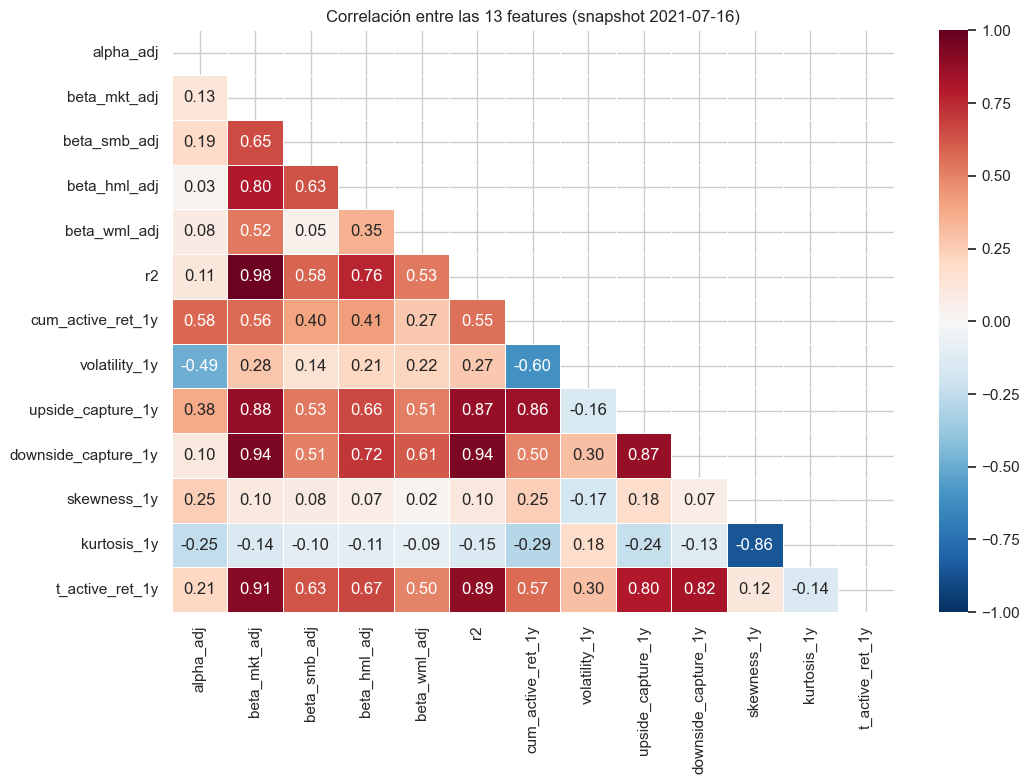


Alta correlación entre features (|r| > 0.6):
  beta_mkt_adj – beta_smb_adj: 0.650
  beta_mkt_adj – beta_hml_adj: 0.799
  beta_mkt_adj – r2: 0.983
  beta_mkt_adj – upside_capture_1y: 0.875
  beta_mkt_adj – downside_capture_1y: 0.944
  beta_mkt_adj – t_active_ret_1y: 0.910
  beta_smb_adj – beta_hml_adj: 0.633
  beta_smb_adj – t_active_ret_1y: 0.630
  beta_hml_adj – r2: 0.761
  beta_hml_adj – upside_capture_1y: 0.657
  beta_hml_adj – downside_capture_1y: 0.717
  beta_hml_adj – t_active_ret_1y: 0.669
  beta_wml_adj – downside_capture_1y: 0.611
  r2 – upside_capture_1y: 0.870
  r2 – downside_capture_1y: 0.944
  r2 – t_active_ret_1y: 0.885
  cum_active_ret_1y – volatility_1y: -0.602
  cum_active_ret_1y – upside_capture_1y: 0.859
  upside_capture_1y – downside_capture_1y: 0.873
  upside_capture_1y – t_active_ret_1y: 0.805
  downside_capture_1y – t_active_ret_1y: 0.821
  skewness_1y – kurtosis_1y: -0.858

El PCA resolverá estas correlaciones produciendo componentes ortogonales.

Snapshot guar

In [30]:
# =============================================================================
# 6.1 – Snapshot cross-seccional (fecha de corte: 2021-07-16)
# =============================================================================
# Fuente: data/features/matriz_features_v1.parquet (salida de 5.6)
# Objetivo: 1 fila por fondo con 13 features limpias para PCA + clustering
# =============================================================================


# ── 0. Carga de la matriz de features (5.6) ─────────────────────────────────
FEATURES_PATH = Path("data") / "features" / "matriz_features_v1.parquet"
if not FEATURES_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {FEATURES_PATH}. Ejecuta antes la sección 5.6.")

feat_matrix = pd.read_parquet(FEATURES_PATH)
feat_matrix["date"] = pd.to_datetime(feat_matrix["date"])

print(f"Matriz cargada: {feat_matrix.shape}")
print(f"Fondos únicos: {feat_matrix['fund_id'].nunique():,}")
print(f"Rango temporal: {feat_matrix['date'].min().date()} → {feat_matrix['date'].max().date()}")

# ── 1. Fecha de corte: último día hábil del panel ────────────────────────────
FECHA_CORTE = feat_matrix["date"].max()
print(f"\nFecha de corte (snapshot): {FECHA_CORTE.date()}")

# ── 2. Filtrar al snapshot en fecha de corte ──────────────────────────────────
snapshot_raw = feat_matrix[feat_matrix["date"] == FECHA_CORTE].copy()
print(f"Fondos en el snapshot: {len(snapshot_raw):,}")

# ── 3. Selección de 13 features para PCA ────────────────────────────────────
FEATURES_PCA = [
    # Betas ajustadas (static)
    "alpha_adj", "beta_mkt_adj", "beta_smb_adj", "beta_hml_adj", "beta_wml_adj",
    # Calidad del modelo
    "r2",
    # Rolling 1y (completo al cierre)
    "cum_active_ret_1y", "volatility_1y", "upside_capture_1y",
    "downside_capture_1y", "skewness_1y", "kurtosis_1y", "t_active_ret_1y",
]

# Verificar que todas las features existen
missing_feats = [f for f in FEATURES_PCA if f not in snapshot_raw.columns]
if missing_feats:
    raise KeyError(f"Features no encontradas en la matriz: {missing_feats}")

# ── 4. Construir snapshot limpio ──────────────────────────────────────────────
id_cols  = ["fund_id", "asia_biased", "diversified_biased"]
snapshot = snapshot_raw[id_cols + FEATURES_PCA].copy()

# Filas con algún NaN en las 13 features
n_antes = len(snapshot)
snapshot = snapshot.dropna(subset=FEATURES_PCA).reset_index(drop=True)
n_despues = len(snapshot)
n_dropped = n_antes - n_despues

print(f"\nFilas con NaN en FEATURES_PCA: {n_dropped:,} (eliminadas)")
print(f"Fondos válidos para PCA/clustering: {n_despues:,}")
print(f"  → asia_biased       : {snapshot['asia_biased'].sum():,}")
print(f"  → diversified_biased: {snapshot['diversified_biased'].sum():,}")

# ── 5. Estadísticas descriptivas de las 13 features ─────────────────────────
print("\n" + "=" * 70)
print("6.1 – ESTADÍSTICAS DESCRIPTIVAS DE LAS 13 FEATURES (snapshot)")
print("=" * 70)
display(snapshot[FEATURES_PCA].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(4))

# ── 6. Heatmap de correlación entre features ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = snapshot[FEATURES_PCA].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Correlación entre las 13 features (snapshot 2021-07-16)")
plt.tight_layout()
plt.show()

print("\nAlta correlación entre features (|r| > 0.6):")
for i in range(len(FEATURES_PCA)):
    for j in range(i+1, len(FEATURES_PCA)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f"  {FEATURES_PCA[i]} – {FEATURES_PCA[j]}: {r:.3f}")

print("\nEl PCA resolverá estas correlaciones produciendo componentes ortogonales.")

# Guardar snapshot para reproducibilidad
OUT_SNAPSHOT = Path("data") / "features" / "snapshot_pca_clustering.parquet"
OUT_SNAPSHOT.parent.mkdir(parents=True, exist_ok=True)
snapshot.to_parquet(OUT_SNAPSHOT, index=False)
print(f"\nSnapshot guardado en: {OUT_SNAPSHOT}")

### 6.2 – Estandarización (`StandardScaler`)

El PCA maximiza varianza. Si las features tienen escalas muy diferentes, las que tengan mayor varianza absoluta dominarán los primeros componentes, independientemente de su relevancia financiera. Por ejemplo:

- `cum_active_ret_1y` puede tener valores en el rango [−0.5, +0.5]
- `beta_smb_adj` suele estar en [0.0, 0.3]
- `kurtosis_1y` puede llegar a 10+ en fondos con colas gruesas

Sin escalar, la kurtosis y el retorno activo dominarían completamente el PC1, haciendo que features igualmente informativas (como las betas de estilo) apenas contribuyeran.

`StandardScaler` centra cada feature en media = 0 y la escala a std = 1, asegurando que todas las features contribuyan proporcionalmente al análisis de varianza del PCA.

6.2 – ESTANDARIZACIÓN
Shape X_scaled: (2772, 13)
Media por feature (tras escalar):
  alpha_adj                   : mean=0.0000  std=1.0000
  beta_mkt_adj                : mean=-0.0000  std=1.0000
  beta_smb_adj                : mean=0.0000  std=1.0000
  beta_hml_adj                : mean=0.0000  std=1.0000
  beta_wml_adj                : mean=-0.0000  std=1.0000
  r2                          : mean=0.0000  std=1.0000
  cum_active_ret_1y           : mean=0.0000  std=1.0000
  volatility_1y               : mean=0.0000  std=1.0000
  upside_capture_1y           : mean=-0.0000  std=1.0000
  downside_capture_1y         : mean=-0.0000  std=1.0000
  skewness_1y                 : mean=-0.0000  std=1.0000
  kurtosis_1y                 : mean=0.0000  std=1.0000
  t_active_ret_1y             : mean=-0.0000  std=1.0000


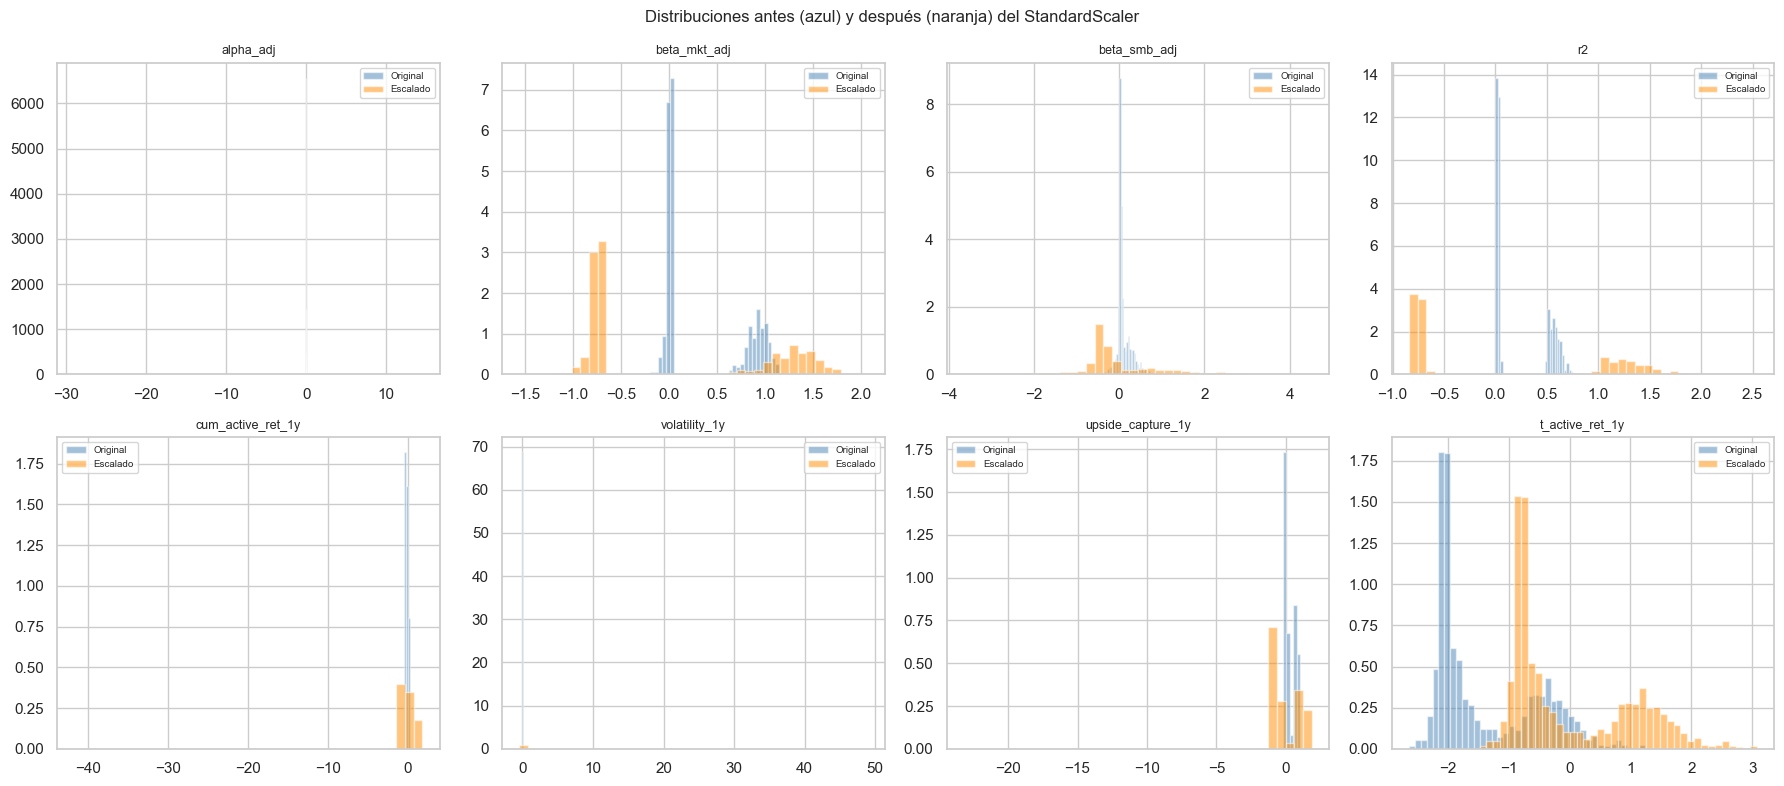

In [31]:
# =============================================================================
# 6.2 – Estandarización con StandardScaler
# =============================================================================

X_raw = snapshot[FEATURES_PCA].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("=" * 60)
print("6.2 – ESTANDARIZACIÓN")
print("=" * 60)
print(f"Shape X_scaled: {X_scaled.shape}")
print(f"Media por feature (tras escalar):")
means_after = X_scaled.mean(axis=0)
stds_after  = X_scaled.std(axis=0)
for feat, m, s in zip(FEATURES_PCA, means_after, stds_after):
    print(f"  {feat:<28}: mean={m:.4f}  std={s:.4f}")
print("=" * 60)

# Histogramas de distribución antes/después para algunas features clave
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
feat_plot_idx = [0, 1, 2, 5, 6, 7, 8, 12]  # alpha_adj, beta_mkt_adj, beta_smb_adj, r2, cum, vol, up, t_active
for ax, fi in zip(axes.flat, feat_plot_idx):
    col_orig  = snapshot[FEATURES_PCA[fi]].dropna()
    col_scaled = X_scaled[:, fi]
    ax.hist(col_orig, bins=40, alpha=0.5, color="steelblue", label="Original", density=True)
    ax.hist(col_scaled, bins=40, alpha=0.5, color="darkorange", label="Escalado", density=True)
    ax.set_title(FEATURES_PCA[fi], fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Distribuciones antes (azul) y después (naranja) del StandardScaler", fontsize=12)
plt.tight_layout()
plt.show()

### 6.3 – PCA: selección del número de componentes

El **número de componentes** es el hiperparámetro clave del PCA. Usamos dos criterios complementarios:

1. **Scree plot (regla del codo)**: el número de componentes donde la pendiente de varianza explicada se estabiliza.
2. **Varianza acumulada ≥ 85%**: retener los primeros *k* componentes que expliquen al menos el 85% de la varianza total. Este umbral es un estándar en la literatura de reducción de dimensionalidad (James et al., *An Introduction to Statistical Learning*, Cap. 10).

**¿Por qué 85% y no 95%?** Con 13 features en datos financieros, exigir el 95% podría requerir 8-10 componentes, perdiendo la ventaja de parsimonia. El 85% equilibra la retención de información con la reducción de ruido y la interpretabilidad financiera.

6.3 – VARIANZA EXPLICADA POR COMPONENTE
  PC1 : individual=50.00%   acumulada= 50.00%
  PC2 : individual=19.13%   acumulada= 69.13%
  PC3 : individual=11.19%   acumulada= 80.32%
  PC4 : individual= 7.74%   acumulada= 88.06% ← CODO (85%)
  PC5 : individual= 4.39%   acumulada= 92.45%
  PC6 : individual= 2.72%   acumulada= 95.17%
  PC7 : individual= 2.05%   acumulada= 97.21%
  PC8 : individual= 1.30%   acumulada= 98.51%
  PC9 : individual= 1.02%   acumulada= 99.53%
  PC10: individual= 0.37%   acumulada= 99.90%
  PC11: individual= 0.08%   acumulada= 99.98%
  PC12: individual= 0.02%   acumulada=100.00%
  PC13: individual= 0.00%   acumulada=100.00%

Componentes necesarios para ≥ 85% de varianza: 4


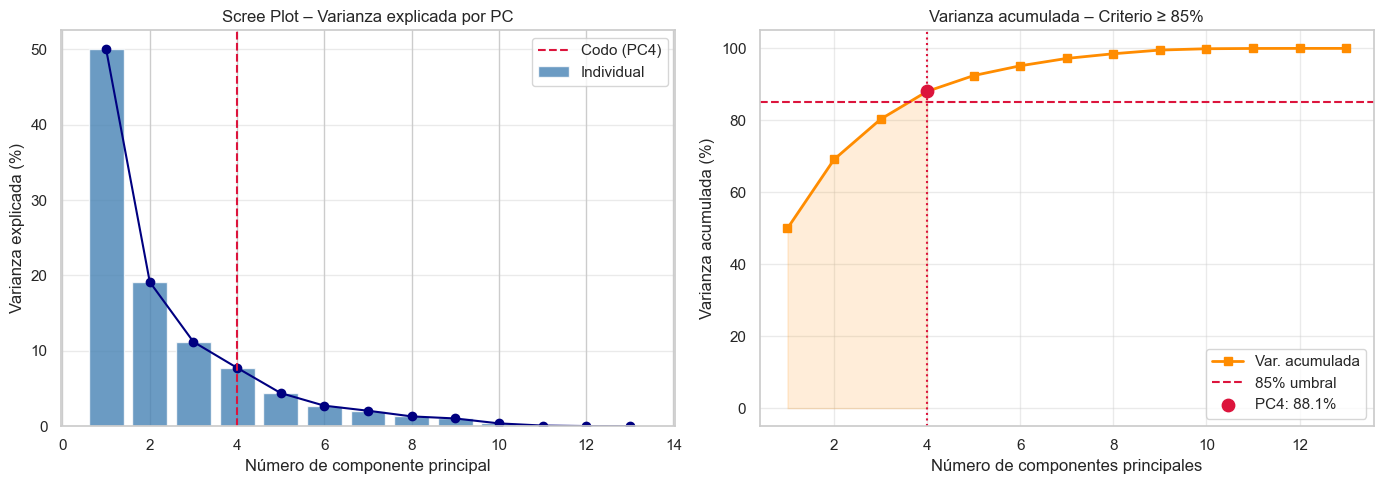


✓ PCA ajustado con n_components = 4
  Shape X_pca: (2772, 4)
  Varianza explicada total: 88.06%


In [32]:
# =============================================================================
# 6.3 – PCA: selección de componentes (scree plot + varianza acumulada)
# =============================================================================

VARIANZA_UMBRAL = 0.85  # Retener componentes que expliquen ≥ 85% de varianza acumulada

# ── 1. PCA completo (n_components = n_features) ───────────────────────────────
pca_full = PCA(n_components=len(FEATURES_PCA), random_state=42)
pca_full.fit(X_scaled)

varianza_ind  = pca_full.explained_variance_ratio_
varianza_acu  = np.cumsum(varianza_ind)
n_componentes = len(FEATURES_PCA)

# ── 2. Determinar n_components óptimo con criterio 85% ───────────────────────
n_opt = int(np.argmax(varianza_acu >= VARIANZA_UMBRAL) + 1)
print("=" * 65)
print("6.3 – VARIANZA EXPLICADA POR COMPONENTE")
print("=" * 65)
for i, (vi, va) in enumerate(zip(varianza_ind, varianza_acu), 1):
    marca = " ← CODO (85%)" if i == n_opt else ""
    print(f"  PC{i:<2}: individual={vi*100:5.2f}%   acumulada={va*100:6.2f}%{marca}")

print(f"\nComponentes necesarios para ≥ {VARIANZA_UMBRAL*100:.0f}% de varianza: {n_opt}")

# ── 3. Scree plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 3a. Varianza individual (scree)
ax1.bar(range(1, n_componentes+1), varianza_ind * 100, color="steelblue", alpha=0.8, label="Individual")
ax1.plot(range(1, n_componentes+1), varianza_ind * 100, "o-", color="navy", linewidth=1.5)
ax1.axvline(x=n_opt, color="crimson", linestyle="--", linewidth=1.5, label=f"Codo (PC{n_opt})")
ax1.set_xlabel("Número de componente principal")
ax1.set_ylabel("Varianza explicada (%)")
ax1.set_title("Scree Plot – Varianza explicada por PC")
ax1.legend()
ax1.grid(axis="y", alpha=0.4)

# 3b. Varianza acumulada
ax2.plot(range(1, n_componentes+1), varianza_acu * 100, "s-", color="darkorange", linewidth=2, label="Var. acumulada")
ax2.axhline(y=VARIANZA_UMBRAL*100, color="crimson", linestyle="--", linewidth=1.5, label=f"{VARIANZA_UMBRAL*100:.0f}% umbral")
ax2.axvline(x=n_opt, color="crimson", linestyle=":", linewidth=1.5)
ax2.fill_between(range(1, n_opt+1), varianza_acu[:n_opt]*100, alpha=0.15, color="darkorange")
ax2.scatter([n_opt], [varianza_acu[n_opt-1]*100], color="crimson", zorder=5, s=80,
            label=f"PC{n_opt}: {varianza_acu[n_opt-1]*100:.1f}%")
ax2.set_xlabel("Número de componentes principales")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_title(f"Varianza acumulada – Criterio ≥ {VARIANZA_UMBRAL*100:.0f}%")
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ── 4. PCA final con n_opt componentes ───────────────────────────────────────
pca = PCA(n_components=n_opt, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n✓ PCA ajustado con n_components = {n_opt}")
print(f"  Shape X_pca: {X_pca.shape}")
print(f"  Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

### 6.4 – Interpretación financiera de los componentes principales

Los **loadings** (pesos) del PCA son la clave de la interpretabilidad: indican cuánto contribuye cada feature original a cada componente. Un loading alto (positivo o negativo) significa que esa feature discrimina fuertemente a lo largo de ese eje.

Para hacer el fondo de fondos interpretable, necesitamos entender qué significa estar en la parte alta o baja de cada PC:

| Componente | Nombre financiero esperado | Features con mayor loading esperado |
|---|---|---|
| **PC1** | "Intensidad de exposición a Asia" | `beta_mkt_adj`, `r2`, `upside_capture_1y`, `cum_active_ret_1y` |
| **PC2** | "Estilo de inversión (tamaño / valor)" | `beta_smb_adj`, `beta_hml_adj` |
| **PC3** | "Riesgo y colas" | `volatility_1y`, `skewness_1y`, `kurtosis_1y`, `downside_capture_1y` |
| **PC4** | "Alpha y momentum activo" | `alpha_adj`, `beta_wml_adj`, `t_active_ret_1y` |

Esta interpretación es una **hipótesis** a validar con los loadings reales del PCA sobre nuestros datos.

6.4 – LOADINGS DEL PCA (features × componentes)
                       PC1    PC2    PC3    PC4
alpha_adj            0.108 -0.426 -0.264  0.033
beta_mkt_adj         0.381  0.115  0.018 -0.034
beta_smb_adj         0.261  0.034 -0.033 -0.631
beta_hml_adj         0.312  0.124  0.032 -0.242
beta_wml_adj         0.221  0.109  0.058  0.710
r2                   0.375  0.113  0.026  0.020
cum_active_ret_1y    0.272 -0.366 -0.303  0.032
volatility_1y        0.048  0.520  0.378 -0.024
upside_capture_1y    0.368 -0.127 -0.153  0.105
downside_capture_1y  0.363  0.134  0.031  0.147
skewness_1y          0.078 -0.400  0.582 -0.035
kurtosis_1y         -0.098  0.396 -0.571 -0.010
t_active_ret_1y      0.358  0.087  0.015 -0.035


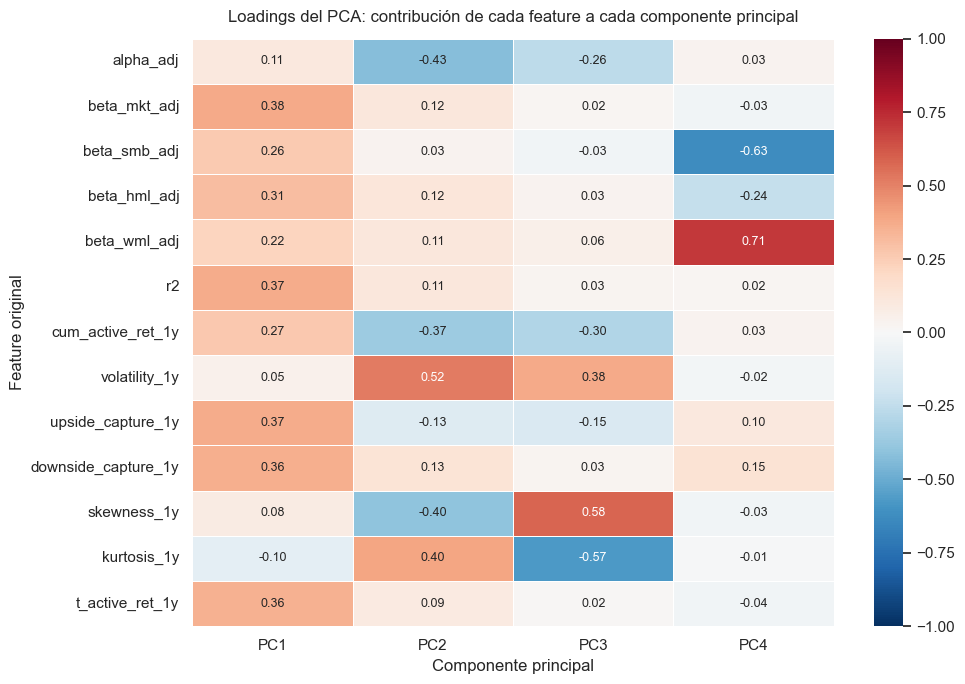


INTERPRETACIÓN FINANCIERA DE LOS COMPONENTES

  PC1 (50.0% varianza):
    Features dominantes: beta_mkt_adj(+), r2(+), upside_capture_1y(+)

  PC2 (19.1% varianza):
    Features dominantes: volatility_1y(+), alpha_adj(-), skewness_1y(-)

  PC3 (11.2% varianza):
    Features dominantes: skewness_1y(+), kurtosis_1y(-), volatility_1y(+)

  PC4 (7.7% varianza):
    Features dominantes: beta_wml_adj(+), beta_smb_adj(-), beta_hml_adj(-)


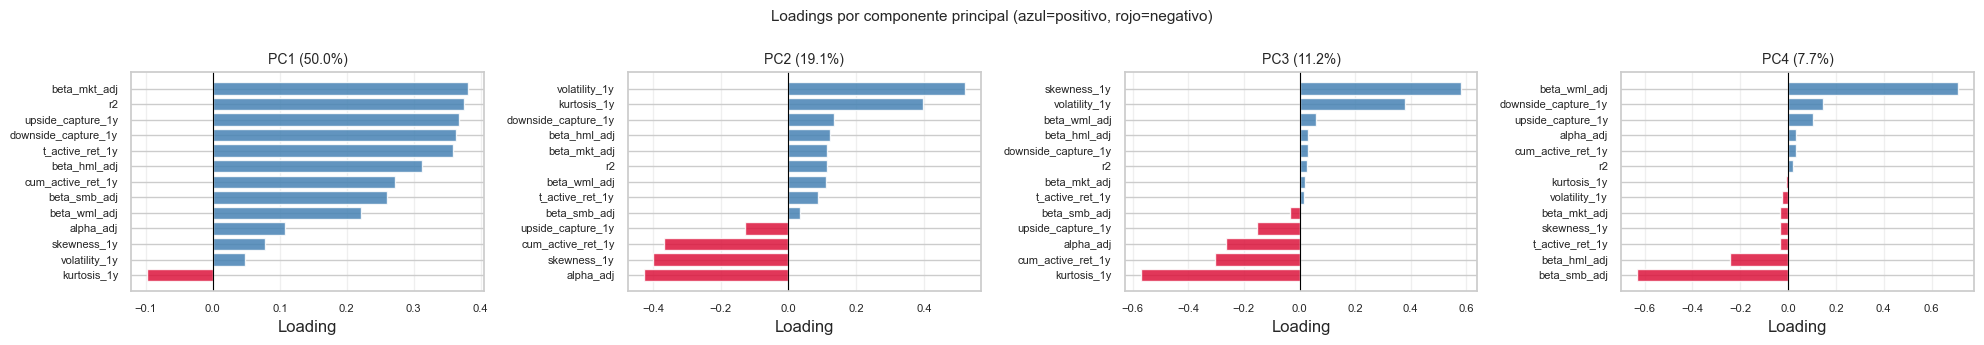


✓ Scores PCA guardados en: data\features\pca_scores.parquet
  Shape: (2772, 7)


In [33]:
# =============================================================================
# 6.4 – Heatmap de loadings e interpretación financiera de los PCs
# =============================================================================

# ── 1. Matriz de loadings: shape = (n_opt, 13) ───────────────────────────────
loadings_df = pd.DataFrame(
    pca.components_.T,        # Transpuesta: features como filas, PCs como columnas
    index=FEATURES_PCA,
    columns=[f"PC{i+1}" for i in range(n_opt)]
)

print("=" * 65)
print("6.4 – LOADINGS DEL PCA (features × componentes)")
print("=" * 65)
print(loadings_df.round(3).to_string())

# ── 2. Heatmap principal ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(min(n_opt * 1.8 + 3, 16), 7))
sns.heatmap(
    loadings_df,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    ax=ax
)
ax.set_title("Loadings del PCA: contribución de cada feature a cada componente principal", fontsize=12, pad=12)
ax.set_xlabel("Componente principal")
ax.set_ylabel("Feature original")
plt.tight_layout()
plt.show()

# ── 3. Naming financiero basado en los loadings reales ───────────────────────
print("\n" + "=" * 65)
print("INTERPRETACIÓN FINANCIERA DE LOS COMPONENTES")
print("=" * 65)

for pc_idx in range(n_opt):
    pc_name = f"PC{pc_idx+1}"
    pc_load = loadings_df[pc_name].abs().sort_values(ascending=False)
    top3 = pc_load.head(3)
    var_pct = pca.explained_variance_ratio_[pc_idx] * 100

    # Signs of top features
    signs = loadings_df[pc_name][top3.index]
    sign_str = ", ".join([f"{f}({'+'if s>0 else '-'})" for f, s in signs.items()])
    print(f"\n  {pc_name} ({var_pct:.1f}% varianza):")
    print(f"    Features dominantes: {sign_str}")

# ── 4. Bar chart de loadings por componente ───────────────────────────────────
n_cols = min(n_opt, 4)
n_rows = (n_opt + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes_flat = np.array(axes).flat if n_opt > 1 else [axes]

for i, ax in enumerate(axes_flat):
    if i >= n_opt:
        ax.set_visible(False)
        continue
    pc_name = f"PC{i+1}"
    load_sorted = loadings_df[pc_name].sort_values()
    colors = ["crimson" if v < 0 else "steelblue" for v in load_sorted]
    ax.barh(load_sorted.index, load_sorted.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pc_name} ({pca.explained_variance_ratio_[i]*100:.1f}%)", fontsize=10)
    ax.set_xlabel("Loading")
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=8)

plt.suptitle("Loadings por componente principal (azul=positivo, rojo=negativo)", fontsize=11)
plt.tight_layout()
plt.show()

# ── 5. Construir DataFrame PCA para clustering ────────────────────────────────
pc_cols = [f"PC{i+1}" for i in range(n_opt)]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
df_pca["fund_id"]            = snapshot["fund_id"].values
df_pca["asia_biased"]        = snapshot["asia_biased"].values
df_pca["diversified_biased"] = snapshot["diversified_biased"].values

# Guardar scores PCA para clustering
OUT_PCA = Path("data") / "features" / "pca_scores.parquet"
df_pca.to_parquet(OUT_PCA, index=False)
print(f"\n✓ Scores PCA guardados en: {OUT_PCA}")
print(f"  Shape: {df_pca.shape}")

 Interpretación de los Componentes Principales (PCA)


| Componente | Varianza explicada | Título interpretativo | Features dominantes | Interpretación financiera |
|---|---|---|---|---|
| **PC1** | 50.0% | **Intensidad de Exposición al Mercado Asiático** | `beta_mkt_adj` (+), `r2` (+), `upside_capture_1y` (+) | Eje principal del universo. **PC1 alto** = fondo que replica al mercado asiático: beta elevado, retornos bien explicados por FF4 y alta participación en subidas. **PC1 bajo** = fondo diversificador, ortogonal al mercado asiático. Explica la mitad de la varianza porque el universo fue construido precisamente en torno a este eje. |
| **PC2** | 19.1% | **Calidad Riesgo-Rentabilidad** | `volatility_1y` (+), `alpha_adj` (−), `skewness_1y` (−) | Separa fondos por su calidad intrínseca independientemente de la exposición a Asia. **PC2 alto** = fondo errático, volátil, con alpha negativo y cola izquierda pesada (riesgo de crash). **PC2 bajo** = fondo estable, con alpha positivo y retornos con sesgo alcista. |
| **PC3** | 11.2% | **Forma de la Distribución de Retornos** | `skewness_1y` (+), `kurtosis_1y` (−), `volatility_1y` (+) | Captura la forma estadística de los retornos más allá de media y varianza. **PC3 alto** = retornos con sesgo positivo y colas ligeras (perfil *trend-follower*, ganancias grandes ocasionales). **PC3 bajo** = eventos extremos frecuentes con sesgo negativo (perfil de fondo con riesgo de cola oculto). |
| **PC4** | 7.7% | **Sesgo de Estilo Factorial** | `beta_wml_adj` (+), `beta_smb_adj` (−), `beta_hml_adj` (−) | Captura el estilo de inversión en el espacio Fama-French. **PC4 alto** = estilo *Growth + Large-Cap + Momentum* (tecnología asiática: TSMC, Samsung, Tencent). **PC4 bajo** = estilo *Value + Small-Cap + Anti-momentum* (empresas tradicionales o mercados emergentes menores). |

> **Nota metodológica:** `skewness_1y` aparece con signo negativo en PC2 y positivo en PC3 porque actúa en contextos distintos: en PC2 acompaña a alta volatilidad y alpha negativo (señal de mala calidad); en PC3 acompaña a kurtosis baja (cola ligera + sesgo alcista), que es una combinación financieramente diferente y deseable.

**Varianza acumulada:**

| PCs incluidos | Varianza acumulada |
|---|---|
| PC1 | 50.0% |
| PC1 + PC2 | 69.1% |
| PC1 + PC2 + PC3 | 80.3% |
| PC1 + PC2 + PC3 + PC4 | **88.0%** |

### 6.5 - Visualizacion y validacion del espacio PCA

El biplot PC1 vs PC2 permite verificar visualmente si la clasificacion asia_biased / diversified_biased es coherente con la posicion en el espacio PCA, si hay separacion natural entre grupos, y si existen outliers.

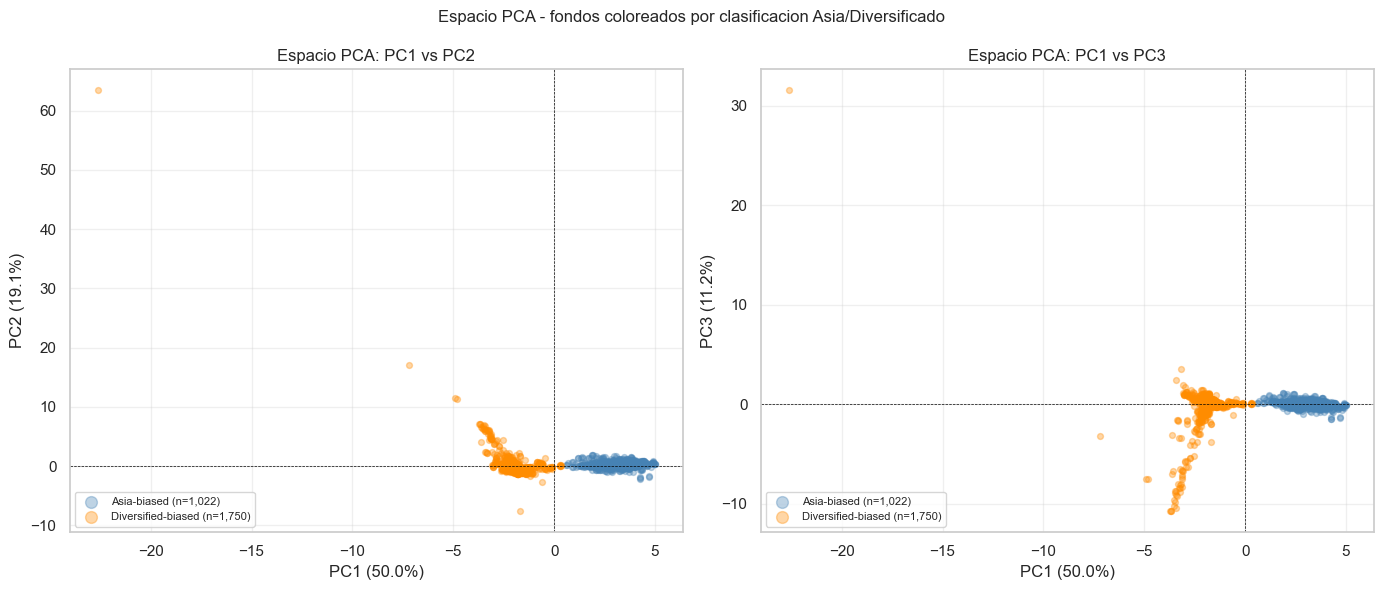

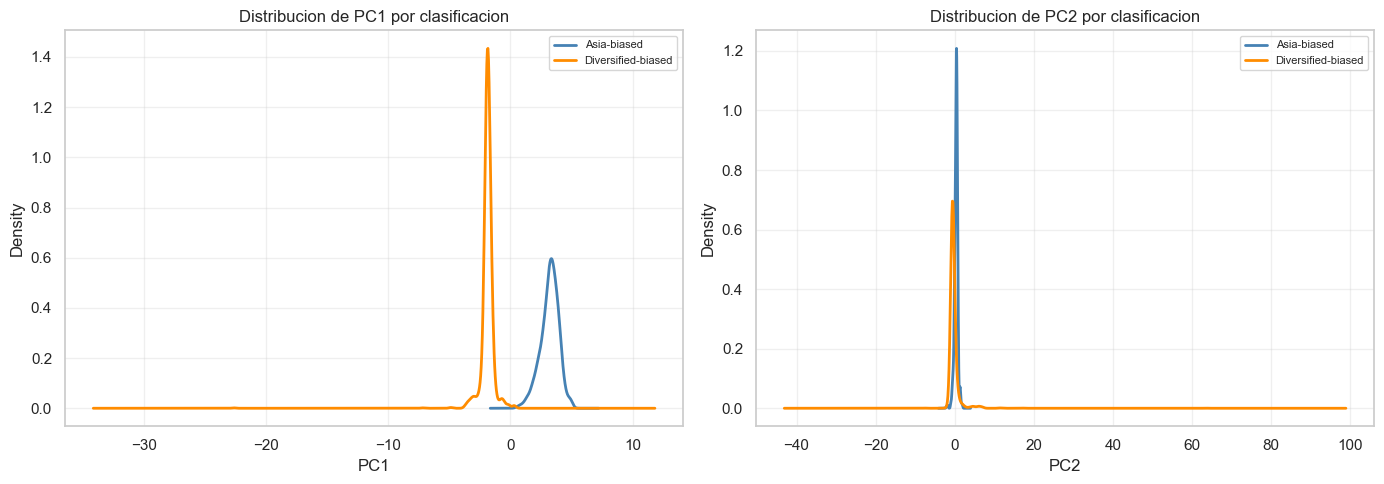


Resumen:
  Fondos en espacio PCA: 2,772
  PC1 rango: [-22.64, 5.00]
  PC2 rango: [-7.60, 63.40]

>>> El espacio PCA de 4 dimensiones sera la entrada para las 3 tecnicas de clustering <<<


In [34]:
# =============================================================================
# 6.5 - Visualizacion: biplot PC1 vs PC2 + PC1 vs PC3
# =============================================================================

colors_map = {
    (True, False):  ("steelblue",   "Asia-biased"),
    (False, True):  ("darkorange",  "Diversified-biased"),
    (False, False): ("grey",        "Sin clasificar"),
    (True, True):   ("purple",      "Ambos"),
}

label_col   = []
color_col   = []
for _, row in df_pca.iterrows():
    key = (bool(row["asia_biased"]), bool(row["diversified_biased"]))
    c, l = colors_map.get(key, ("grey", "Otro"))
    color_col.append(c)
    label_col.append(l)

df_pca["_color"] = color_col
df_pca["_label"] = label_col

# ── Biplot PC1 vs PC2 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, min(2, n_opt - 1) if n_opt >= 3 else 1, figsize=(14, 6))
if n_opt < 3:
    axes = [axes]

for ax, (pc_x, pc_y) in zip(axes if hasattr(axes, "__iter__") else [axes],
                             [("PC1", "PC2"), ("PC1", "PC3")]):
    if pc_y not in df_pca.columns:
        continue
    for key, (clr, lbl) in colors_map.items():
        mask = (df_pca["asia_biased"] == key[0]) & (df_pca["diversified_biased"] == key[1])
        sub = df_pca[mask]
        if len(sub) == 0:
            continue
        ax.scatter(sub[pc_x], sub[pc_y], c=clr, alpha=0.35, s=18, label=f"{lbl} (n={len(sub):,})")
    ax.set_xlabel(f"{pc_x} ({pca.explained_variance_ratio_[int(pc_x[2:])-1]*100:.1f}%)")
    ax.set_ylabel(f"{pc_y} ({pca.explained_variance_ratio_[int(pc_y[2:])-1]*100:.1f}%)")
    ax.set_title(f"Espacio PCA: {pc_x} vs {pc_y}")
    ax.legend(fontsize=8, markerscale=2)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
    ax.grid(alpha=0.3)

plt.suptitle("Espacio PCA - fondos coloreados por clasificacion Asia/Diversificado", fontsize=12)
plt.tight_layout()
plt.show()

# ── Densidad por clasificacion ────────────────────────────────────────────────
fig, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for pc_i, ax in enumerate(axes2):
    pc_name = f"PC{pc_i + 1}"
    if pc_name not in df_pca.columns:
        continue
    for key, (clr, lbl) in colors_map.items():
        mask = (df_pca["asia_biased"] == key[0]) & (df_pca["diversified_biased"] == key[1])
        sub = df_pca[mask]
        if len(sub) < 10:
            continue
        sub[pc_name].plot.kde(ax=ax, label=lbl, color=clr, linewidth=2)
    ax.set_title(f"Distribucion de {pc_name} por clasificacion")
    ax.set_xlabel(pc_name)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumen:")
print(f"  Fondos en espacio PCA: {len(df_pca):,}")
print(f"  PC1 rango: [{df_pca['PC1'].min():.2f}, {df_pca['PC1'].max():.2f}]")
if "PC2" in df_pca.columns:
    print(f"  PC2 rango: [{df_pca['PC2'].min():.2f}, {df_pca['PC2'].max():.2f}]")
print(f"\n>>> El espacio PCA de {n_opt} dimensiones sera la entrada para las 3 tecnicas de clustering <<<")
del df_pca["_color"], df_pca["_label"]

### 6.6 – Análisis de outliers en el espacio PCA

Una vez proyectados los fondos en el espacio PCA, se identifican aquellos cuyo perfil resulta **estadísticamente atípico dentro de su propio grupo** (Asia-biased o Diversified-biased).

La detección se basa en la **distancia de Mahalanobis** sobre los 4 componentes principales: a diferencia de la distancia euclídea, tiene en cuenta la forma y correlación interna de cada grupo, por lo que un fondo es "outlier" solo si es inusual *respecto a sus pares*, no en términos absolutos.

**¿Por qué interesa identificarlos?**
- Fondos con perfiles extremos pueden distorsionar los centroides de clustering y las métricas de calidad.
- Su inspección manual permite verificar si el comportamiento atípico es real (fondo genuinamente singular) o un artefacto de datos (historial corto, error de clasificación, datos erróneos).
- Los candidatos a revisión o exclusión quedan documentados antes de pasar a la fase de construcción de cartera.

**Output:** tabla de outliers con nombre del fondo, scores PC1–PC4 y comparativa de sus métricas clave frente a la mediana del grupo.

Metadatos cargados: 24,819 fondos únicos
Columnas disponibles: ['fund_id', 'name', 'isin']
OUTLIERS EN ESPACIO PCA  (umbral: distancia Mahalanobis > P97.5)
Total outliers detectados: 70  (26 Asia-biased, 44 Diversified-biased)



,fund_id,name,grupo,mahal_dist,PC1,PC2,PC3,PC4,beta_mkt_adj,alpha_adj,volatility_1y,skewness_1y,kurtosis_1y,upside_capture_1y,downside_capture_1y,cum_active_ret_1y
47,164256,"EDM INTERNATIONAL STRATEGY ""L EUR"" (EUR)",Diversified-biased,39.8977,-22.6353,63.3958,31.5469,-3.8410,0.0005,-0.0030,0.5807,-15.8692,251.8879,-9.2380,0.4554,-9.2377
32,20985,"BNP SUSTAINABLE EUR COR BD ""C"" (EUR) ACC",Diversified-biased,9.3392,-7.1998,17.0944,-3.2005,0.0813,-0.0122,-0.0006,0.1014,-15.8724,251.9557,-1.6778,0.0275,-1.8808
40,139003,"FRANKLIN U.S. DOLLAR ""A"" (USD) D",Diversified-biased,8.0204,-3.6745,7.1031,-10.7543,0.1261,0.0010,-0.0000,0.0001,-15.8745,252.0000,-0.0011,-0.0000,-0.2926
38,136001,"FIDELITY US DOLLAR CASH ""A"" D",Diversified-biased,8.0074,-3.7088,7.1741,-10.6967,0.0828,0.0052,-0.0000,0.0009,-15.8706,251.9170,-0.0022,0.0247,-0.3095
49,178730,"LO S - SH-T MN MKT (USD) ""M"" (USD) INC C",Diversified-biased,8.0002,-3.6919,7.0906,-10.7197,0.1371,0.0006,-0.0000,0.0006,-15.8448,251.3692,0.0000,0.0155,-0.3016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,226368,"SCH ISF ASI DIV MAX ""A1"" (EURHDG) INC MF",Asia-biased,4.2750,1.8653,1.9445,1.1285,0.2232,0.8503,-0.0003,0.0077,-0.3367,2.0771,0.6067,0.7017,-0.1759
22,246040,"VANGUARD PACIFIC EX J ""IP"" (GBP) D",Asia-biased,4.2621,0.5688,0.1559,0.1317,2.5699,0.7075,-0.0000,0.0087,-0.6119,2.6282,0.7611,0.8584,-0.1325
9,92620,"JPM ASEAN EQUITY ""A"" (USD) D",Asia-biased,4.2313,3.4139,1.1421,0.7826,-1.5653,1.0981,-0.0001,0.0085,0.5753,3.8556,0.6665,0.7487,-0.1503
23,265638,VANGUARD PAC EX-JAP STOCK IND (GBP) INC,Asia-biased,4.1214,0.6479,0.1980,0.1532,2.5456,0.7112,-0.0000,0.0087,-0.6022,2.5708,0.7608,0.8581,-0.1325


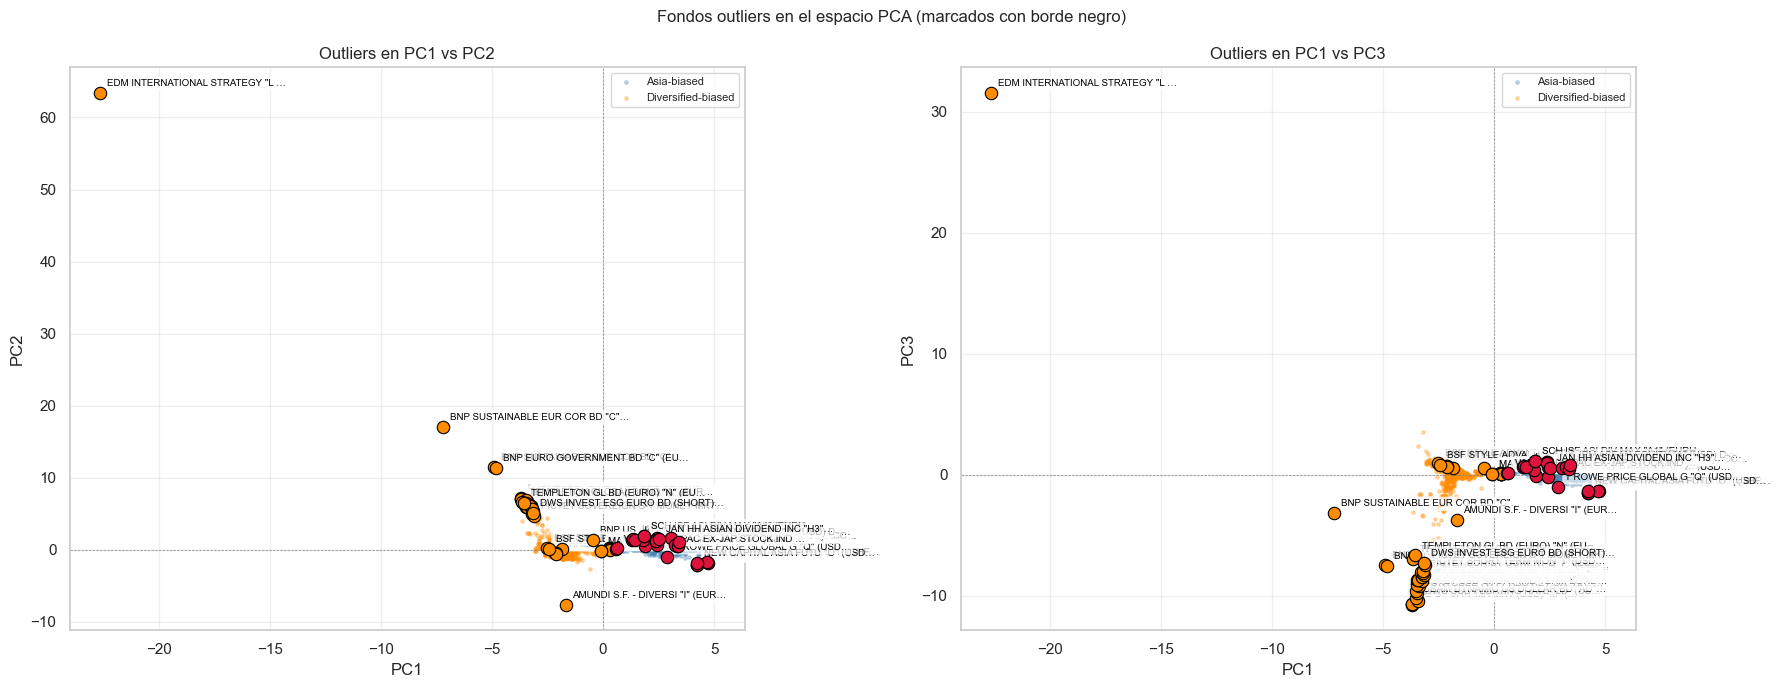

In [35]:
# =============================================================================
# ANÁLISIS DE OUTLIERS EN EL ESPACIO PCA
# =============================================================================

# ── 1. Obtener nombre de los fondos (fund_id → name) ─────────────────────────
_panel_meta = pd.read_parquet(
    Path("data") / "daily_universe" / "panel_diario_universo.parquet",
    columns=["allfunds_id", "name", "isin"]
)

fund_meta = (
    _panel_meta
    .dropna(subset=["allfunds_id"])
    .drop_duplicates(subset=["allfunds_id"])
    .rename(columns={"allfunds_id": "fund_id"})
)

print(f"Metadatos cargados: {len(fund_meta):,} fondos únicos")
print(f"Columnas disponibles: {fund_meta.columns.tolist()}")
del _panel_meta

# ── 2. Enriquecer df_pca con nombre y features originales ────────────────────
# (resto del código exactamente igual desde aquí)
df_outlier_full = (
    df_pca
    .merge(fund_meta, on="fund_id", how="left")
    .merge(snapshot[["fund_id"] + FEATURES_PCA], on="fund_id", how="left")
)

# ── 3. Detectar outliers: distancia de Mahalanobis por grupo ─────────────────
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

THRESHOLD_PERCENTILE = 97.5   # fondos por encima del percentil 97.5 de distancia
PC_COLS = [c for c in df_pca.columns if c.startswith("PC")]

outlier_rows = []

for group_label, group_name in [(1, "Asia-biased"), (0, "Diversified-biased")]:
    # Seleccionar el grupo correcto
    if group_name == "Asia-biased":
        mask_group = df_outlier_full["asia_biased"] == 1
    else:
        mask_group = df_outlier_full["diversified_biased"] == 1

    grp = df_outlier_full[mask_group][PC_COLS].values
    if len(grp) < len(PC_COLS) + 2:
        continue

    # Centroide y covarianza del grupo
    centroid = grp.mean(axis=0)
    cov = np.cov(grp.T)

    try:
        cov_inv = np.linalg.pinv(cov)
        dists = np.array([mahalanobis(row, centroid, cov_inv) for row in grp])
    except Exception:
        dists = np.linalg.norm(grp - centroid, axis=1)   # fallback: distancia euclídea

    threshold = np.percentile(dists, THRESHOLD_PERCENTILE)
    outlier_mask_local = dists > threshold

    grp_full = df_outlier_full[mask_group].copy()
    grp_full["mahal_dist"] = dists
    grp_full["grupo"] = group_name
    outlier_rows.append(grp_full[outlier_mask_local])

outliers_df = pd.concat(outlier_rows, ignore_index=True).sort_values("mahal_dist", ascending=False)

# ── 4. Mostrar tabla de outliers ──────────────────────────────────────────────
DISPLAY_COLS = (
    ["fund_id", "name", "grupo", "mahal_dist"]
    + PC_COLS
    + ["beta_mkt_adj", "alpha_adj", "r2_adj",
       "volatility_1y", "skewness_1y", "kurtosis_1y",
       "upside_capture_1y", "downside_capture_1y",
       "cum_active_ret_1y"]
)
display_cols_ok = [c for c in DISPLAY_COLS if c in outliers_df.columns]

print("=" * 80)
print(f"OUTLIERS EN ESPACIO PCA  (umbral: distancia Mahalanobis > P{THRESHOLD_PERCENTILE})")
print("=" * 80)
print(f"Total outliers detectados: {len(outliers_df):,}  "
      f"({outliers_df[outliers_df['grupo']=='Asia-biased'].shape[0]} Asia-biased, "
      f"{outliers_df[outliers_df['grupo']=='Diversified-biased'].shape[0]} Diversified-biased)\n")

display(outliers_df[display_cols_ok].round(4))

# ── 5. Visualización de outliers sobre PC1 vs PC2 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
titles = [("PC1", "PC2"), ("PC1", "PC3")]

for ax, (pcx, pcy) in zip(axes, titles):
    if pcy not in df_outlier_full.columns:
        continue

    # Todos los fondos en gris de fondo
    mask_asia = df_outlier_full["asia_biased"] == 1
    mask_div  = df_outlier_full["diversified_biased"] == 1
    ax.scatter(df_outlier_full.loc[mask_asia, pcx], df_outlier_full.loc[mask_asia, pcy],
               c="steelblue", s=6, alpha=0.3, label="Asia-biased")
    ax.scatter(df_outlier_full.loc[mask_div, pcx], df_outlier_full.loc[mask_div, pcy],
               c="darkorange", s=6, alpha=0.3, label="Diversified-biased")

    # Outliers encima con anotación
    for _, row in outliers_df.iterrows():
        color = "crimson" if row["grupo"] == "Asia-biased" else "darkorange"
        ax.scatter(row[pcx], row[pcy], c=color, s=80, zorder=5,
                   edgecolors="black", linewidths=0.8)
        label_text = str(row.get("name", row["fund_id"]))
        label_text = label_text[:30] + "…" if len(label_text) > 30 else label_text
        ax.annotate(label_text,
                    xy=(row[pcx], row[pcy]),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=7, color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_xlabel(pcx)
    ax.set_ylabel(pcy)
    ax.set_title(f"Outliers en {pcx} vs {pcy}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Fondos outliers en el espacio PCA (marcados con borde negro)", fontsize=12)
plt.tight_layout()
plt.show()

# ── 6. Comparativa: outliers vs. mediana de su grupo ─────────────────────────
METRICS_COMPARE = [
    "beta_mkt_adj", "alpha_adj", "r2_adj",
    "volatility_1y", "skewness_1y", "kurtosis_1y",
    "upside_capture_1y", "downside_capture_1y", "cum_active_ret_1y",
]
metrics_ok = [m for m in METRICS_COMPARE if m in snapshot.columns]



 Conclusiones del análisis de outliers (6.6)

El análisis de distancia de Mahalanobis sobre el espacio PCA identifica **5 patrones** de comportamiento atípico entre los 70 fondos outliers detectados (P97.5). A continuación se detalla cada patrón, su causa y la decisión adoptada de cara al clustering.

| Patrón | Fondos representativos | N | Causa del comportamiento atípico | Decisión | Justificación |
|---|---|---|---|---|---|
| **A — Super-outlier absoluto** | EDM International Strategy | 1 | PC2=63.40, PC3=31.55: volatilidad extrema, alpha muy negativo, colas asimétricas. Perfil hedge-fund incompatible con el resto del universo. |  **Excluir** | Un único punto a distancia 39.90 (4× el siguiente) distorsionaría los centroides de K-Means y la métrica de Silhouette. Su presencia crearía un micro-cluster de 1 elemento o arrastraría el centroide del grupo diversificador hacia una zona sin sentido financiero. |
| **B — Monetarios / USD ultracorto plazo** | Franklin USD, Fidelity USD Cash, LO Short-Term MKT, DWS USD Floating Rate, GS USD Short, Pictet USD/EUR Short, Vontobel Abs Return Credit | ~10 | PC3 ≈ −10: kurtosis altísima y skewness negativa. Retornos casi planos con saltos bruscos puntuales (resets de tipos, distribuciones de cupones). Distribución fundamentalmente no gaussiana. |  **Excluir** | Forman un subgrupo estadísticamente homogéneo entre sí pero radicalmente distinto del resto de diversificadores. Incluirlos obligaría al modelo a crear un cluster específico "cash-like" que no aporta valor al objetivo de construcción de cartera Asia/Diversificado. Su perfil de riesgo (casi sin riesgo de mercado) está ya implícitamente cubierto por el límite de liquidez de la cartera. |
| **C — Trend-following sistemático** | Schroder GAIA Blue Trend (7 clases de participación) | 7 | PC4 ≈ +1.67: fuerte sesgo momentum (WML) con ausencia de exposición a Asia. Son 7 clases del mismo fondo subyacente. |  **Excluir** | La replicación de 7 veces el mismo fondo en clases distintas introduciría un sesgo de pseudo-duplicados en el clustering: el algoritmo percibiría un cluster artificialmente denso en el espacio PC4 que en realidad representa un único activo. Además, los fondos sistemáticos trend-following tienen una lógica de gestión (señales cuantitativas de momentum) incompatible con el marco de análisis fundamental FF4 sobre el que se construyeron las features. |
| **D — Renta fija sostenible (ESG)** | BNP Sustainable EUR Corporate Bond (2 clases) | 2 | PC2 ≈ +11–17: volatilidad y sensibilidad a tipos superior a la mediana del grupo diversificador. Alpha inferior al esperado para un diversificador conservador. | **Excluir** | Con solo 2 observaciones y un perfil que mezcla riesgo de crédito ESG con riesgo de duración, estos fondos no representan una categoría de diversificador generalizable. Su inclusión añadiría ruido al centroide del grupo diversificador sin mejorar la representatividad del clustering. |
| **E — Diversificador de alta calidad** | Amundi SF Diversi | 1 | PC2 = −7.60: único outlier en dirección **opuesta** — baja volatilidad, alpha positivo, sesgo alcista. Perfil de excelencia dentro del grupo. |  **Mantener** | Es un outlier por ser excepcionalmente bueno, no por ser problemático. Su presencia enriquece el cluster de diversificadores de calidad y lo convierte en candidato preferente para la construcción de cartera. Excluirlo penalizaría precisamente al fondo con el mejor perfil riesgo-retorno del grupo. |

> **Impacto neto de las exclusiones:** se eliminan **~19 fondos** del universo de clustering (1 + ~10 + 7 + 2), dejando un universo más limpio y homogéneo donde los algoritmos K-Means y HAC Ward pueden encontrar estructura financieramente interpretable sin ser distorsionados por perfiles estadísticamente incompatibles con el objetivo del análisis.

In [36]:
# =============================================================================
# 6.6b – Exclusión de outliers y regeneración del espacio PCA limpio
# =============================================================================

# ── 1. Definir fund_ids a excluir por patrón ─────────────────────────────────
# Patrón A: super-outlier absoluto
EXCLUIR_A = [164256]

# Patrón B: monetarios / USD ultracorto (PC3 < -8)
excluir_B_mask = (
    (outliers_df["grupo"] == "Diversified-biased") &
    (outliers_df["PC3"] < -8.0)
)
EXCLUIR_B = outliers_df[excluir_B_mask]["fund_id"].tolist()

# Patrón C: Schroder GAIA Blue Trend (PC4 > 1.5)
excluir_C_mask = (
    (outliers_df["grupo"] == "Diversified-biased") &
    (outliers_df["PC4"] > 1.5)
)
EXCLUIR_C = outliers_df[excluir_C_mask]["fund_id"].tolist()

# Patrón D: renta fija sostenible BNP (PC2 > 10 y PC3 < -5)
excluir_D_mask = (
    (outliers_df["grupo"] == "Diversified-biased") &
    (outliers_df["PC2"] > 10.0) &
    (outliers_df["PC3"] < -5.0)
)
EXCLUIR_D = outliers_df[excluir_D_mask]["fund_id"].tolist()

# Patrón E (Amundi Diversi): MANTENER → no añadir

FONDOS_EXCLUIR = list(set(EXCLUIR_A + EXCLUIR_B + EXCLUIR_C + EXCLUIR_D))

print(f"Fondos a excluir:")
print(f"  Patrón A (super-outlier)       : {len(EXCLUIR_A)}")
print(f"  Patrón B (monetarios USD)       : {len(EXCLUIR_B)}")
print(f"  Patrón C (trend-following)      : {len(EXCLUIR_C)}")
print(f"  Patrón D (renta fija sostenible): {len(EXCLUIR_D)}")
print(f"  TOTAL fondos excluidos          : {len(FONDOS_EXCLUIR)}")

# ── 2. Filtrar snapshot ───────────────────────────────────────────────────────
n_antes = len(snapshot)
snapshot = snapshot[~snapshot["fund_id"].isin(FONDOS_EXCLUIR)].reset_index(drop=True)
n_despues = len(snapshot)
print(f"\nSnapshot: {n_antes:,} → {n_despues:,} fondos  ({n_antes - n_despues} excluidos)")
print(f"  asia_biased       : {snapshot['asia_biased'].sum():,}")
print(f"  diversified_biased: {snapshot['diversified_biased'].sum():,}")

# ── 3. Regenerar X_scaled y X_pca sobre el universo limpio ───────────────────
X_raw    = snapshot[FEATURES_PCA].values
X_scaled = scaler.fit_transform(X_raw)   # re-fit scaler sobre datos limpios
X_pca    = pca.fit_transform(X_scaled)   # re-fit PCA sobre datos limpios

print(f"\nEspacio PCA regenerado: {X_pca.shape}")

# Actualizar df_pca
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca  = pd.DataFrame(X_pca, columns=pc_cols)
df_pca["fund_id"]            = snapshot["fund_id"].values
df_pca["asia_biased"]        = snapshot["asia_biased"].values
df_pca["diversified_biased"] = snapshot["diversified_biased"].values

# ── 4. Guardar universo limpio ────────────────────────────────────────────────
import os
OUT_CLEAN = os.path.join("data", "features", "snapshot_clean.parquet")
os.makedirs(os.path.dirname(OUT_CLEAN), exist_ok=True)

snapshot_to_save = snapshot.copy()
snapshot_to_save[pc_cols] = X_pca   # añadir scores PCA al parquet

snapshot_to_save.to_parquet(OUT_CLEAN, index=False)
print(f"\n✓ Universo limpio guardado en: {OUT_CLEAN}")
print(f"  Shape: {snapshot_to_save.shape}")

Fondos a excluir:
  Patrón A (super-outlier)       : 1
  Patrón B (monetarios USD)       : 18
  Patrón C (trend-following)      : 11
  Patrón D (renta fija sostenible): 2
  TOTAL fondos excluidos          : 32

Snapshot: 2,772 → 2,740 fondos  (32 excluidos)
  asia_biased       : 1,022
  diversified_biased: 1,718

Espacio PCA regenerado: (2740, 4)

✓ Universo limpio guardado en: data\features\snapshot_clean.parquet
  Shape: (2740, 20)


## 7. Clustering comparativo

Con el espacio PCA construido en la seccion 6, aplicamos tres tecnicas de clustering para comparar su capacidad de segmentar fondos en grupos financieramente interpretables.

**Por que comparar tres tecnicas?**

| Metodo | Tipo | Ventaja | Limitacion |
|---|---|---|---|
| **K-Means** | Particional | Rapido, escalable, centroides interpretables | Asume clusters esfericos y de igual tamano |
| **HAC Ward** | Jerarquico | Dendrograma revela estructura multi-nivel; no requiere k fijo a priori | Cuadratico en memoria para n grande; sensible a outliers |
| **DBSCAN** | Basado en densidad | Detecta formas arbitrarias; identifica outliers automaticamente | Requiere tuning de epsilon; no escala bien |

**Estrategia**: K-Means y HAC compiten con el mismo k optimo; DBSCAN es exploratorio para detectar fondos anomalos. Se elige el mejor metodo por metricas de calidad internas (Silhouette, Calinski-Harabasz, Davies-Bouldin).

**Entrada**: `X_pca` (n_fondos x n_opt componentes), espacio ortogonal y estandarizado del PCA.

In [37]:
# =============================================================================
# 7.0 – Carga del universo limpio (si no está en memoria)
# =============================================================================

CLEAN_PATH = Path("data") / "features" / "snapshot_clean.parquet"

if "snapshot" not in globals() or len(snapshot) > 2760:   # detecta si es el sin filtrar
    print("Cargando universo limpio desde parquet...")
    snapshot_clean = pd.read_parquet(CLEAN_PATH)

    pc_cols  = [c for c in snapshot_clean.columns if c.startswith("PC")]
    X_pca    = snapshot_clean[pc_cols].values
    df_pca   = snapshot_clean[["fund_id", "asia_biased", "diversified_biased"] + pc_cols].copy()
    snapshot = snapshot_clean.drop(columns=pc_cols)

    print(f"  Fondos cargados: {len(snapshot):,}")
    print(f"  Shape X_pca: {X_pca.shape}")
else:
    print(f"Universo limpio ya en memoria: {len(snapshot):,} fondos, X_pca {X_pca.shape}")

Universo limpio ya en memoria: 2,740 fondos, X_pca (2740, 4)


### 7.1 - K-Means

**Justificacion**: K-Means es el algoritmo de clustering mas utilizado en la literatura de segmentacion de fondos de inversion (Omran 2007; DeMiguel et al. 2009). Sus ventajas para este problema:
- Escala a 2,000+ fondos sin problemas de memoria
- Los centroides en el espacio PCA son directamente interpretables en terminos financieros (centroide alto en PC1 = fondo con alta exposicion a Asia)
- `k-means++` garantiza una inicializacion estable y evita minimos locales pobres

**Protocolo de seleccion de k**:
1. Elbow method: inercia (suma de distancias cuadraticas al centroide) para k = 2...15
2. Silhouette score: coeficiente de silueta medio para cada k; el k con mayor silhouette es el optimo
3. Seleccion final: k donde ambos criterios concuerden

Calculando K-Means para k = 2..15 ...
  k= 2 | inercia=   11232.1 | silhouette=0.6825 | CH=4920.0 | DB=0.5114
  k= 3 | inercia=    7859.6 | silhouette=0.6998 | CH=4101.5 | DB=0.4548
  k= 4 | inercia=    6350.8 | silhouette=0.6044 | CH=3599.4 | DB=0.7748
  k= 5 | inercia=    5532.2 | silhouette=0.4694 | CH=3199.0 | DB=1.0387
  k= 6 | inercia=    4968.8 | silhouette=0.4469 | CH=2910.3 | DB=1.0949
  k= 7 | inercia=    4479.7 | silhouette=0.5085 | CH=2738.9 | DB=0.9336
  k= 8 | inercia=    4113.0 | silhouette=0.5163 | CH=2590.8 | DB=0.9072
  k= 9 | inercia=    3790.7 | silhouette=0.5232 | CH=2487.8 | DB=0.8906
  k=10 | inercia=    3480.0 | silhouette=0.3523 | CH=2435.0 | DB=0.9556
  k=11 | inercia=    3254.2 | silhouette=0.3356 | CH=2361.7 | DB=1.0095
  k=12 | inercia=    3048.7 | silhouette=0.3621 | CH=2307.5 | DB=0.9151
  k=13 | inercia=    2846.0 | silhouette=0.3496 | CH=2281.3 | DB=0.8738
  k=14 | inercia=    2719.8 | silhouette=0.3250 | CH=2212.4 | DB=0.8985
  k=15 | inercia=    2550.

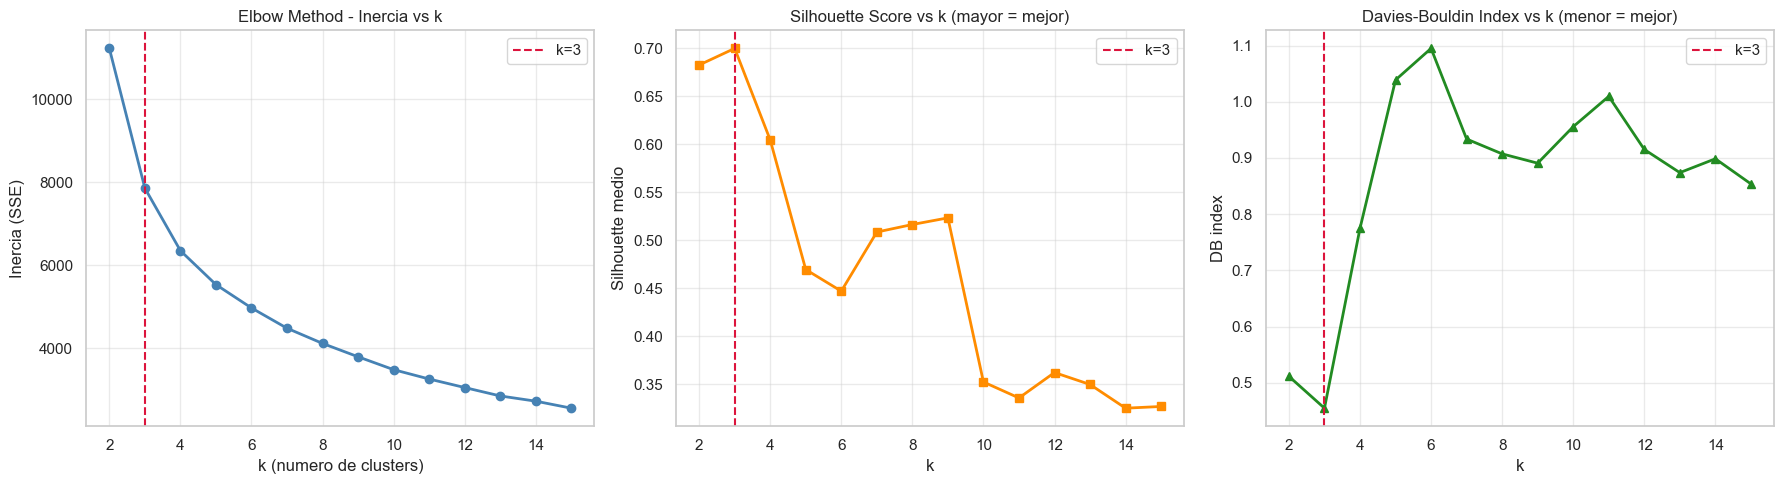


  Distribucion de fondos por cluster (K-Means, k=3):
0    1022
1    1687
2      31


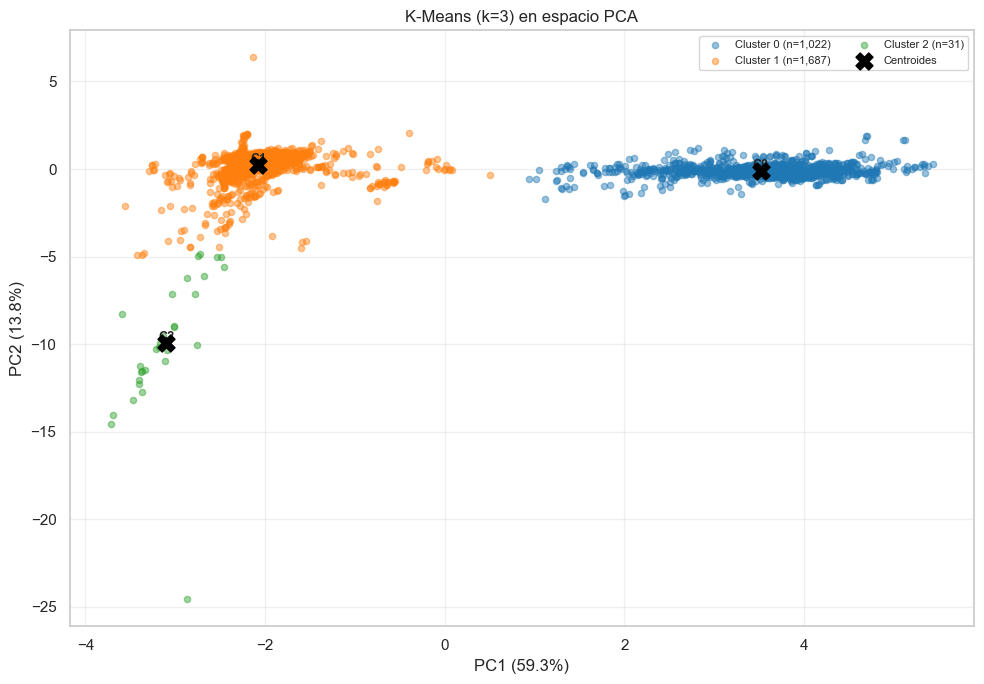

In [38]:
# =============================================================================
# 7.1 - K-Means: elbow method + silhouette score
# =============================================================================

RANDOM_STATE = 42
K_RANGE      = range(2, 16)    # k = 2 .. 15

inertias    = []
sil_scores  = []
ch_scores   = []
db_scores   = []

print("Calculando K-Means para k = 2..15 ...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE, max_iter=500)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    print(f"  k={k:2d} | inercia={km.inertia_:10.1f} | silhouette={sil_scores[-1]:.4f} | CH={ch_scores[-1]:.1f} | DB={db_scores[-1]:.4f}")

# ── Seleccion de k optimo ──────────────────────────────────────────────────────
k_opt_sil = list(K_RANGE)[np.argmax(sil_scores)]
k_opt_ch  = list(K_RANGE)[np.argmax(ch_scores)]
k_opt_db  = list(K_RANGE)[np.argmin(db_scores)]
print(f"\n  k optimo por Silhouette  : {k_opt_sil}")
print(f"  k optimo por CH          : {k_opt_ch}")
print(f"  k optimo por Davies-Bouldin: {k_opt_db}")

# Consenso: k mas frecuente entre los 3 criterios
from collections import Counter as _Counter
k_votes = _Counter([k_opt_sil, k_opt_ch, k_opt_db])
K_OPT   = k_votes.most_common(1)[0][0]
# Si no hay consenso, usar silhouette como criterio desempate
if k_votes.most_common(1)[0][1] == 1:
    K_OPT = k_opt_sil
print(f"\n  >>> K optimo seleccionado (consenso): K_OPT = {K_OPT} <<<")

# ── Grafica elbow + silhouette ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

k_list = list(K_RANGE)

# Elbow
axes[0].plot(k_list, inertias, "o-", color="steelblue", linewidth=2)
axes[0].axvline(K_OPT, color="crimson", linestyle="--", label=f"k={K_OPT}")
axes[0].set_title("Elbow Method - Inercia vs k")
axes[0].set_xlabel("k (numero de clusters)")
axes[0].set_ylabel("Inercia (SSE)")
axes[0].legend()
axes[0].grid(alpha=0.4)

# Silhouette
axes[1].plot(k_list, sil_scores, "s-", color="darkorange", linewidth=2)
axes[1].axvline(K_OPT, color="crimson", linestyle="--", label=f"k={K_OPT}")
axes[1].set_title("Silhouette Score vs k (mayor = mejor)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette medio")
axes[1].legend()
axes[1].grid(alpha=0.4)

# Davies-Bouldin
axes[2].plot(k_list, db_scores, "^-", color="forestgreen", linewidth=2)
axes[2].axvline(K_OPT, color="crimson", linestyle="--", label=f"k={K_OPT}")
axes[2].set_title("Davies-Bouldin Index vs k (menor = mejor)")
axes[2].set_xlabel("k")
axes[2].set_ylabel("DB index")
axes[2].legend()
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ── K-Means final con K_OPT ───────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_OPT, init="k-means++", n_init=20, random_state=RANDOM_STATE, max_iter=1000)
labels_km = km_final.fit_predict(X_pca)

snapshot["cluster_kmeans"] = labels_km
df_pca["cluster_kmeans"]   = labels_km

print(f"\n  Distribucion de fondos por cluster (K-Means, k={K_OPT}):")
print(pd.Series(labels_km).value_counts().sort_index().rename("n_fondos").to_string())

# Visualizacion clusters K-Means en PC1 vs PC2
fig, ax = plt.subplots(figsize=(10, 7))
palette_km = plt.cm.tab10.colors
for cl in sorted(np.unique(labels_km)):
    mask = labels_km == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[palette_km[cl % 10]], alpha=0.45, s=20,
               label=f"Cluster {cl} (n={mask.sum():,})")
# Centroides
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], c="black", s=150, marker="X",
           zorder=5, label="Centroides")
for ci, (cx, cy) in enumerate(centroids[:, :2]):
    ax.annotate(f"C{ci}", (cx, cy), fontsize=9, ha="center", va="bottom", fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"K-Means (k={K_OPT}) en espacio PCA")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 - Clustering Jerarquico Aglomerativo (HAC) con linkage Ward

**Justificacion del metodo Ward**: el criterio Ward minimiza la varianza total dentro de los clusters en cada paso de fusion, produciendo clusters compactos y de tamano similar. Es el estandar para datos financieros (Murtagh & Legendre, 2014).

**Ventaja clave frente a K-Means**: el dendrograma revela estructura jerarquica dentro de los clusters Asia: por ejemplo, puede haber un sub-grupo "Asia Small Cap" dentro del cluster "Asia-biased", informacion que K-Means ignora al asumir particiones planas.

**Protocolo**:
1. Calcular matriz de linkage Ward sobre `X_pca`
2. Visualizar dendrograma truncado (`last_p=30`) para entender la estructura global
3. Cortar el dendrograma en `k = K_OPT` clusters (mismo k que K-Means para comparabilidad)
4. Comparar particion HAC vs K-Means con el indice de Rand ajustado

Calculando linkage Ward (puede tardar 30-60s para n > 2000) ...
  Linkage completado en 0.2s. Altura maxima: 200.879


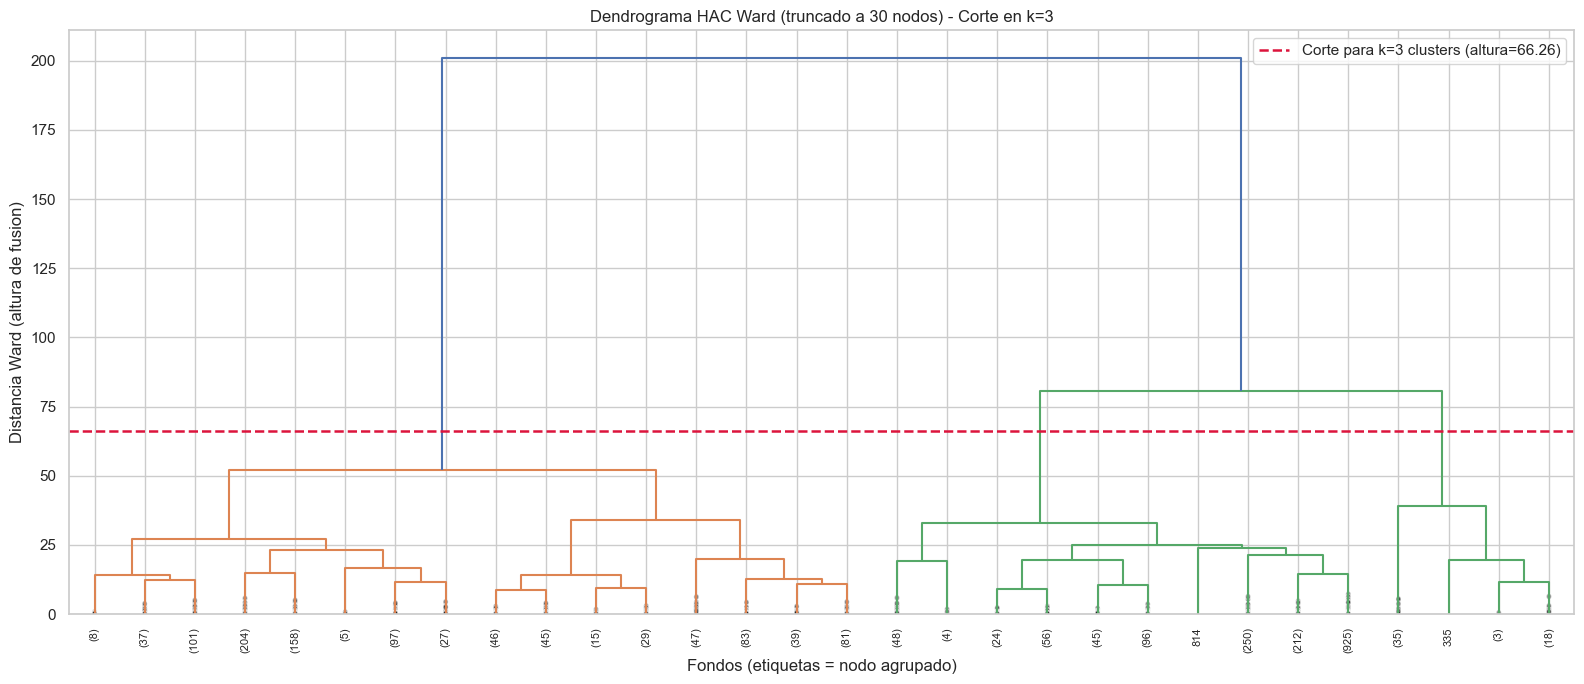


  Distribucion de fondos por cluster (HAC Ward, k=3):
0    1022
1    1661
2      57


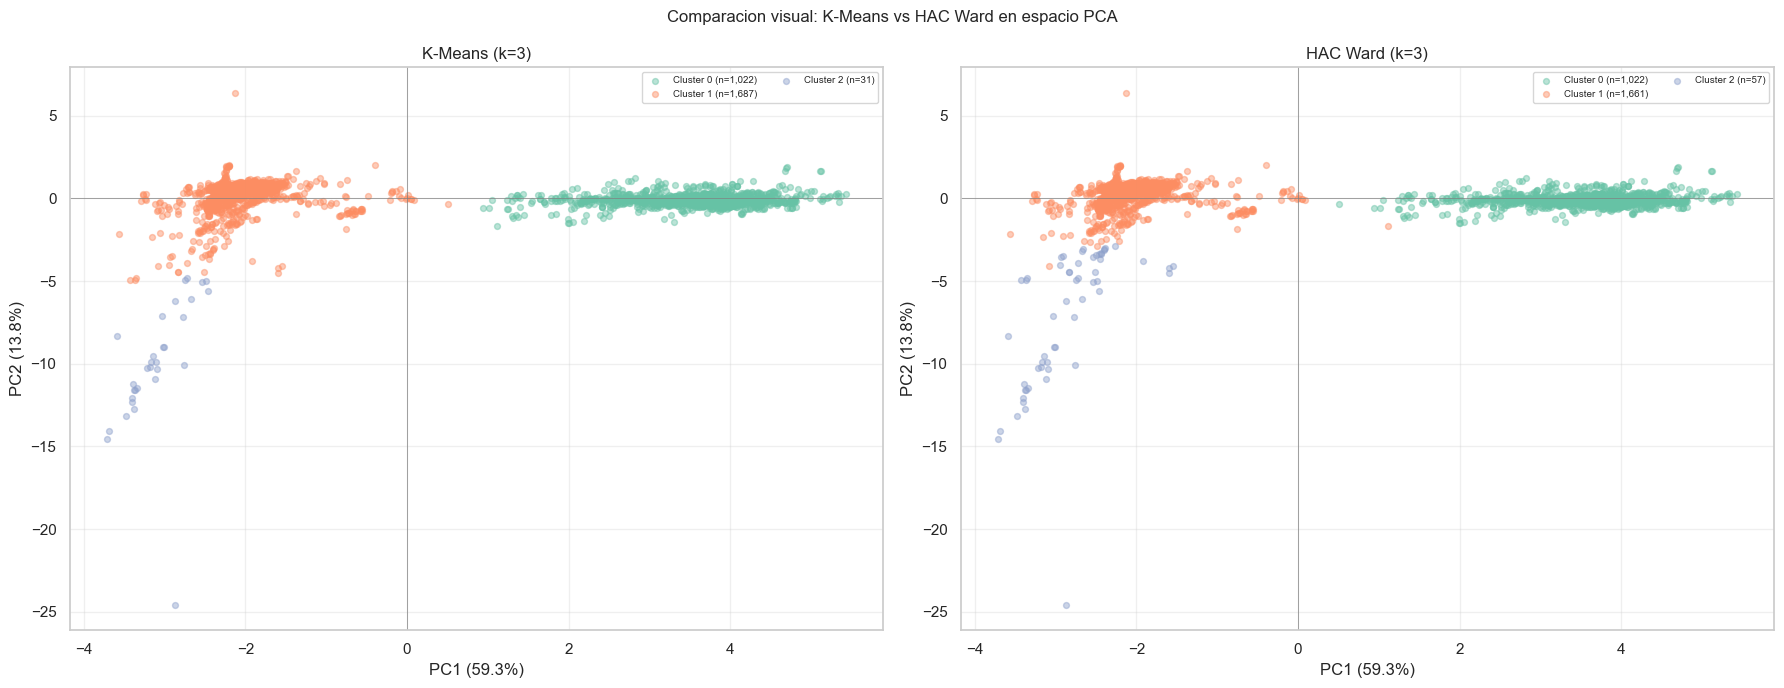


  Adjusted Rand Index (K-Means vs HAC): 0.9737
  (1.0 = particiones identicas; 0.0 = aleatorias)
  >> Alta concordancia: ambos metodos segmentan el espacio de forma similar.


In [39]:
# =============================================================================
# 7.2 - HAC Ward: dendrograma + fcluster
# =============================================================================
from sklearn.metrics import adjusted_rand_score

# ── 1. Calcular linkage Ward ──────────────────────────────────────────────────
print("Calculando linkage Ward (puede tardar 30-60s para n > 2000) ...")
import time as _time_hac
t0 = _time_hac.time()
Z = linkage(X_pca, method="ward", metric="euclidean")
t1 = _time_hac.time()
print(f"  Linkage completado en {t1-t0:.1f}s. Altura maxima: {Z[-1, 2]:.3f}")

# ── 2. Dendrograma truncado ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(
    Z,
    truncate_mode="lastp",   # Mostrar solo las ultimas p fusiones
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    ax=ax
)
# Linea de corte para K_OPT clusters
# La altura de corte se determina por el gap mas grande justo por encima de K_OPT fusiones
sorted_heights = np.sort(Z[:, 2])[::-1]
cut_height = (sorted_heights[K_OPT - 2] + sorted_heights[K_OPT - 1]) / 2
ax.axhline(y=cut_height, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Corte para k={K_OPT} clusters (altura={cut_height:.2f})")
ax.set_title(f"Dendrograma HAC Ward (truncado a 30 nodos) - Corte en k={K_OPT}")
ax.set_xlabel("Fondos (etiquetas = nodo agrupado)")
ax.set_ylabel("Distancia Ward (altura de fusion)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. fcluster: asignar labels ───────────────────────────────────────────────
labels_hac = fcluster(Z, t=K_OPT, criterion="maxclust") - 1  # 0-indexed

snapshot["cluster_hac"] = labels_hac
df_pca["cluster_hac"]   = labels_hac

print(f"\n  Distribucion de fondos por cluster (HAC Ward, k={K_OPT}):")
print(pd.Series(labels_hac).value_counts().sort_index().rename("n_fondos").to_string())

# ── 4. Visualizacion en espacio PCA ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette_cl = plt.cm.Set2.colors

for method_idx, (labels, title) in enumerate([(labels_km, f"K-Means (k={K_OPT})"),
                                               (labels_hac, f"HAC Ward (k={K_OPT})")]):
    ax = axes[method_idx]
    for cl in sorted(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[palette_cl[cl % len(palette_cl)]], alpha=0.45, s=18,
                   label=f"Cluster {cl} (n={mask.sum():,})")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)

plt.suptitle("Comparacion visual: K-Means vs HAC Ward en espacio PCA", fontsize=12)
plt.tight_layout()
plt.show()

# ── 5. Adjusted Rand Index: similitud entre particiones ──────────────────────
ari = adjusted_rand_score(labels_km, labels_hac)
print(f"\n  Adjusted Rand Index (K-Means vs HAC): {ari:.4f}")
print(f"  (1.0 = particiones identicas; 0.0 = aleatorias)")
if ari > 0.8:
    print("  >> Alta concordancia: ambos metodos segmentan el espacio de forma similar.")
elif ari > 0.5:
    print("  >> Concordancia moderada: existen diferencias en la asignacion de fondos frontera.")
else:
    print("  >> Baja concordancia: los metodos difieren significativamente en la segmentacion.")

### 7.3 - DBSCAN (exploratorio): deteccion de outliers

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) no requiere especificar k a priori y puede detectar clusters de forma arbitraria. En este contexto, su uso principal es **exploratorio**: identificar fondos que no pertenecen a ninguna estructura densa (noise points, etiqueta = -1).

**Estos "outliers"** son fondos con perfiles de inversion extremadamente atipicos, posiblemente:
- Fondos con concentracion sectorial extrema (solo semiconductores o solo HK tech)
- Fondos muy recientes sin historial significativo (a pesar del filtro previo)
- Fondos con comportamiento anomalo post-2020 (COVID distorsion)

**Nota sobre la escala**: DBSCAN es sensible al parametro epsilon. Se usa el grafico de k-distancias (ordenado) para identificar el "codo" que indica el epsilon optimo.

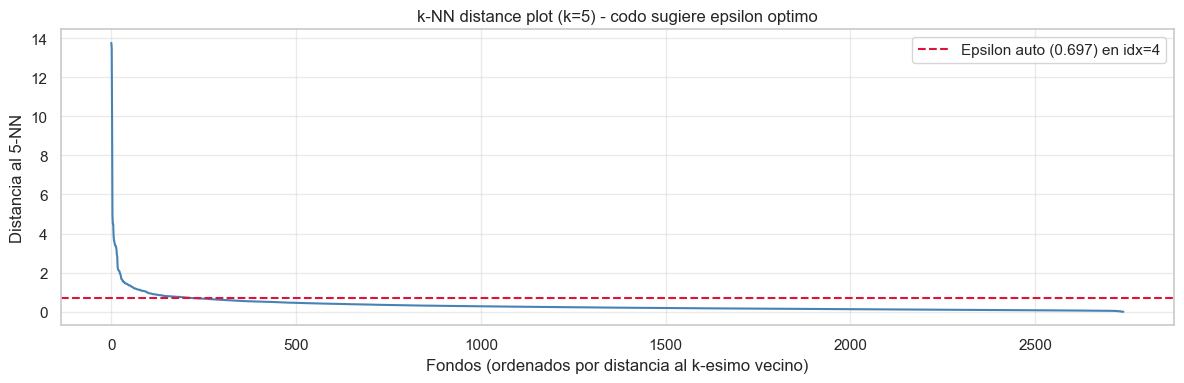

  Epsilon sugerido por k-NN codo: 0.6971

  DBSCAN resultado (eps=0.6971, min_samples=10):
    Clusters encontrados : 4
    Noise points (outliers): 214 (7.8%)

  Distribucion por cluster:
-1     214
 0     894
 1    1595
 2      22
 3      15


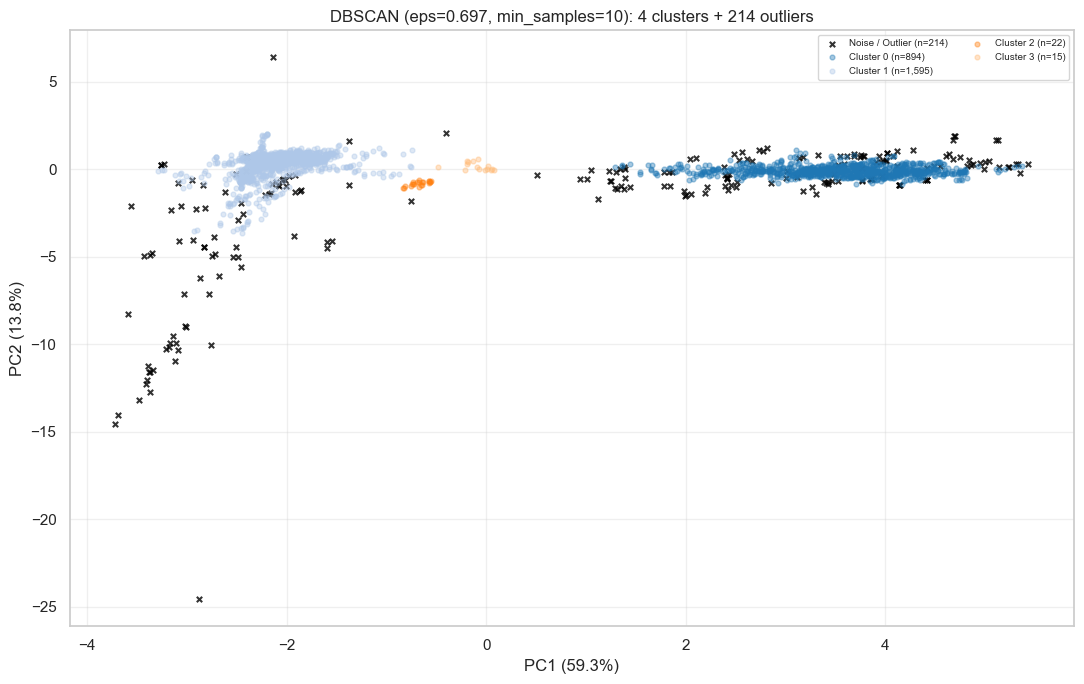


  Fondos outlier (DBSCAN noise, primeros 20): [  698   699   708  2700  2704  3768  4826 10255 10256 11186 16160 18954
 18961 19215 20243 20468 20985 23063 23069 24412]

  Estadisticas de outliers vs resto (features clave):


,mean_outlier,std_outlier,mean_normal,std_normal
alpha_adj,-0.0000,0.0003,0.0000,0.0001
beta_mkt_adj,0.5274,0.4694,0.3317,0.4455
beta_smb_adj,0.1148,0.2968,0.0958,0.1544
beta_hml_adj,0.1119,0.1737,0.0651,0.1181
beta_wml_adj,0.0616,0.1631,0.0520,0.0805
r2,0.3509,0.2755,0.2212,0.2700
cum_active_ret_1y,-0.1688,0.1878,-0.2030,0.1252
volatility_1y,0.0075,0.0077,0.0046,0.0038
upside_capture_1y,0.4100,0.4086,0.2671,0.3631
downside_capture_1y,0.4050,0.3653,0.2504,0.3494


In [54]:
# =============================================================================
# 7.3 - DBSCAN exploratorio
# =============================================================================

# ── 1. k-NN distance plot para tunear epsilon ────────────────────────────────
K_NN = 5   # Numero de vecinos para DBSCAN (min_samples = K_NN + 1 es heuristica)
nbrs = NearestNeighbors(n_neighbors=K_NN + 1, algorithm="auto").fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
# Distancia al k-esimo vecino (excluyendo el propio punto)
knn_dist = np.sort(distances[:, K_NN])[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(knn_dist, color="steelblue", linewidth=1.5)
ax.set_title(f"k-NN distance plot (k={K_NN}) - codo sugiere epsilon optimo")
ax.set_xlabel("Fondos (ordenados por distancia al k-esimo vecino)")
ax.set_ylabel(f"Distancia al {K_NN}-NN")
ax.grid(alpha=0.4)

# Detectar codo automaticamente (mayor diferencia de segunda derivada)
second_deriv = np.diff(np.diff(knn_dist))
codo_idx     = np.argmax(np.abs(second_deriv)) + 2
# En lugar del epsilon auto, usar un percentil
eps_auto = np.percentile(knn_dist, 92)   # percentil 92
ax.axhline(eps_auto, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Epsilon auto ({eps_auto:.3f}) en idx={codo_idx}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"  Epsilon sugerido por k-NN codo: {eps_auto:.4f}")

# ── 2. DBSCAN con epsilon auto ────────────────────────────────────────────────
MIN_SAMPLES = max(K_NN + 1, 10)   # Heuristica: al menos 10 fondos para ser un cluster denso
db = DBSCAN(eps=eps_auto, min_samples=MIN_SAMPLES, n_jobs=-1)
labels_db = db.fit_predict(X_pca)

n_noise    = (labels_db == -1).sum()
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

snapshot["cluster_dbscan"] = labels_db
df_pca["cluster_dbscan"]   = labels_db

print(f"\n  DBSCAN resultado (eps={eps_auto:.4f}, min_samples={MIN_SAMPLES}):")
print(f"    Clusters encontrados : {n_clusters}")
print(f"    Noise points (outliers): {n_noise:,} ({100*n_noise/len(labels_db):.1f}%)")
print(f"\n  Distribucion por cluster:")
print(pd.Series(labels_db).value_counts().sort_index().rename("n_fondos").to_string())

# ── 3. Visualizacion DBSCAN ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
unique_labels = sorted(set(labels_db))
colors_db = plt.cm.tab20.colors

for cl in unique_labels:
    mask  = labels_db == cl
    color = "black" if cl == -1 else colors_db[cl % 20]
    alpha = 0.8 if cl == -1 else 0.4
    size  = 15  if cl == -1 else 12
    lbl   = f"Noise / Outlier (n={mask.sum():,})" if cl == -1 else f"Cluster {cl} (n={mask.sum():,})"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], alpha=alpha, s=size, label=lbl, marker="x" if cl == -1 else "o")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"DBSCAN (eps={eps_auto:.3f}, min_samples={MIN_SAMPLES}): {n_clusters} clusters + {n_noise} outliers")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. Perfil de outliers ─────────────────────────────────────────────────────
if n_noise > 0:
    outlier_ids = snapshot[labels_db == -1]["fund_id"].values
    print(f"\n  Fondos outlier (DBSCAN noise, primeros 20): {outlier_ids[:20]}")
    print(f"\n  Estadisticas de outliers vs resto (features clave):")
    df_outlier = snapshot[labels_db == -1][FEATURES_PCA].describe().T[["mean", "std"]]
    df_normal  = snapshot[labels_db != -1][FEATURES_PCA].describe().T[["mean", "std"]]
    df_compare = df_outlier.rename(columns={"mean": "mean_outlier", "std": "std_outlier"}).join(
                 df_normal.rename(columns={"mean": "mean_normal", "std": "std_normal"}))
    display(df_compare.round(4))
else:
    print("  No se detectaron noise points con este epsilon.")

### 7.4 - Tabla comparativa de metricas de clustering

Para seleccionar el mejor metodo de clustering utilizamos tres metricas internas (no requieren ground-truth externo):

| Metrica | Formula intuitiva | Optimo |
|---|---|---|
| **Silhouette** | (b - a) / max(a, b) donde a=dist intra, b=dist al cluster mas cercano | Mayor (cerca de +1) |
| **Calinski-Harabasz (CH)** | ratio entre varianza inter-cluster e intra-cluster | Mayor |
| **Davies-Bouldin (DB)** | similitud media entre cada cluster y su vecino mas similar | Menor (cerca de 0) |

El metodo ganador es el que domina en al menos 2 de las 3 metricas. En caso de empate, el Silhouette tiene prioridad por ser el mas interpretable y citado en la literatura de clustering financiero.

In [55]:
# =============================================================================
# 7.4 - Comparativa de metricas: K-Means vs HAC vs DBSCAN
# =============================================================================

def compute_metrics(X, labels, method_name):
    """Calcula las 3 metricas de clustering. DBSCAN excluye noise points (-1)."""
    # Para DBSCAN: excluir puntos con label -1 (noise)
    valid_mask = labels != -1
    if valid_mask.sum() < 2 or len(np.unique(labels[valid_mask])) < 2:
        return {"Metodo": method_name, "k": "auto", "Silhouette": np.nan,
                "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan, "Noise%": "N/A"}
    X_v = X[valid_mask]
    l_v = labels[valid_mask]
    n_noise = (~valid_mask).sum()
    noise_pct = f"{100 * n_noise / len(labels):.1f}%"
    return {
        "Metodo"            : method_name,
        "k"                 : len(np.unique(l_v)),
        "Silhouette"        : round(silhouette_score(X_v, l_v), 4),
        "Calinski-Harabasz" : round(calinski_harabasz_score(X_v, l_v), 1),
        "Davies-Bouldin"    : round(davies_bouldin_score(X_v, l_v), 4),
        "Noise%"            : noise_pct if method_name == "DBSCAN" else "0.0%",
    }

results_comp = [
    compute_metrics(X_pca, labels_km,  f"K-Means (k={K_OPT})"),
    compute_metrics(X_pca, labels_hac, f"HAC Ward (k={K_OPT})"),
    compute_metrics(X_pca, labels_db,  f"DBSCAN (auto)"),
]
df_comp = pd.DataFrame(results_comp)

print("=" * 75)
print("7.4 - COMPARATIVA DE METRICAS DE CLUSTERING")
print("=" * 75)
display(df_comp.set_index("Metodo"))

# ── Determinar metodo ganador ─────────────────────────────────────────────────
rows_validos = df_comp.dropna(subset=["Silhouette"])
if len(rows_validos) > 0:
    wins = {row["Metodo"]: 0 for _, row in rows_validos.iterrows()}
    if not rows_validos["Silhouette"].isna().all():
        best_sil = rows_validos.loc[rows_validos["Silhouette"].idxmax(), "Metodo"]
        wins[best_sil] += 1
    if not rows_validos["Calinski-Harabasz"].isna().all():
        best_ch  = rows_validos.loc[rows_validos["Calinski-Harabasz"].idxmax(), "Metodo"]
        wins[best_ch] += 1
    if not rows_validos["Davies-Bouldin"].isna().all():
        best_db  = rows_validos.loc[rows_validos["Davies-Bouldin"].idxmin(), "Metodo"]
        wins[best_db] += 1

    print(f"\n  Victorias por metodo: {wins}")
    BEST_METHOD_LABEL = max(wins, key=wins.get)
    # Determinar que etiqueta de cluster usar para el fondo de fondos
    if "K-Means" in BEST_METHOD_LABEL:
        labels_best  = labels_km
        cluster_col  = "cluster_kmeans"
        best_name    = "K-Means"
    elif "HAC" in BEST_METHOD_LABEL:
        labels_best  = labels_hac
        cluster_col  = "cluster_hac"
        best_name    = "HAC Ward"
    else:
        # DBSCAN como ganador: reasignar noise points al cluster mas cercano via K-Means
        print("  >> DBSCAN ganador: reasignando noise points via K-Means para el fondo de fondos")
        km_backup   = KMeans(n_clusters=max(n_clusters, 2), init="k-means++", n_init=10, random_state=42)
        labels_best = km_backup.fit_predict(X_pca)
        cluster_col = "cluster_kmeans"
        best_name   = "K-Means (fallback DBSCAN)"

    print(f"\n  >>> Metodo seleccionado para Fondo de Fondos: {BEST_METHOD_LABEL} <<<")
    print(f"  >>> Variable de cluster: {cluster_col} <<<")
else:
    # Fallback: usar K-Means
    labels_best = labels_km
    cluster_col = "cluster_kmeans"
    best_name   = "K-Means (default)"
    print("  >> Fallback a K-Means por datos insuficientes en comparativa.")

# ── Guardar snapshot final con todas las etiquetas ───────────────────────────
OUT_CLUSTERED = Path("data") / "features" / "snapshot_clustered.parquet"
snapshot.to_parquet(OUT_CLUSTERED, index=False)
print(f"\n  Snapshot con clusters guardado: {OUT_CLUSTERED}")
print(f"  Columnas de clustering: {[c for c in snapshot.columns if 'cluster' in c]}")

7.4 - COMPARATIVA DE METRICAS DE CLUSTERING


,k,Silhouette,Calinski-Harabasz,Davies-Bouldin,Noise%
Metodo,,,,,
K-Means (k=3),3,0.6998,4101.5,0.4548,0.0%
HAC Ward (k=3),3,0.6992,4008.3,0.6064,0.0%
DBSCAN (auto),4,0.5333,4122.3,0.4796,0.0%



  Victorias por metodo: {'K-Means (k=3)': 2, 'HAC Ward (k=3)': 0, 'DBSCAN (auto)': 1}

  >>> Metodo seleccionado para Fondo de Fondos: K-Means (k=3) <<<
  >>> Variable de cluster: cluster_kmeans <<<

  Snapshot con clusters guardado: data\features\snapshot_clustered.parquet
  Columnas de clustering: ['cluster_kmeans', 'cluster_hac', 'cluster_dbscan', 'cluster_best', 'cluster_name', 'cluster_tipo']


### 7.5 - Profiling e interpretacion de clusters

El profiling convierte los clusters numericos (0, 1, 2, ...) en **categorias financieras con nombre**. Este paso es esencial para la construccion del fondo de fondos: necesitamos saber si un cluster representa "Asia Pure-Play", "Asia Small Cap", "Asia Value", "Diversificador Global", etc.

**Metodologia de naming**:
1. Tabla de medias de las 13 features por cluster
2. Radar chart (spider plot) para visualizar el perfil multidimensional de cada cluster
3. Cross-tabulation cluster x {asia_biased / diversified_biased}
4. Asignacion de nombre financiero basado en la combinacion de:
   - `beta_mkt_adj` alto → exposicion fuerte al mercado Asia
   - `beta_smb_adj` alto → sesgo small cap
   - `beta_hml_adj` alto → sesgo value; negativo → sesgo growth
   - `alpha_adj` alto → skill del gestor / alpha generation
   - `volatility_1y` alto → fondo de alta volatilidad
   - `r2` bajo → poca explicacion por factores Asia (diversificador)

7.5 - PERFIL MEDIO DE CADA CLUSTER (K-Means)


,alpha_adj,beta_mkt_adj,beta_smb_adj,beta_hml_adj,beta_wml_adj,r2,cum_active_ret_1y,volatility_1y,upside_capture_1y,downside_capture_1y,skewness_1y,kurtosis_1y,t_active_ret_1y
cluster_best,,,,,,,,,,,,,
0,0.0000,0.9229,0.2313,0.1910,0.1164,0.5806,-0.0462,0.0093,0.7407,0.6952,-0.2873,1.4299,-0.3688
1,-0.0000,0.0043,0.0181,-0.0040,0.0150,0.0236,-0.2906,0.0020,0.0044,0.0048,-0.3285,4.1621,-1.9670
2,-0.0001,0.0112,-0.0095,0.0041,0.0117,0.0172,-0.3666,0.0050,-0.0678,0.0179,-9.3797,124.3267,-2.1014



Cross-tabulation: cluster vs clasificacion Asia/Diversificado:


asia_biased
cluster_best


  Cluster 0 → 'Asia Puro Alta Volatilidad'
  Cluster 1 → 'Diversificador Global Activo'
  Cluster 2 → 'Diversificador Global Mixto'


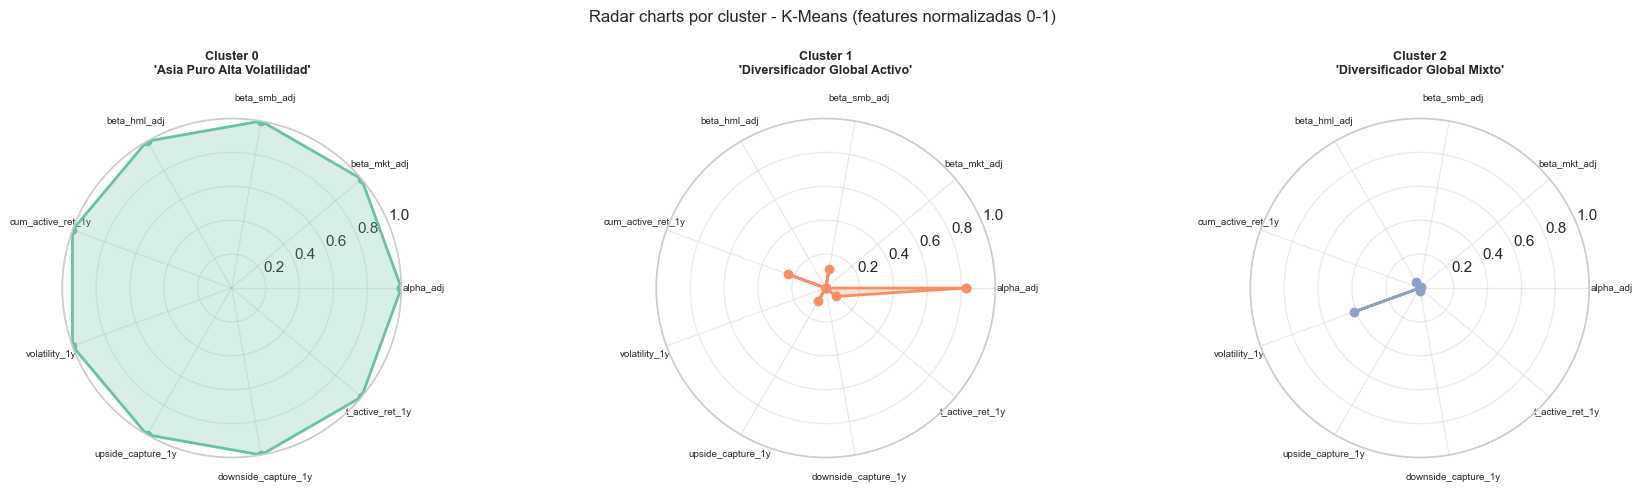


7.5 - RESUMEN EJECUTIVO: NAMING FINANCIERO DE CLUSTERS

  Cluster 0: 'Asia Puro Alta Volatilidad'
    n_fondos=1022 | asia_biased=1021 | diversified=   1
    alpha_adj=0.0000 | beta_mkt_adj=0.9229

  Cluster 1: 'Diversificador Global Activo'
    n_fondos=1687 | asia_biased=   1 | diversified=1686
    alpha_adj=-0.0000 | beta_mkt_adj=0.0043

  Cluster 2: 'Diversificador Global Mixto'
    n_fondos=  31 | asia_biased=   0 | diversified=  31
    alpha_adj=-0.0001 | beta_mkt_adj=0.0112

  Snapshot con nombres de cluster guardado: data\features\snapshot_named_clusters.parquet


In [60]:
# =============================================================================
# 7.5 - Profiling de clusters: tabla de medias + radar charts + naming
# =============================================================================

# Usar etiquetas del mejor metodo
snapshot["cluster_best"] = snapshot[cluster_col].values
labels_best_arr = snapshot["cluster_best"].values
unique_clusters = sorted(snapshot["cluster_best"].unique())

# ── 1. Tabla de medias por cluster ───────────────────────────────────────────
df_profile = snapshot.groupby("cluster_best")[FEATURES_PCA].mean()
df_profile_norm = (df_profile - df_profile.min()) / (df_profile.max() - df_profile.min() + 1e-10)

print("=" * 80)
print(f"7.5 - PERFIL MEDIO DE CADA CLUSTER ({best_name})")
print("=" * 80)
display(df_profile.round(4))

# ── 2. Cross-tabulation: cluster x clasificacion Asia/Diversificado ──────────
print("\nCross-tabulation: cluster vs clasificacion Asia/Diversificado:")
cross_tab = pd.crosstab(
    snapshot["cluster_best"],
    snapshot["asia_biased"].map({True: "Asia-biased", False: "Diversified"}),
    margins=True
)
display(cross_tab)

# Helpers para diferenciar subtipos diversificadores
div_mask = df_profile["r2"] < 0.25
if div_mask.any():
    div_alpha_med = df_profile.loc[div_mask, "alpha_adj"].median()
    div_tir_med = df_profile.loc[div_mask, "t_active_ret_1y"].median()
    div_vol_med = df_profile.loc[div_mask, "volatility_1y"].median()
    div_beta_med = df_profile.loc[div_mask, "beta_mkt_adj"].median()
else:
    div_alpha_med = df_profile["alpha_adj"].median()
    div_tir_med = df_profile["t_active_ret_1y"].median()
    div_vol_med = df_profile["volatility_1y"].median()
    div_beta_med = df_profile["beta_mkt_adj"].median()

# ── 3. Naming financiero automatico ──────────────────────────────────────────
def nombre_cluster(row_norm, row_raw):
    """Asigna nombre financiero basado en perfil de features."""
    beta_mkt = row_raw["beta_mkt_adj"]
    beta_smb = row_raw["beta_smb_adj"]
    beta_hml = row_raw["beta_hml_adj"]
    beta_wml = row_raw["beta_wml_adj"]
    alpha = row_raw["alpha_adj"]
    vol = row_raw["volatility_1y"]
    r2 = row_raw["r2"]
    up_cap = row_raw["upside_capture_1y"]
    dn_cap = row_raw["downside_capture_1y"]
    t_ir = row_raw["t_active_ret_1y"]

    # 1) Diversificadores: separar en subtipos para evitar nombres duplicados
    if r2 < 0.25:
        if (alpha >= div_alpha_med) and (t_ir >= div_tir_med):
            return "Diversificador Global Activo"
        if (beta_mkt <= min(div_beta_med, 0.03)) and (vol <= div_vol_med):
            return "Diversificador Global Defensivo"
        return "Diversificador Global Mixto"

    # 2) Clusters Asia
    if beta_mkt > 0.9 and vol > df_profile["volatility_1y"].median() * 1.2:
        return "Asia Puro Alta Volatilidad"
    if beta_smb > df_profile["beta_smb_adj"].median() * 1.2:
        if beta_hml < 0:
            return "Asia Small Cap Growth"
        return "Asia Small Cap"
    if beta_hml > df_profile["beta_hml_adj"].median() * 1.2:
        return "Asia Value"
    if beta_wml > df_profile["beta_wml_adj"].median() * 1.2 or t_ir > 1.0:
        return "Asia Momentum / Alpha"
    if up_cap > 1.0 and dn_cap < 0.9:
        return "Asia Pure-Play"
    if alpha > df_profile["alpha_adj"].median():
        return "Asia Activo (Alpha Generation)"
    return "Asia Diversificado"

cluster_names = {}
for cl in unique_clusters:
    row_raw = df_profile.loc[cl]
    row_norm = df_profile_norm.loc[cl]
    cluster_names[cl] = nombre_cluster(row_norm, row_raw)
    print(f"  Cluster {cl} → '{cluster_names[cl]}'")

snapshot["cluster_name"] = snapshot["cluster_best"].map(cluster_names)

# ── 4. Radar charts (spider plots) ───────────────────────────────────────────
# Normalizar features para radar (0-1)
RADAR_FEATURES = ["alpha_adj", "beta_mkt_adj", "beta_smb_adj", "beta_hml_adj",
                  "cum_active_ret_1y", "volatility_1y", "upside_capture_1y",
                  "downside_capture_1y", "t_active_ret_1y"]
radar_avail = [f for f in RADAR_FEATURES if f in df_profile.columns]

df_radar = df_profile[radar_avail].copy()
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min() + 1e-10)

N_FEAT = len(radar_avail)
angles = np.linspace(0, 2 * np.pi, N_FEAT, endpoint=False).tolist()
angles += angles[:1]   # Cerrar el circulo
feat_lbls = radar_avail + [radar_avail[0]]

n_cl = len(unique_clusters)
n_cols_rad = min(3, n_cl)
n_rows_rad = (n_cl + n_cols_rad - 1) // n_cols_rad
fig, axes_rad = plt.subplots(
    n_rows_rad, n_cols_rad,
    figsize=(6 * n_cols_rad, 5 * n_rows_rad),
    subplot_kw=dict(polar=True)
)
axes_rad_flat = np.array(axes_rad).flat

palette_rad = plt.cm.Set2.colors

for ci, cl in enumerate(unique_clusters):
    ax = axes_rad_flat[ci]
    values = df_radar_norm.loc[cl, radar_avail].tolist()
    values += values[:1]   # Cerrar

    color = palette_rad[ci % len(palette_rad)]
    ax.plot(angles, values, "o-", linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feat_lbls[:-1], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {cl}\n'{cluster_names[cl]}'", fontsize=9, pad=15, fontweight="bold")
    ax.grid(True, alpha=0.4)

for ci in range(n_cl, n_rows_rad * n_cols_rad):
    axes_rad_flat[ci].set_visible(False)

plt.suptitle(f"Radar charts por cluster - {best_name} (features normalizadas 0-1)", fontsize=12)
plt.tight_layout()
plt.show()

# ── 5. Resumen ejecutivo ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("7.5 - RESUMEN EJECUTIVO: NAMING FINANCIERO DE CLUSTERS")
print("=" * 70)
for cl in unique_clusters:
    n_fonds = (snapshot["cluster_best"] == cl).sum()
    n_asia = ((snapshot["cluster_best"] == cl) & snapshot["asia_biased"]).sum()
    n_div = ((snapshot["cluster_best"] == cl) & snapshot["diversified_biased"]).sum()
    alpha_med = df_profile.loc[cl, "alpha_adj"]
    beta_med = df_profile.loc[cl, "beta_mkt_adj"]
    print(f"\n  Cluster {cl}: '{cluster_names[cl]}'")
    print(f"    n_fondos={n_fonds:4d} | asia_biased={n_asia:4d} | diversified={n_div:4d}")
    print(f"    alpha_adj={alpha_med:.4f} | beta_mkt_adj={beta_med:.4f}")

# Guardar snapshot con nombres de cluster
OUT_NAMED = Path("data") / "features" / "snapshot_named_clusters.parquet"
snapshot.to_parquet(OUT_NAMED, index=False)
print(f"\n  Snapshot con nombres de cluster guardado: {OUT_NAMED}")

## 8. Fondo de Fondos

Con los clusters identificados y nombrados, procedemos a construir el portfolio final. Objetivo: seleccionar fondos de los clusters para crear un portfolio con sesgo hacia Asia ex-Japan (70%) complementado con fondos diversificadores (30%).

Reglas de construccion:
1. Clasificar clusters como Asia o Diversificador segun r2 medio y nombre del cluster
2. Asignar 70% a clusters Asia y 30% a Diversificadores
3. Dentro de cada cluster, seleccionar los mejores fondos por score = alpha_adj * 0.5 + t_active_ret_1y * 0.5
4. Cap maximo del 5% por fondo

### 8.1 - Seleccion de fondos por cluster

La seleccion de fondos candidatos sigue tres criterios:
1. **Clasificacion del cluster** (Asia vs Diversificador): basado en el r2 medio (alto r2 = explicado por factores Asia = cluster Asia)
2. **Ranking por score compuesto** dentro de cada cluster: `score = 0.5 * zscore(alpha_adj) + 0.5 * zscore(t_active_ret_1y)`
3. **Seleccion de los top N fondos por cluster**: suficientes para alcanzar el cap del 5% por fondo

Justificacion del score compuesto:
- `alpha_adj`: mide el rendimiento superior ajustado por factores de riesgo y por significancia estadistica (t-shrinkage). Fondos con alpha alto y significativo tienen evidencia de skill del gestor.
- `t_active_ret_1y`: es el Information Ratio t-stat, mide la consistencia del retorno activo. Un IR alto indica que el fondo genera alpha de forma consistente, no por suerte.

In [67]:
# =============================================================================
# 8.1 - Seleccion de fondos candidatos por cluster
# =============================================================================

PESO_ASIA      = 0.70   # 70% del portfolio en clusters Asia
PESO_DIV       = 0.30   # 30% en clusters Diversificadores
CAP_FONDO      = 0.05   # Max 5% por fondo

# ── 1. Clasificar clusters: Asia vs Diversificador ───────────────────────────
# Criterio: r2 medio > 0.35 → cluster Asia; <= 0.35 → Diversificador
R2_THRESHOLD = 0.35
cluster_r2_mean = snapshot.groupby("cluster_best")["r2"].mean()

cluster_tipo = {}
for cl in unique_clusters:
    nombre = cluster_names[cl]
    r2_med = cluster_r2_mean[cl]
    if "Diversificador" in nombre or r2_med <= R2_THRESHOLD:
        cluster_tipo[cl] = "Diversificador"
    else:
        cluster_tipo[cl] = "Asia"

snapshot["cluster_tipo"] = snapshot["cluster_best"].map(cluster_tipo)

print("=" * 65)
print("8.1 - CLASIFICACION DE CLUSTERS")
print("=" * 65)
for cl in unique_clusters:
    n = (snapshot["cluster_best"] == cl).sum()
    r2m = cluster_r2_mean[cl]
    print(f"  Cluster {cl}: '{cluster_names[cl]}' | tipo={cluster_tipo[cl]} | r2_medio={r2m:.3f} | n={n}")

n_asia_cl = sum(1 for t in cluster_tipo.values() if t == "Asia")
n_div_cl  = sum(1 for t in cluster_tipo.values() if t == "Diversificador")
print(f"\n  Clusters Asia       : {n_asia_cl}")
print(f"  Clusters Diversific.: {n_div_cl}")

# ── 2. Score compuesto por fondo ─────────────────────────────────────────────
from scipy import stats as _sp_stats

snapshot["z_alpha_adj"]     = _sp_stats.zscore(snapshot["alpha_adj"].fillna(0))
snapshot["z_t_active_ret"]  = _sp_stats.zscore(snapshot["t_active_ret_1y"].fillna(0))
snapshot["score_compuesto"] = 0.5 * snapshot["z_alpha_adj"] + 0.5 * snapshot["z_t_active_ret"]

# Excluir fondos problemáticos por calidad de dato antes del ranking
BLACKLIST_FUNDS = {"62589"}
snapshot_filtrado = snapshot.copy()
snapshot_filtrado["fund_id"] = snapshot_filtrado["fund_id"].astype(str)
snapshot_filtrado = snapshot_filtrado[~snapshot_filtrado["fund_id"].isin(BLACKLIST_FUNDS)].copy()

# ── 3. Seleccionar top fondos por cluster (minimo para cubrir 5% cap) ────────
# Con cap 5%: max fondos por cluster Asia = PESO_ASIA / CAP_FONDO = 14 fondos
# Tomamos top 10 por cluster para diversificar dentro del cluster
TOP_N_PER_CLUSTER = max(5, int(CAP_FONDO ** -1))  # 20 fondos maximo por cluster
print(f"\n  Top {TOP_N_PER_CLUSTER} fondos seleccionados por cluster")

candidatos_list = []
for cl in unique_clusters:
    mask = snapshot_filtrado["cluster_best"] == cl
    sub  = snapshot_filtrado[mask].copy()
    top_n = sub.nlargest(min(TOP_N_PER_CLUSTER, len(sub)), "score_compuesto")
    candidatos_list.append(top_n)

df_candidatos = pd.concat(candidatos_list, ignore_index=True)

print(f"\n  Total fondos candidatos: {len(df_candidatos)}")
print(f"  Fondos candidatos Asia : {(df_candidatos['cluster_tipo'] == 'Asia').sum()}")
print(f"  Fondos candidatos Div  : {(df_candidatos['cluster_tipo'] == 'Diversificador').sum()}")

# Vista previa de los mejores fondos
print("\n  Top 15 fondos por score compuesto:")
display(df_candidatos.nlargest(15, "score_compuesto")[
    ["fund_id", "cluster_best", "cluster_name", "cluster_tipo",
     "alpha_adj", "t_active_ret_1y", "score_compuesto", "r2", "beta_mkt_adj"]
].round(4))

8.1 - CLASIFICACION DE CLUSTERS
  Cluster 0: 'Asia Puro Alta Volatilidad' | tipo=Asia | r2_medio=0.581 | n=1022
  Cluster 1: 'Diversificador Global Activo' | tipo=Diversificador | r2_medio=0.024 | n=1687
  Cluster 2: 'Diversificador Global Mixto' | tipo=Diversificador | r2_medio=0.017 | n=31

  Clusters Asia       : 1
  Clusters Diversific.: 2

  Top 20 fondos seleccionados por cluster

  Total fondos candidatos: 60
  Fondos candidatos Asia : 20
  Fondos candidatos Div  : 40

  Top 15 fondos por score compuesto:


,fund_id,cluster_best,cluster_name,cluster_tipo,alpha_adj,t_active_ret_1y,score_compuesto,r2,beta_mkt_adj
0,101743,0,Asia Puro Alta Volatilidad,Asia,0.0006,0.3941,4.4318,0.5630,0.8107
1,102347,0,Asia Puro Alta Volatilidad,Asia,0.0006,0.3843,4.3840,0.5631,0.8106
2,163536,0,Asia Puro Alta Volatilidad,Asia,0.0006,0.3017,4.2683,0.6062,0.8090
3,163535,0,Asia Puro Alta Volatilidad,Asia,0.0006,0.2853,4.2061,0.6065,0.8098
4,104011,0,Asia Puro Alta Volatilidad,Asia,0.0005,0.3397,4.0426,0.5691,0.8049
20,174133,1,Diversificador Global Activo,Diversificador,0.0005,-0.6201,3.3485,0.0281,-0.0517
5,149296,0,Asia Puro Alta Volatilidad,Asia,0.0003,0.4460,2.7467,0.7003,0.8932
6,248157,0,Asia Puro Alta Volatilidad,Asia,0.0003,0.5150,2.6998,0.6268,0.8806
7,279980,0,Asia Puro Alta Volatilidad,Asia,0.0003,0.2311,2.5521,0.5542,0.8815
8,157661,0,Asia Puro Alta Volatilidad,Asia,0.0003,0.3270,2.5054,0.5339,0.8414


### 8.2 - Construccion de pesos del portfolio

La asignacion de pesos sigue una logica de dos niveles:

**Nivel 1 - Asignacion entre tipos de cluster**:
- 70% total para clusters tipo "Asia"
- 30% total para clusters tipo "Diversificador"
- Si solo hay clusters de un tipo, se ajusta el 100% a ese tipo

**Nivel 2 - Asignacion dentro de cada cluster**:
- Ponderacion proporcional al score compuesto (alpha_adj + IR) → fondos con mayor skill reciben mayor peso
- Aplicar cap del 5% por fondo: si el peso calculado excede el 5%, se trunca y el exceso se redistribuye proporcionalmente entre los fondos restantes del mismo cluster

Este enfoque es preferible al equal-weight porque incorpora informacion sobre la calidad del gestor, manteniendo la diversificacion mediante el cap del 5% por fondo y el objetivo 70/30 entre tipos de cluster.

In [68]:
# =============================================================================
# 8.2 - Construccion de pesos del portfolio con caps
# =============================================================================

def apply_cap_redistribute(weights_series, cap):
    """
    Aplica un cap a cada peso y redistribuye el exceso proporcionalmente.
    Itera hasta convergencia.
    """
    w = weights_series.copy()
    for _ in range(50):   # max 50 iteraciones
        over   = w[w > cap]
        if len(over) == 0:
            break
        exceso = (w - cap).clip(lower=0).sum()
        w      = w.clip(upper=cap)
        # Redistribuir exceso entre fondos que no han llegado al cap
        under_mask = w < cap
        if under_mask.sum() == 0:
            break
        w[under_mask] += exceso * (w[under_mask] / w[under_mask].sum())
    return w / w.sum()   # renormalizar

# ── 1. Pesos dentro de cada cluster (proporcionales al score compuesto) ──────
# Asegurarse de que los scores sean positivos para usar como pesos proporcionales
df_candidatos["score_pos"] = (df_candidatos["score_compuesto"] - df_candidatos["score_compuesto"].min() + 0.01)

cluster_weights_raw = {}
for cl in unique_clusters:
    sub = df_candidatos[df_candidatos["cluster_best"] == cl].copy()
    if len(sub) == 0:
        continue
    raw_w = sub["score_pos"] / sub["score_pos"].sum()
    raw_w.index = sub["fund_id"]
    cluster_weights_raw[cl] = raw_w

# ── 2. Asignar presupuesto de peso por tipo de cluster ───────────────────────
clusters_asia = [cl for cl in unique_clusters if cluster_tipo[cl] == "Asia"]
clusters_div  = [cl for cl in unique_clusters if cluster_tipo[cl] == "Diversificador"]

# Ajuste si no hay suficientes clusters de un tipo
if len(clusters_asia) == 0:
    peso_asia_total = 0.0
    peso_div_total  = 1.0
elif len(clusters_div) == 0:
    peso_asia_total = 1.0
    peso_div_total  = 0.0
else:
    peso_asia_total = PESO_ASIA
    peso_div_total  = PESO_DIV

# Presupuesto por cluster (igual entre clusters del mismo tipo, objetivo 70/30)
presupuesto_cl = {}
if len(clusters_asia) > 0:
    peso_por_cl_asia = peso_asia_total / len(clusters_asia)
    for cl in clusters_asia:
        presupuesto_cl[cl] = peso_por_cl_asia
if len(clusters_div) > 0:
    peso_por_cl_div = peso_div_total / len(clusters_div)
    for cl in clusters_div:
        presupuesto_cl[cl] = peso_por_cl_div

# Renormalizar presupuestos para que sumen 1
total_presupuesto = sum(presupuesto_cl.values())
presupuesto_cl = {cl: p / total_presupuesto for cl, p in presupuesto_cl.items()}

print("Presupuesto por cluster (asignacion objetivo 70/30, antes de cap por fondo):")
for cl, p in presupuesto_cl.items():
    print(f"  Cluster {cl} ({cluster_names[cl]}, {cluster_tipo[cl]}): {p*100:.2f}%")

# ── 3. Calcular peso final por fondo con cap 5% ──────────────────────────────
portfolio_records = []
for cl in unique_clusters:
    if cl not in cluster_weights_raw or cl not in presupuesto_cl:
        continue
    raw_w     = cluster_weights_raw[cl]           # Pesos relativos dentro del cluster
    budget_cl = presupuesto_cl[cl]                # Presupuesto del cluster (fraccion del total)
    abs_w     = raw_w * budget_cl                 # Pesos absolutos en el portfolio

    # Aplicar cap 5% por fondo
    abs_w_capped = apply_cap_redistribute(abs_w, CAP_FONDO)
    abs_w_final  = abs_w_capped * budget_cl       # Escalar de vuelta al presupuesto del cluster

    sub = df_candidatos[df_candidatos["cluster_best"] == cl].set_index("fund_id")
    for fid, w in abs_w_final.items():
        if fid not in sub.index:
            continue
        row = sub.loc[fid]
        portfolio_records.append({
            "fund_id"        : fid,
            "cluster"        : cl,
            "cluster_name"   : cluster_names[cl],
            "cluster_tipo"   : cluster_tipo[cl],
            "peso_pct"       : round(w * 100, 4),
            "alpha_adj"      : round(row["alpha_adj"], 5),
            "beta_mkt_adj"   : round(row["beta_mkt_adj"], 4),
            "t_active_ret_1y": round(row["t_active_ret_1y"], 4),
            "r2"             : round(row["r2"], 4),
            "score_compuesto": round(row["score_compuesto"], 4),
            "asia_biased"    : bool(row["asia_biased"]),
        })

df_portfolio = pd.DataFrame(portfolio_records).sort_values("peso_pct", ascending=False).reset_index(drop=True)

# Renormalizar para que los pesos sumen exactamente 100%
df_portfolio["peso_pct"] = df_portfolio["peso_pct"] / df_portfolio["peso_pct"].sum() * 100

# ── 4. Resumen del portfolio ──────────────────────────────────────────────────
print("\n" + "=" * 75)
print("8.2 - PORTFOLIO FINAL DEL FONDO DE FONDOS")
print("=" * 75)
print(f"  Total fondos en portfolio: {len(df_portfolio)}")
print(f"  Suma de pesos: {df_portfolio['peso_pct'].sum():.2f}%")
print(f"\n  Composicion por tipo:")
type_summary = df_portfolio.groupby("cluster_tipo")["peso_pct"].agg(["sum", "count"]).round(2)
display(type_summary.rename(columns={"sum": "peso_total_%", "count": "n_fondos"}))

print(f"\n  Composicion por cluster:")
cl_summary = df_portfolio.groupby(["cluster", "cluster_name", "cluster_tipo"])["peso_pct"].agg(["sum", "count"]).round(2)
display(cl_summary.rename(columns={"sum": "peso_total_%", "count": "n_fondos"}))

print(f"\n  Top 20 fondos por peso:")
display(df_portfolio.head(20)[["fund_id", "cluster_name", "cluster_tipo",
                                "peso_pct", "alpha_adj", "beta_mkt_adj",
                                "t_active_ret_1y", "r2"]])

# ── 5. Validaciones ───────────────────────────────────────────────────────────
peso_total = df_portfolio["peso_pct"].sum()
peso_max_fondo = df_portfolio["peso_pct"].max()
assert abs(peso_total - 100.0) < 0.1, "ERROR: Pesos no suman 100%"
assert peso_max_fondo <= CAP_FONDO * 100 + 0.1, "ERROR: Cap 5% violado"

peso_asia_real = df_portfolio.loc[df_portfolio["cluster_tipo"] == "Asia", "peso_pct"].sum()
peso_div_real  = df_portfolio.loc[df_portfolio["cluster_tipo"] == "Diversificador", "peso_pct"].sum()
if len(clusters_asia) > 0 and len(clusters_div) > 0:
    assert abs(peso_asia_real - PESO_ASIA * 100) <= 1.0, "ERROR: Objetivo 70/30 (Asia) fuera de tolerancia"
    assert abs(peso_div_real - PESO_DIV * 100) <= 1.0, "ERROR: Objetivo 70/30 (Diversificador) fuera de tolerancia"

print(f"\n  Peso maximo por fondo: {peso_max_fondo:.3f}% (cap={CAP_FONDO*100:.0f}%)")
print(f"  Peso Asia: {peso_asia_real:.2f}% | Peso Diversificador: {peso_div_real:.2f}%")
if len(clusters_asia) > 0 and len(clusters_div) > 0:
    print("  Validacion 70/30: OK (tolerancia ±1%)")
else:
    print("  Validacion 70/30: no aplica (solo hay un tipo de cluster)")
print(f"  Herfindahl-Hirschman (concentracion): {((df_portfolio['peso_pct']/100)**2).sum():.4f}")
print(f"  Equivalent N fondos: {1/((df_portfolio['peso_pct']/100)**2).sum():.1f}")

# Guardar portfolio
OUT_PORTFOLIO = Path("data") / "portfolio" / "fondo_de_fondos.parquet"
OUT_PORTFOLIO.parent.mkdir(parents=True, exist_ok=True)
df_portfolio.to_parquet(OUT_PORTFOLIO, index=False)
df_portfolio.to_csv(OUT_PORTFOLIO.with_suffix(".csv"), index=False)
print(f"\n  Portfolio guardado: {OUT_PORTFOLIO}")

Presupuesto por cluster (asignacion objetivo 70/30, antes de cap por fondo):
  Cluster 0 (Asia Puro Alta Volatilidad, Asia): 70.00%
  Cluster 1 (Diversificador Global Activo, Diversificador): 15.00%
  Cluster 2 (Diversificador Global Mixto, Diversificador): 15.00%

8.2 - PORTFOLIO FINAL DEL FONDO DE FONDOS
  Total fondos en portfolio: 60
  Suma de pesos: 100.00%

  Composicion por tipo:


,peso_total_%,n_fondos
cluster_tipo,,
Asia,70.0,20
Diversificador,30.0,40



  Composicion por cluster:


,,,peso_total_%,n_fondos
cluster,cluster_name,cluster_tipo,,
0,Asia Puro Alta Volatilidad,Asia,70.0,20
1,Diversificador Global Activo,Diversificador,15.0,20
2,Diversificador Global Mixto,Diversificador,15.0,20



  Top 20 fondos por peso:


,fund_id,cluster_name,cluster_tipo,peso_pct,alpha_adj,beta_mkt_adj,t_active_ret_1y,r2
0,101743,Asia Puro Alta Volatilidad,Asia,4.999510,0.00059,0.8107,0.3941,0.5630
1,102347,Asia Puro Alta Volatilidad,Asia,4.954510,0.00058,0.8106,0.3843,0.5631
2,163536,Asia Puro Alta Volatilidad,Asia,4.845810,0.00057,0.8090,0.3017,0.6062
3,163535,Asia Puro Alta Volatilidad,Asia,4.787410,0.00056,0.8098,0.2853,0.6065
4,104011,Asia Puro Alta Volatilidad,Asia,4.633709,0.00053,0.8049,0.3397,0.5691
5,149296,Asia Puro Alta Volatilidad,Asia,3.416007,0.00029,0.8932,0.4460,0.7003
6,248157,Asia Puro Alta Volatilidad,Asia,3.372007,0.00028,0.8806,0.5150,0.6268
7,279980,Asia Puro Alta Volatilidad,Asia,3.233206,0.00028,0.8815,0.2311,0.5542
8,157661,Asia Puro Alta Volatilidad,Asia,3.189306,0.00026,0.8414,0.3270,0.5339
9,144478,Asia Puro Alta Volatilidad,Asia,3.177506,0.00025,0.9021,0.4483,0.5008



  Peso maximo por fondo: 5.000% (cap=5%)
  Peso Asia: 70.00% | Peso Diversificador: 30.00%
  Validacion 70/30: OK (tolerancia ±1%)
  Herfindahl-Hirschman (concentracion): 0.0286
  Equivalent N fondos: 35.0

  Portfolio guardado: data\portfolio\fondo_de_fondos.parquet


### 8.3 - Validacion vs benchmark AAXJ

Comparamos el portfolio construido contra el ETF AAXJ (iShares MSCI Asia ex Japan ETF), el benchmark estandar del mercado Asia ex-Japan segun el enunciado.

Metricas: retorno acumulado, volatilidad anualizada, Sharpe ratio, max drawdown, Information Ratio.

Nota: la validacion usa datos hasta la fecha de corte (2021-07-16), que es el periodo in-sample. Los pesos se determinaron en esa misma fecha, por lo que el backtest refleja la performance historica del portfolio que se habria construido con estos fondos y pesos.


Fondos en portfolio: 60
Fondos del portfolio con NAV disponible: 60 / 60
Fondos comunes portfolio-retornos: 60

Descargando AAXJ desde Yahoo Finance ...
AAXJ descargado: 1393 dias

Periodo de validacion: 2016-01-06 -> 2021-07-16
Dias de trading: 1392

8.3 - METRICAS DE PERFORMANCE


Nombre,Portfolio FdF,AAXJ ETF
Retorno Total (%),68.090,93.800
CAGR (%),9.860,12.720
Volatilidad Ann. (%),7.700,20.550
Sharpe Ratio,1.280,0.619
Max Drawdown (%),-20.430,-32.980
Information Ratio,-0.152,NaN
Tracking Error (%),16.990,NaN


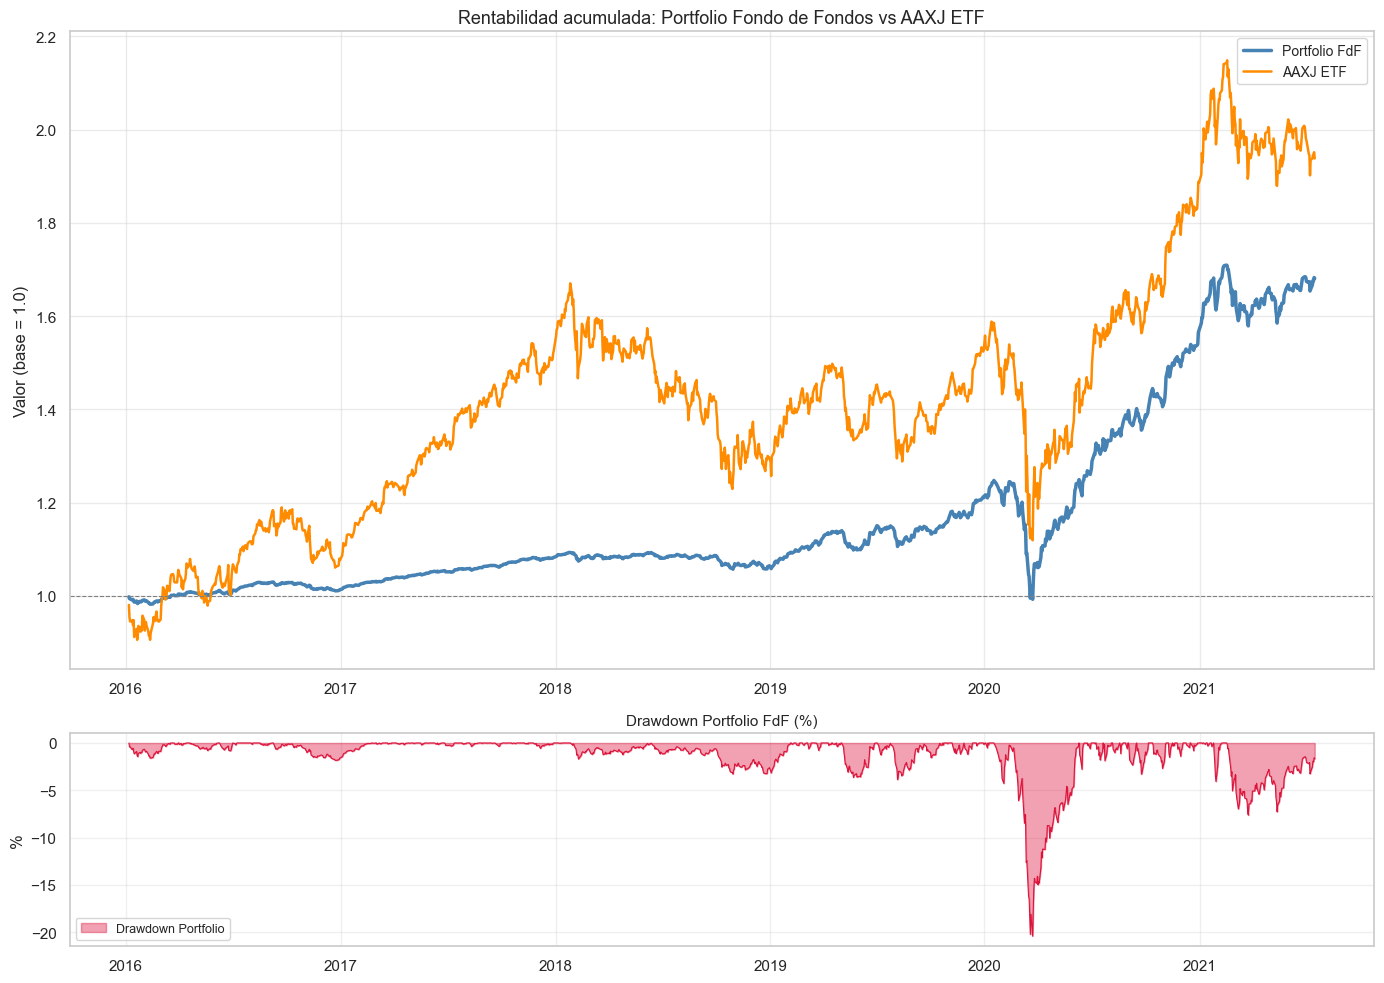

In [69]:
# =============================================================================
# 8.3 - Validacion ex-post del Fondo de Fondos (robusto)
# =============================================================================

# -----------------------------------------------------------------------------
# 0) Validaciones de entrada y normalizacion de ids
# -----------------------------------------------------------------------------
if "fund_id" not in df_portfolio.columns:
    raise ValueError("df_portfolio no tiene columna 'fund_id'.")
if "peso_pct" not in df_portfolio.columns:
    raise ValueError("df_portfolio no tiene columna 'peso_pct'.")

# Detectar columnas en panel_nav
if "panel_nav" not in globals():
    candidate_paths = [
        Path("data") / "daily_universe" / "panel_diario_filtrado_outliers.parquet",
        Path("data") / "daily_universe" / "panel_diario_recortado.parquet",
        Path("data") / "daily_universe" / "panel_diario_universo.parquet",
    ]
    loaded = False
    for p in candidate_paths:
        if p.exists():
            panel_nav = pd.read_parquet(p)
            panel_nav["date"] = pd.to_datetime(panel_nav["date"], errors="coerce")
            print(f"panel_nav cargado desde: {p}")
            loaded = True
            break
    if not loaded:
        raise ValueError("No existe panel_nav en memoria y no se encontró parquet en data/daily_universe.")

if "date" not in panel_nav.columns:
    raise ValueError("panel_nav no tiene columna 'date'.")

if "nav" in panel_nav.columns:
    nav_col = "nav"
elif "NAV" in panel_nav.columns:
    nav_col = "NAV"
else:
    raise ValueError("panel_nav no tiene columna de NAV esperada ('nav' o 'NAV').")

if "fund_id" in panel_nav.columns:
    id_col_nav = "fund_id"
elif "allfunds_id" in panel_nav.columns:
    id_col_nav = "allfunds_id"
else:
    raise ValueError("panel_nav no tiene identificador de fondo ('fund_id' o 'allfunds_id').")

# Normalizar tipos para evitar mismatch int vs str
df_portfolio = df_portfolio.copy()
panel_nav = panel_nav.copy()

df_portfolio["fund_id"] = df_portfolio["fund_id"].astype(str).str.strip()
panel_nav[id_col_nav] = panel_nav[id_col_nav].astype(str).str.strip()
panel_nav["date"] = pd.to_datetime(panel_nav["date"], errors="coerce")
panel_nav = panel_nav.dropna(subset=["date", id_col_nav, nav_col])

# -----------------------------------------------------------------------------
# 1) Seleccionar fondos del portfolio en panel NAV
# -----------------------------------------------------------------------------
fondos_portfolio = df_portfolio["fund_id"].dropna().unique().tolist()

panel_ptf = panel_nav[panel_nav[id_col_nav].isin(fondos_portfolio)].copy()
n_disp = panel_ptf[id_col_nav].nunique()

print(f"\nFondos en portfolio: {len(fondos_portfolio)}")
print(f"Fondos del portfolio con NAV disponible: {n_disp} / {len(fondos_portfolio)}")

if n_disp == 0:
    muestra_port = df_portfolio["fund_id"].dropna().astype(str).head(10).tolist()
    muestra_nav = panel_nav[id_col_nav].dropna().astype(str).head(10).tolist()
    raise ValueError(
        "No hay cruce entre df_portfolio.fund_id y panel_nav.\n"
        f"Ejemplo fund_id portfolio: {muestra_port}\n"
        f"Ejemplo ids panel_nav ({id_col_nav}): {muestra_nav}\n"
        "Revisa formato de ids (prefijos, espacios, ceros a la izquierda, etc.)."
    )

# -----------------------------------------------------------------------------
# 2) Pivot y retornos diarios
# -----------------------------------------------------------------------------
nav_wide = panel_ptf.pivot_table(index="date", columns=id_col_nav, values=nav_col, aggfunc="last").sort_index()

if nav_wide.shape[1] == 0:
    raise ValueError("nav_wide no tiene columnas tras pivot. Revisa duplicados/columnas de entrada.")

ret_wide = np.log(nav_wide / nav_wide.shift(1))

# Pesos
pesos_dict = df_portfolio.set_index("fund_id")["peso_pct"].to_dict()
fondos_comunes = [f for f in fondos_portfolio if f in ret_wide.columns]

print(f"Fondos comunes portfolio-retornos: {len(fondos_comunes)}")

if len(fondos_comunes) == 0:
    raise ValueError(
        "No hay fondos comunes entre df_portfolio y ret_wide. "
        "Tras normalizar ids, sigue sin cruce."
    )

pesos_arr = np.array([pesos_dict[f] / 100.0 for f in fondos_comunes], dtype=float)
if np.isclose(pesos_arr.sum(), 0.0):
    raise ValueError("La suma de pesos es 0. Revisa df_portfolio['peso_pct'].")

pesos_arr /= pesos_arr.sum()

# Retorno portfolio: NaN diarios por fondo se imputan a 0 para no perder fecha de cartera
ret_ptf_daily = ret_wide[fondos_comunes].fillna(0.0).dot(pesos_arr)
ret_ptf_daily.name = "Portfolio FdF"

# Quitar posibles NaN/inf residuales
ret_ptf_daily = ret_ptf_daily.replace([np.inf, -np.inf], np.nan).dropna()

if len(ret_ptf_daily) == 0:
    raise ValueError(
        "ret_ptf_daily quedó vacío. Revisa NAV de los fondos seleccionados "
        "(posibles series constantes, faltantes completos o datos corruptos)."
    )

# -----------------------------------------------------------------------------
# 3) Descargar AAXJ (solo si hay rango temporal valido)
# -----------------------------------------------------------------------------
AAXJ_DISPONIBLE = False
ret_aaxj = None

print("\nDescargando AAXJ desde Yahoo Finance ...")
try:
    import yfinance as yf

    fecha_inicio_dt = ret_ptf_daily.index.min()
    fecha_fin_dt = ret_ptf_daily.index.max()

    if pd.isna(fecha_inicio_dt) or pd.isna(fecha_fin_dt):
        raise ValueError("Rango temporal de portfolio invalido (NaT).")

    fecha_inicio = pd.Timestamp(fecha_inicio_dt).strftime("%Y-%m-%d")
    # +1 dia para incluir fecha final en Yahoo
    fecha_fin = (pd.Timestamp(fecha_fin_dt) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    aaxj_data = yf.download("AAXJ", start=fecha_inicio, end=fecha_fin, auto_adjust=True, progress=False)

    if len(aaxj_data) < 10:
        raise ValueError("Datos AAXJ insuficientes.")

    # yfinance puede devolver MultiIndex en columnas
    if isinstance(aaxj_data.columns, pd.MultiIndex):
        close_candidates = [c for c in aaxj_data.columns if c[0].lower() == "close"]
        if len(close_candidates) == 0:
            raise ValueError("No se encontro columna Close en AAXJ.")
        aaxj_price = aaxj_data[close_candidates[0]].squeeze()
    else:
        if "Close" not in aaxj_data.columns:
            raise ValueError("No se encontro columna Close en AAXJ.")
        aaxj_price = aaxj_data["Close"].squeeze()

    ret_aaxj = np.log(aaxj_price / aaxj_price.shift(1)).dropna()
    ret_aaxj.name = "AAXJ ETF"

    if len(ret_aaxj) < 10:
        raise ValueError("Retornos AAXJ insuficientes tras calcular log-ret.")

    AAXJ_DISPONIBLE = True
    print(f"AAXJ descargado: {len(aaxj_data)} dias")
except Exception as e:
    print(f"AVISO: No se pudo descargar AAXJ ({e}). Se omite comparacion vs ETF.")

# -----------------------------------------------------------------------------
# 4) Alinear series
# -----------------------------------------------------------------------------
ret_ptf_norm = ret_ptf_daily.copy()
if getattr(ret_ptf_norm.index, "tz", None) is not None:
    ret_ptf_norm.index = ret_ptf_norm.index.tz_localize(None)

if AAXJ_DISPONIBLE:
    ret_aaxj_norm = ret_aaxj.copy()
    if getattr(ret_aaxj_norm.index, "tz", None) is not None:
        ret_aaxj_norm.index = ret_aaxj_norm.index.tz_localize(None)

    df_rets = pd.concat([ret_ptf_norm, ret_aaxj_norm], axis=1).dropna()
    df_rets.columns = ["Portfolio FdF", "AAXJ ETF"]
else:
    df_rets = ret_ptf_norm.to_frame(name="Portfolio FdF").dropna()

if len(df_rets) == 0:
    raise ValueError(
        "df_rets quedo vacio tras alineacion. Revisa interseccion de fechas "
        "entre portfolio y benchmark."
    )

print(f"\nPeriodo de validacion: {df_rets.index[0].date()} -> {df_rets.index[-1].date()}")
print(f"Dias de trading: {len(df_rets)}")

# -----------------------------------------------------------------------------
# 5) Metricas de performance
# -----------------------------------------------------------------------------
TRADING_DAYS = 252

def metricas_performance(ret_series, nombre, benchmark=None):
    ret = ret_series.dropna()

    if len(ret) == 0:
        return {
            "Nombre": nombre,
            "Retorno Total (%)": np.nan,
            "CAGR (%)": np.nan,
            "Volatilidad Ann. (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Information Ratio": np.nan,
            "Tracking Error (%)": np.nan,
        }

    cum_growth = np.exp(ret.cumsum())
    total_ret = cum_growth.iloc[-1] - 1.0

    n_years = max(len(ret) / TRADING_DAYS, 1e-6)
    cagr = (1.0 + total_ret) ** (1.0 / n_years) - 1.0

    vol_ann = ret.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe = cagr / vol_ann if vol_ann > 0 else np.nan

    rolling_max = cum_growth.cummax()
    drawdown = (cum_growth / rolling_max) - 1.0
    max_dd = drawdown.min()

    metrics = {
        "Nombre": nombre,
        "Retorno Total (%)": round(total_ret * 100, 2),
        "CAGR (%)": round(cagr * 100, 2),
        "Volatilidad Ann. (%)": round(vol_ann * 100, 2),
        "Sharpe Ratio": round(sharpe, 3) if pd.notna(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd * 100, 2),
    }

    if benchmark is not None:
        bm = benchmark.reindex(ret.index).dropna()
        common_idx = ret.index.intersection(bm.index)
        if len(common_idx) > 1:
            active_ret = ret.loc[common_idx] - bm.loc[common_idx]
            te_ann = active_ret.std(ddof=1) * np.sqrt(TRADING_DAYS)
            ir_ann = (active_ret.mean() * TRADING_DAYS) / te_ann if te_ann > 0 else np.nan
            metrics["Information Ratio"] = round(ir_ann, 3) if pd.notna(ir_ann) else np.nan
            metrics["Tracking Error (%)"] = round(te_ann * 100, 2)
        else:
            metrics["Information Ratio"] = np.nan
            metrics["Tracking Error (%)"] = np.nan

    return metrics

metricas_list = []
bm_series = df_rets["AAXJ ETF"] if "AAXJ ETF" in df_rets.columns else None

for col in df_rets.columns:
    bm = bm_series if col != "AAXJ ETF" else None
    metricas_list.append(metricas_performance(df_rets[col], col, bm))

df_metricas = pd.DataFrame(metricas_list).set_index("Nombre")

print("\n" + "=" * 70)
print("8.3 - METRICAS DE PERFORMANCE")
print("=" * 70)
display(df_metricas.T)

# -----------------------------------------------------------------------------
# 6) Graficos
# -----------------------------------------------------------------------------
cum_ret_df = np.exp(df_rets.cumsum())

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]}
)

for col in cum_ret_df.columns:
    color = "steelblue" if col == "Portfolio FdF" else "darkorange"
    lw = 2.5 if col == "Portfolio FdF" else 1.8
    ax1.plot(cum_ret_df.index, cum_ret_df[col], label=col, color=color, linewidth=lw)

ax1.set_title("Rentabilidad acumulada: Portfolio Fondo de Fondos vs AAXJ ETF", fontsize=13)
ax1.set_ylabel("Valor (base = 1.0)")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.4)
ax1.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")

ptf_cum = np.exp(df_rets["Portfolio FdF"].cumsum())
roll_max = ptf_cum.cummax()
dd_series = (ptf_cum / roll_max - 1.0) * 100

ax2.fill_between(dd_series.index, dd_series.values, 0, color="crimson", alpha=0.4, label="Drawdown Portfolio")
ax2.plot(dd_series.index, dd_series.values, color="crimson", linewidth=0.8)
ax2.set_title("Drawdown Portfolio FdF (%)", fontsize=11)
ax2.set_ylabel("%")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 8.4 Interpretación final y conclusiones

La comparación entre el **Portfolio FdF** y el benchmark **AAXJ ETF** muestra dos resultados complementarios:

- El benchmark logra **mayor retorno absoluto** en el periodo analizado:
  - Retorno total: **93.80% (AAXJ)** vs **68.09% (FdF)**
  - CAGR: **12.72% (AAXJ)** vs **9.86% (FdF)**

- Sin embargo, el Portfolio FdF presenta una **mejor calidad riesgo-retorno**:
  - Volatilidad anual: **7.70% (FdF)** vs **20.55% (AAXJ)**
  - Sharpe ratio: **1.280 (FdF)** vs **0.619 (AAXJ)**
  - Max Drawdown: **-20.43% (FdF)** vs **-32.98% (AAXJ)**

Lectura financiera

El fondo de fondos **renuncia a parte del retorno máximo** a cambio de una trayectoria más estable y defensiva.  
En términos prácticos, esto significa que:

1. **Cae menos en periodos adversos** (drawdown significativamente menor).
2. **Asume menos riesgo total** (volatilidad muy inferior).
3. **Compensa mejor el riesgo asumido** (Sharpe claramente superior a AAXJ).

Sobre Information Ratio y Tracking Error

- **Information Ratio = -0.152**: el portfolio, en promedio, no genera exceso de retorno frente al benchmark en base ajustada por riesgo activo durante el periodo.
- **Tracking Error = 16.99%**: la cartera se desvía de forma relevante respecto a AAXJ, coherente con una construcción más diversificada y menos indexada al benchmark.

Conclusión final

El resultado es consistente con un enfoque de cartera orientado a **eficiencia riesgo-retorno** más que a maximización de retorno bruto.  
Si el objetivo principal es batir al benchmark en rentabilidad absoluta, AAXJ fue superior en este tramo; pero si el objetivo es construir una solución **más robusta, estable y con mejor comportamiento en caídas**, el Portfolio FdF mantiene un perfil competitivo en términos de gestión del riesgo.